# First-Year Student Success and Dropout Prediction
## PathFinder Early-Warning System — ML1 Final Project

---


## ***1. Problem Framing***

### Context

First-year University students face a difficult transition: many arrive academically 
prepared but struggle with the pace, autonomy, or the social and financial 
pressures of university life. By the time difficulties become visible in 
grades, it is often too late for a meaningful intervention.

This project builds an **early-warning system** that uses behavioural and 
contextual signals — collected in the first weeks of the semester — to 
produce two predictions for each student:

| Prediction | Type | Target variable |
|---|---|---|
| Expected final grade | Regression | `final_grade_100` |
| Risk of dropping out | Binary classification | `dropped_out` |


+ > Both predictions inform different kinds of support: **academic tutoring**, **financial guidance**, or **personal counselling**.


### Warning: The Two Tasks are not Equally Costly

For the dropout classifier:

- A **false negative** (missing a student who will drop out) means no 
intervention is triggered. The student may leave permanently, with 
lasting consequences for their academic trajectory.
- A **false positive** (flagging a student who would have been fine) 
wastes advisor time and may stigmatise a student unnecessarily.

This asymmetry directly shapes our modelling choices:

> We will prioritise **recall** on the dropout class over raw accuracy.

For the grade regressor, a 5-point 
overestimate and underestimate are roughly equally problematic — 
so we use **RMSE** and **R²** as primary metrics.

> **In plain terms:** we would rather flag ten students for a check-in 
and be wrong on three of them, than miss a student who genuinely needed 
help.


## **Evaluation Metrics**

---

### Task 1 — Grade Regression

| Metric | Interpretation |
|---|---|
| **RMSE** | An RMSE of 8 means the model is off by roughly ±8 points on average. |
| **R²** | Proportion of variance in final grades explained by the model. 1.0 is perfect|
 
#

> **In plain terms:** if our best model achieves R² = 0.80 and RMSE = 6, 
it captures 80% of what makes grades differ from student to student, 
and is typically within 6 points of the true grade. 
That is actionable precision for an advisor deciding whether to schedule a tutoring session.

---

### Task 2 — Dropout Classification

| Metric | What it measures | Why it matters here |
|---|---|---|
| **Recall** | Of all actual dropouts, how many did we catch? | ***Most critical — we cannot miss at-risk students*** |
| **Precision** | Of all flagged students, how many truly dropped out? | Controls advisor overload |
| **F1-score** | Harmonic mean of precision and recall | Single balanced metric for model comparison |
| **ROC-AUC** | Separability across all decision thresholds | Threshold-independent overall quality |
#

> **Why not accuracy:** with 85% of students not dropping out, 
a classifier that predicts 'no dropout' for everyone achieves 85% accuracy 
while catching **zero** at-risk students. 

> **In plain terms:** a model with Recall = 0.80 means that the system flags 8/10 dropout students in time 
for an intervention.
---


### **Validation Strategy**

+ All models are evaluated using **5-fold cross-validation** on the training 
set (1,100 students). The test set (300 students) is never consulted during 
modelling decisions.

+ For the classification task we use **StratifiedKFold**, ensuring that 
every fold preserves the original 85%/15% class ratio - a non-stratified split 
could produce folds with very few positive examples, making metric estimates unstable.
---

### **Reproducibility**

All random processes in this notebook use `random_state=42`. 
Every result shown here can be reproduced by running the notebook 
from top to bottom in a clean environment.


In [416]:
from sklearn.model_selection import StratifiedKFold, KFold

RANDOM_STATE = 42

# Stratified: preserves the 85/15 dropout ratio in every fold
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Standard k-fold for the continuous regression target
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


---
## 2. ***Data Loading & Overview***

We begin by loading the data, inspecting its structure, and confirming
there are no missing values or unexpected types before any analysis.

In [417]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, KFold

# ── Global constants ────────────────────────────────────────────────────────
# Centralising all constants here means changing a colour or a target name
# in one place propagates automatically through the entire notebook.
RANDOM_STATE = 42
BLUE, RED    = "#0011FF", "#FF2600"

TARGET_REG        = 'final_grade_100'
TARGET_CLF        = 'dropped_out'

NUMERIC_FEATS = [
    'attendance_rate_pct', 'assignment_completion_pct', 'quiz_average_pct',
    'hours_self_study_week', 'prior_gpa_20', 'absences_last30d',
    'tutoring_sessions_month', 'internet_reliability_score',
    'commute_minutes', 'financial_stress_score', 'participation_score'
]
# dormitory_block is an integer 1–5 but represents unordered categories,
# so we keep it separate and will one-hot encode before modelling.
CATEGORICAL_FEATS = ['dormitory_block']

# Stratified preserves the 85/15 dropout ratio in every fold.
# Standard KFold is sufficient for the continuous regression target.
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sns.set_theme(style='whitegrid', font_scale=1.2)

In [418]:
df_train = pd.read_csv('track_f_student_success_train.csv')
df_test  = pd.read_csv('track_f_student_success_test.csv')

# df_test is loaded here but will not be touched until the final prediction step
# — it plays no role in any modelling decision made in this notebook.


print(f"Training set : {df_train.shape[0]} rows × {df_train.shape[1]} columns")
print(f"Test set     : {df_test.shape[0]} rows × {df_test.shape[1]} columns")

Training set : 1100 rows × 14 columns
Test set     : 300 rows × 14 columns


## **Structure Inspection**

We check column types, value ranges, and missing values.

In [419]:
# What we are checking for:
#   - any column with fewer than 1100 non-null entries (= missing values)
#   - any numeric column stored as 'object' (= parsing problem)
#   - dormitory_block stored as int64 (expected — we handle it manually later)
df_train.info()

missing = df_train.isnull().sum()

print("=" * 50)
# If any column has missing values, we would need to decide:
# impute (fill with mean/median/mode) or drop. Here we expect none.
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None — dataset is complete.")

print("=" * 50)
# Key things to read here:
#   - min/max: are values within the expected ranges from the feature reference?
#   - mean vs median (50%): large gap = skewed distribution
#   - std: high std relative to the range means high variability between students
df_train.describe().round(2)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   attendance_rate_pct         1100 non-null   float64
 1   assignment_completion_pct   1100 non-null   float64
 2   quiz_average_pct            1100 non-null   float64
 3   hours_self_study_week       1100 non-null   float64
 4   prior_gpa_20                1100 non-null   float64
 5   absences_last30d            1100 non-null   int64  
 6   tutoring_sessions_month     1100 non-null   int64  
 7   internet_reliability_score  1100 non-null   float64
 8   commute_minutes             1100 non-null   float64
 9   financial_stress_score      1100 non-null   float64
 10  participation_score         1100 non-null   float64
 11  dormitory_block             1100 non-null   int64  
 12  final_grade_100             1100 non-null   float64
 13  dropped_out                 1100 

,attendance_rate_pct,assignment_completion_pct,quiz_average_pct,hours_self_study_week,prior_gpa_20,absences_last30d,tutoring_sessions_month,internet_reliability_score,commute_minutes,financial_stress_score,participation_score,dormitory_block,final_grade_100,dropped_out
count,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00
mean,70.01,68.79,59.71,11.97,12.93,3.32,1.23,5.06,48.01,5.09,6.31,2.97,83.04,0.15
std,17.38,19.75,23.14,7.09,4.05,2.15,1.08,2.93,24.48,2.91,1.96,1.46,14.55,0.36
min,40.07,25.00,20.05,0.02,6.01,0.00,0.00,0.00,5.00,0.00,1.06,1.00,32.48,0.00
25%,54.71,54.17,39.91,5.91,9.41,2.00,0.00,2.58,27.40,2.54,4.90,2.00,72.98,0.00
50%,69.87,69.04,59.86,11.64,12.98,3.00,1.00,5.09,47.70,5.28,6.30,3.00,85.22,0.00
75%,85.50,84.58,79.63,18.09,16.45,5.00,2.00,7.61,69.10,7.54,7.76,4.00,96.56,0.00
max,99.95,100.00,99.95,24.99,19.99,12.00,6.00,9.99,90.00,9.99,10.00,5.00,100.00,1.00


> The dataset is clean and complete — no missing values,
> no obviously corrupt entries. The main preprocessing challenge is scale
> differences between features, not data quality.

In [420]:
# We separate inputs (X) from targets (y) now and keep this split
# consistent throughout the notebook. Every model will receive X as input
# and predict either y_reg (grade) or y_clf (dropout).
X = df_train.drop(columns=[TARGET_REG, TARGET_CLF])
y_reg = df_train[TARGET_REG]   # continuous: 0–100
y_clf = df_train[TARGET_CLF]   # binary: 0 = stayed, 1 = dropped out

# X_test has the same 12 features but no targets.
# It will only be used in the final prediction cell.
X_test = df_test.drop(columns=[TARGET_REG, TARGET_CLF])

print(f"X shape      : {X.shape}")
print(f"y_reg range  : [{y_reg.min():.1f}, {y_reg.max():.1f}]  |  mean {y_reg.mean():.1f}")
print(f"y_clf balance: {y_clf.value_counts().to_dict()}  "
      f"({y_clf.mean()*100:.1f}% dropout)")

X shape      : (1100, 12)
y_reg range  : [32.5, 100.0]  |  mean 83.0
y_clf balance: {0: 935, 1: 165}  (15.0% dropout)


## **Summary**

| Property | Value |
|---|---|
| Training samples | 1,100 |
| Test samples | 300 |
| Features | 12 (11 numeric, 1 categorical) |
| Missing values | None |
| Grade target range | 0–100 (continuous) |
| Dropout class balance | ~85% stayed / ~15% dropped out |

The dataset is ready for exploratory analysis.

---
---
---

---
## ***3. Exploratory Data Analysis***

Before building any model, we need to understand the data deeply.
This section moves through four layers of analysis:

1. **Target distributions** — how grades and dropout are distributed.
2. **Feature distributions** — the shape of each input variable.
3. **Feature vs. targets** — which variables separate the two classes
   and correlate with the grade.
4. **Global structure** — PCA to visualise the dataset in two/three dimensions.

> The goal is to extract insights that will directly inform preprocessing and modelling decisions.
---

### **3.1 Target Distributions**

We examine each target independently before looking at relationships.

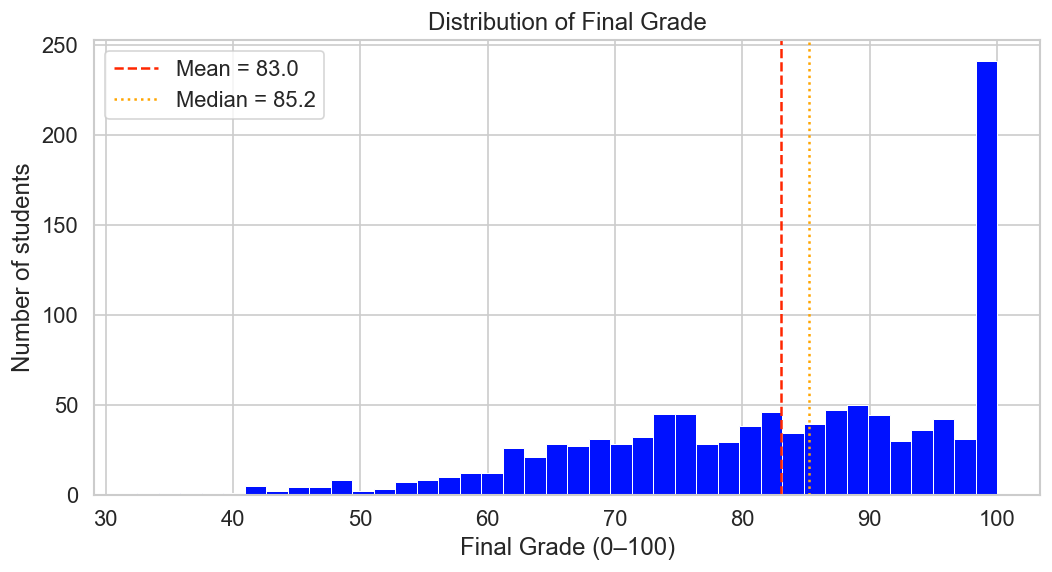

In [421]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_train[TARGET_REG], bins=40, color=BLUE, edgecolor='white', linewidth=0.6)
ax.axvline(df_train[TARGET_REG].mean(), color=RED, linestyle='--',
           linewidth=1.5, label=f"Mean = {df_train[TARGET_REG].mean():.1f}")
ax.axvline(df_train[TARGET_REG].median(), color='orange', linestyle=':',
           linewidth=1.5, label=f"Median = {df_train[TARGET_REG].median():.1f}")

ax.set_xlabel('Final Grade (0–100)')
ax.set_ylabel('Number of students')
ax.set_title('Distribution of Final Grade')
ax.legend()
plt.tight_layout()
plt.show()

> The distribution is **negatively skewed**: the bulk of students score
above 70, with a long tail toward lower grades. The mean (≈83) and median
sit close together, but the left tail pulls the mean slightly downward.
+ -> ***The model will be more confident predicting high grades than low ones, because it has seen more of them.***

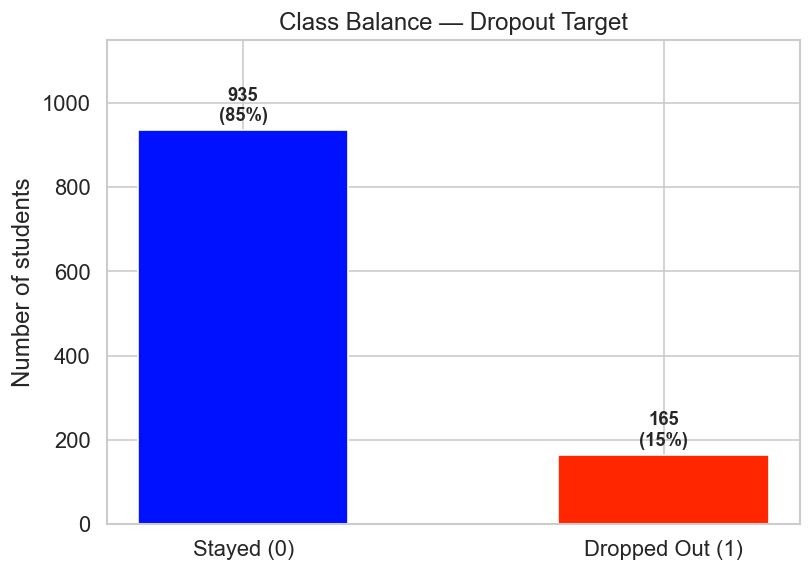

In [422]:
counts = df_train[TARGET_CLF].value_counts().sort_index()
labels = ['Stayed (0)', 'Dropped Out (1)']
pcts   = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts.values, color=[BLUE, RED], width=0.5, edgecolor='white')

# Annotate each bar with count and percentage
for bar, val, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 12,
            f'{val}\n({pct:.0f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1150)
ax.set_ylabel('Number of students')
ax.set_title('Class Balance — Dropout Target')
plt.tight_layout()
plt.show()

> The dataset is **imbalanced**: 935 students stayed (85%) and only 165
dropped out (15%). This 5.7:1 ratio has critical consequences for modelling:

- A classifier that always predicts "stayed" would achieve **85% accuracy**
  while catching zero actual dropouts — a useless but technically
  high-scoring model.
- Standard training procedures will be biased toward the majority class
  unless we explicitly correct for this.

### **3.2 Feature Distributions**

We plot a histogram for each numeric feature to understand its shape,
range, and whether outliers or skewness are present.
These observations will inform preprocessing decisions.

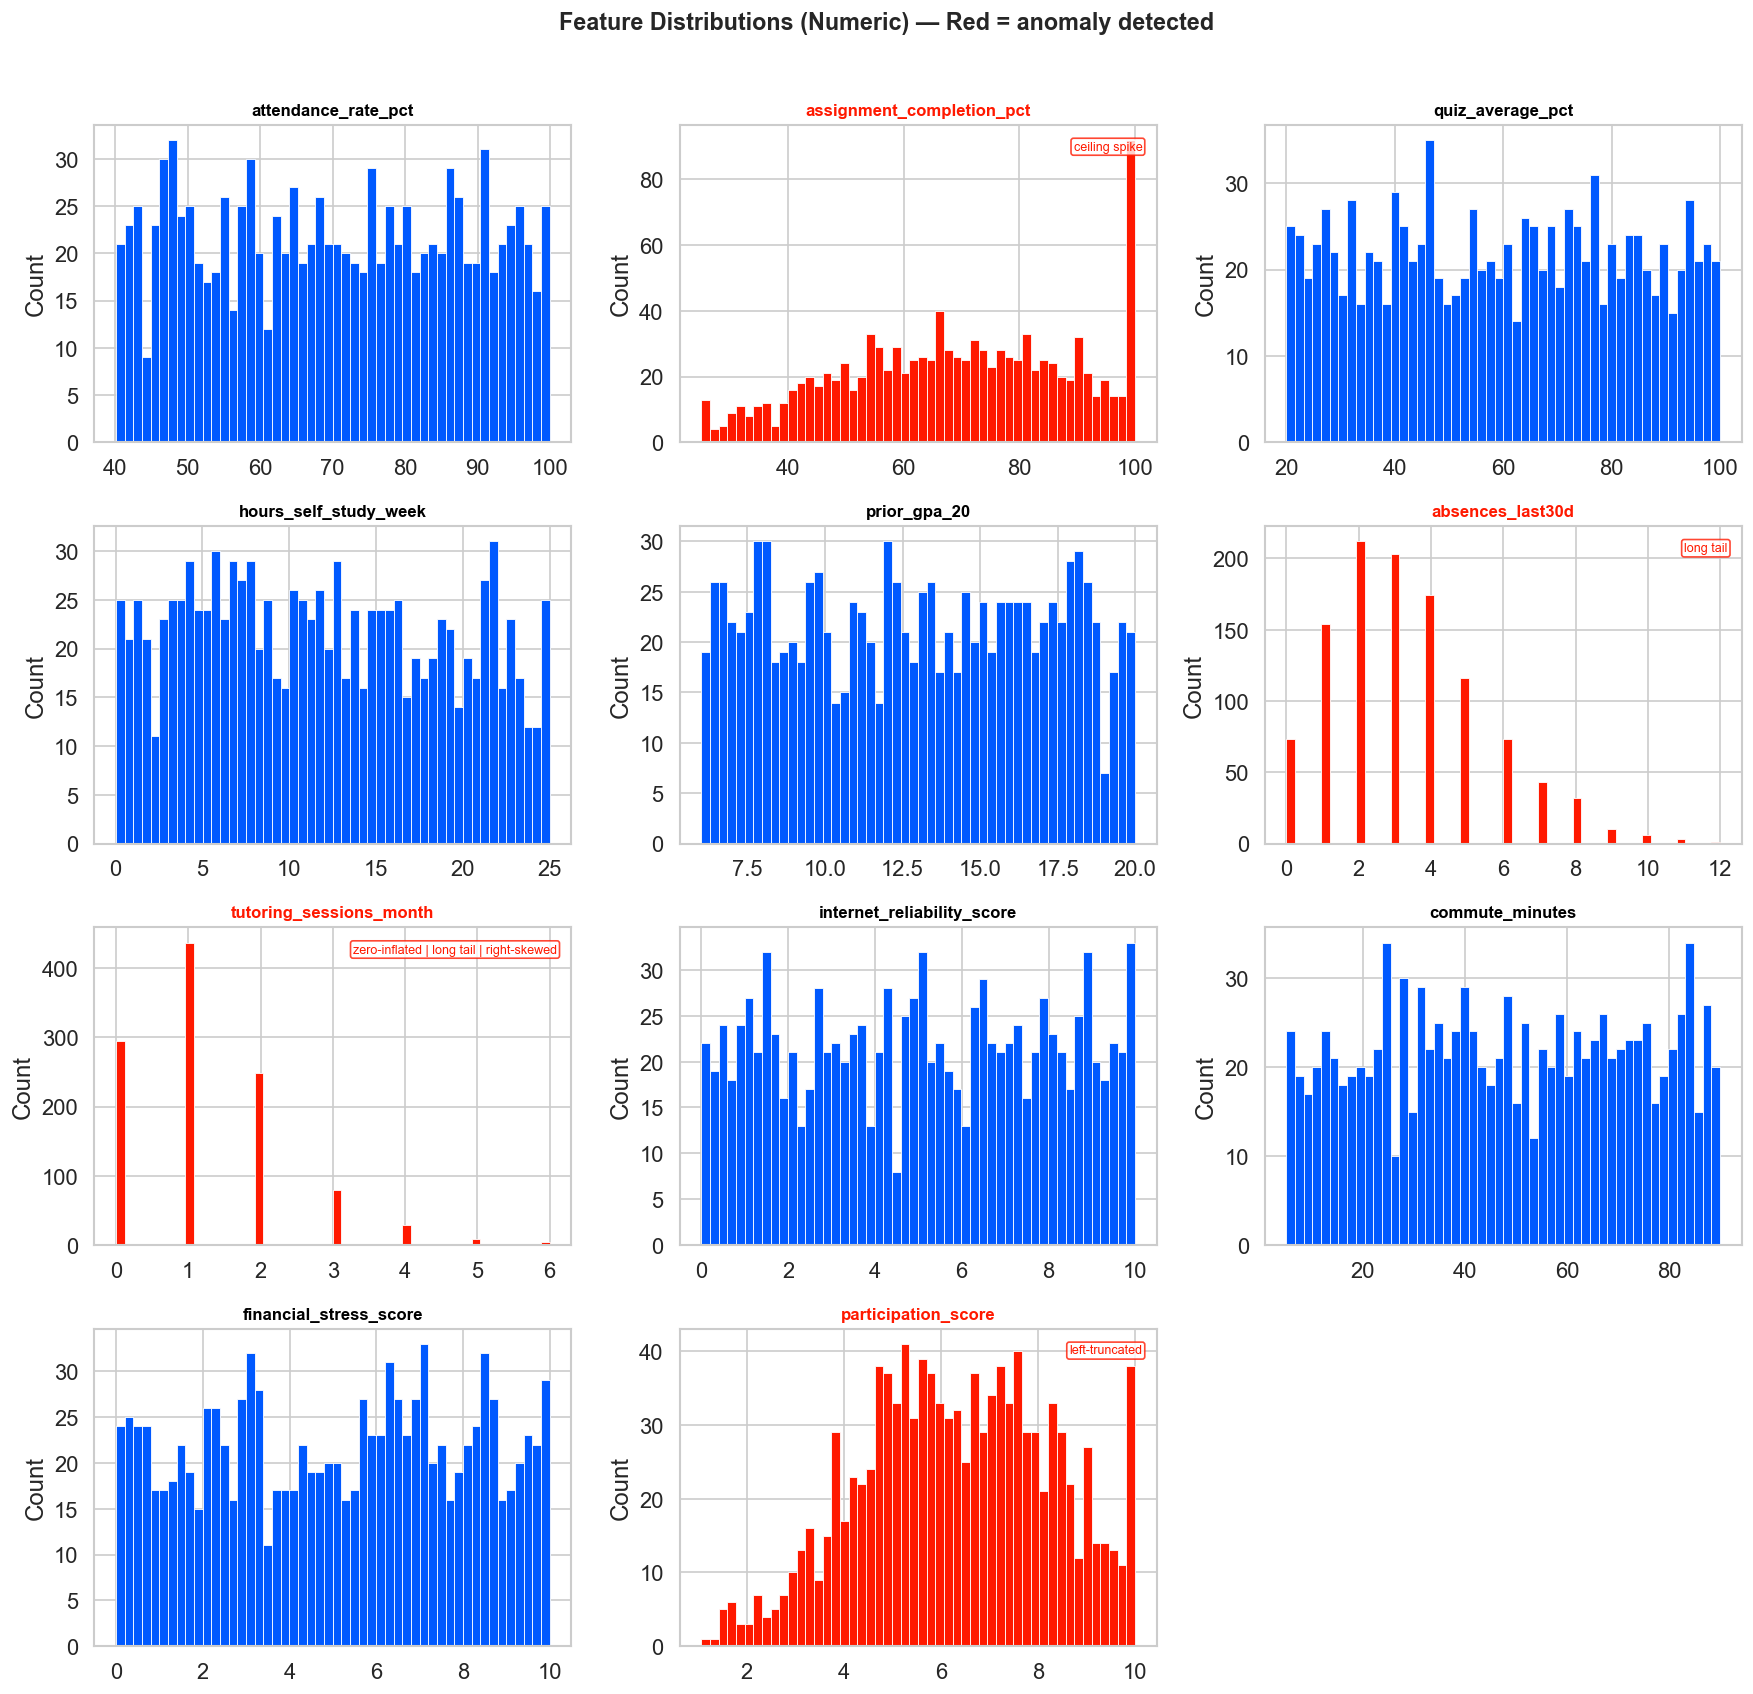


Anomaly Summary:
──────────────────────────────────────────────────
  assignment_completion_pct           ceiling spike
  absences_last30d                    long tail
  tutoring_sessions_month             zero-inflated, long tail, right-skewed
  participation_score                 left-truncated


In [423]:
import scipy.stats as stats

def detect_anomalies(series, bins=50):
    """
    Returns a dict of detected anomalies and the bar colours to highlight.
    Rules:
      - Zero-inflation : bin at 0 contains > 25% of data
      - Right skew     : skewness > 1.5
      - Ceiling spike  : top bin contains > 2x the average bin count
      - Truncation     : bottom 10% of value range holds < 3% of data
    """
    arr    = series.dropna().values
    counts, edges = np.histogram(arr, bins=bins)
    total  = len(arr)
    avg    = counts.mean()
    flags  = []

    # Zero-inflation: first bin (near 0) dominates
    if edges[0] <= 0 <= edges[1] and counts[0] / total > 0.25:
        flags.append('zero-inflated')

    # Right tail: top 5% of values span more than 40% of the total range
    p95  = np.percentile(arr, 95)
    p50  = np.percentile(arr, 50)
    rnge = arr.max() - arr.min()
    if (arr.max() - p95) > 0.25 * rnge:
        flags.append('long tail')
    
    # Right skew
    if stats.skew(arr) > 0.8:
        flags.append('right-skewed')

    # Ceiling spike: last bin is much larger than average
    if counts[-1] > 2 * avg:
        flags.append('ceiling spike')

    # Left truncation: bottom 10% of range holds almost no data
    range_10pct = edges[0] + 0.10 * (edges[-1] - edges[0])
    pct_in_bottom = arr[arr <= range_10pct].shape[0] / total
    if pct_in_bottom < 0.03:
        flags.append('left-truncated')

    return flags


fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

BLUE = "#0059FF"
RED  = "#FF1900"

anomaly_summary = {}

for i, feat in enumerate(NUMERIC_FEATS):
    series = df_train[feat]
    flags  = detect_anomalies(series)
    color  = RED if flags else BLUE

    axes[i].hist(series, bins=50, color=color,
                 edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat, fontsize=10, fontweight='bold',
                      color=RED if flags else 'black')
    axes[i].set_ylabel('Count')

    if flags:
        label = ' | '.join(flags)
        axes[i].text(0.97, 0.95, label,
                     transform=axes[i].transAxes,
                     fontsize=7.5, color=RED, ha='right', va='top',
                     bbox=dict(boxstyle='round,pad=0.2',
                               facecolor='white', edgecolor=RED, alpha=0.8))
        anomaly_summary[feat] = flags

axes[-1].set_visible(False)

fig.suptitle('Feature Distributions (Numeric) — Red = anomaly detected',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────────
print("\nAnomaly Summary:")
print("─" * 50)
for feat, flags in anomaly_summary.items():
    print(f"  {feat:<35} {', '.join(flags)}")
if not anomaly_summary:
    print("  No anomalies detected.")

## How detecting these anomalies is helpful for modeling:

+ **`tutoring_sessions_month` (zero-inflated):** The feature conflates two distinct signals — *whether* a student uses tutoring and
*how much*. We add a binary indicator `tutoring_any` to give the linear model a
direct handle on the zero/non-zero distinction.

+ **`absences_last30d` (long tail):** A small number of high-absence students
(8–12 absences) have disproportionate leverage on OLS coefficients due to squared
error minimisation. A `log1p` transform is tested to assess whether
compressing the tail improves generalisation.

+ **`assignment_completion_pct` and `participation_score`:**  `StandardScaler` handles both ceiling spike and truncation without distortion.

In [424]:
# ── Feature Engineering — motivated by distribution analysis ─────────────────

# tutoring_any: binary indicator for zero-inflated tutoring_sessions_month
df_train['tutoring_any'] = (df_train['tutoring_sessions_month'] > 0).astype(int)
df_test['tutoring_any']  = (df_test['tutoring_sessions_month']  > 0).astype(int)

# log1p_absences: compresses the long tail of absences_last30d
df_train['log1p_absences'] = np.log1p(df_train['absences_last30d'])
df_test['log1p_absences']  = np.log1p(df_test['absences_last30d'])

print("New features added:")
print(f"  tutoring_any       : {df_train['tutoring_any'].value_counts().to_dict()}")
print(f"  log1p_absences     : min={df_train['log1p_absences'].min():.2f}, "
      f"max={df_train['log1p_absences'].max():.2f}, "
      f"mean={df_train['log1p_absences'].mean():.2f}")

New features added:
  tutoring_any       : {1: 806, 0: 294}
  log1p_absences     : min=0.00, max=2.56, mean=1.33


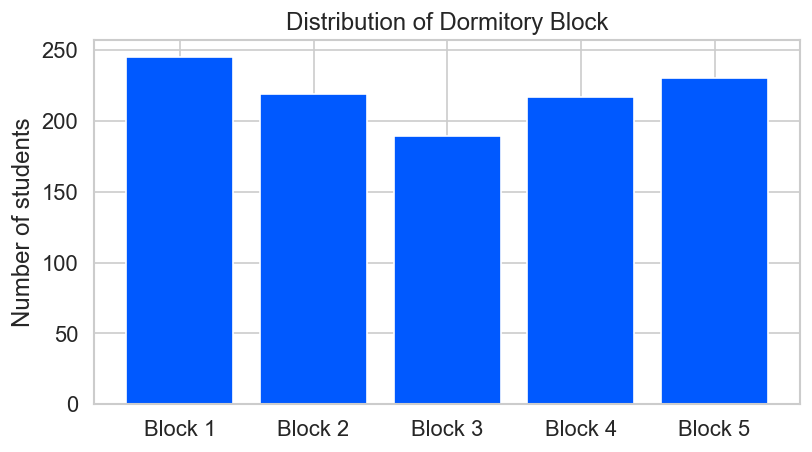

In [425]:
# dormitory_block is categorical — we use a bar chart, not a histogram.
# Equal frequencies across blocks would suggest no confounding effect;
# unequal would suggest block assignment is not random.
block_counts = df_train['dormitory_block'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f'Block {i}' for i in block_counts.index],
       block_counts.values, color=BLUE, edgecolor='white')
ax.set_ylabel('Number of students')
ax.set_title('Distribution of Dormitory Block')
plt.tight_layout()
plt.show()

> Block assignment is approximately random — there is no block
with dramatically more students, which would create sampling artefacts.

In [426]:
# Statistical validation: does dormitory_block actually predict either target?
from scipy.stats import chi2_contingency, kruskal

# Chi-square: block vs dropped_out
ct = pd.crosstab(df_train['dormitory_block'], df_train[TARGET_CLF])
chi2, p_chi, dof, _ = chi2_contingency(ct)
print(f"Chi-square — dormitory_block vs dropped_out")
print(f"  χ² = {chi2:.3f}  |  dof = {dof}  |  p = {p_chi:.3f}")
print(f"  → {'significant' if p_chi < 0.05 else 'not significant (p ≥ 0.05) — block is uninformative for dropout'}")

# Kruskal-Wallis: block vs final_grade_100
groups = [df_train.loc[df_train['dormitory_block'] == b, TARGET_REG].values
          for b in sorted(df_train['dormitory_block'].unique())]
stat, p_kw = kruskal(*groups)
print(f"\nKruskal-Wallis — dormitory_block vs final_grade_100")
print(f"  H = {stat:.3f}  |  p = {p_kw:.3f}")
print(f"  → {'significant' if p_kw < 0.05 else 'not significant (p ≥ 0.05) — block does not affect grade'}")
print("\n→ Confirmed: dormitory_block carries no signal. Lasso will zero its one-hot columns.")


Chi-square — dormitory_block vs dropped_out
  χ² = 4.747  |  dof = 4  |  p = 0.314
  → not significant (p ≥ 0.05) — block is uninformative for dropout

Kruskal-Wallis — dormitory_block vs final_grade_100
  H = 3.674  |  p = 0.452
  → not significant (p ≥ 0.05) — block does not affect grade

→ Confirmed: dormitory_block carries no signal. Lasso will zero its one-hot columns.


### **3.3 Feature vs. Targets**

> We now examine how each feature relates to our two targets.
+ For the dropout task, box plots side by side reveal **which features cleanly separate the two groups.**
+ For the grade task, a correlation matrix quantifies **linear relationships**.

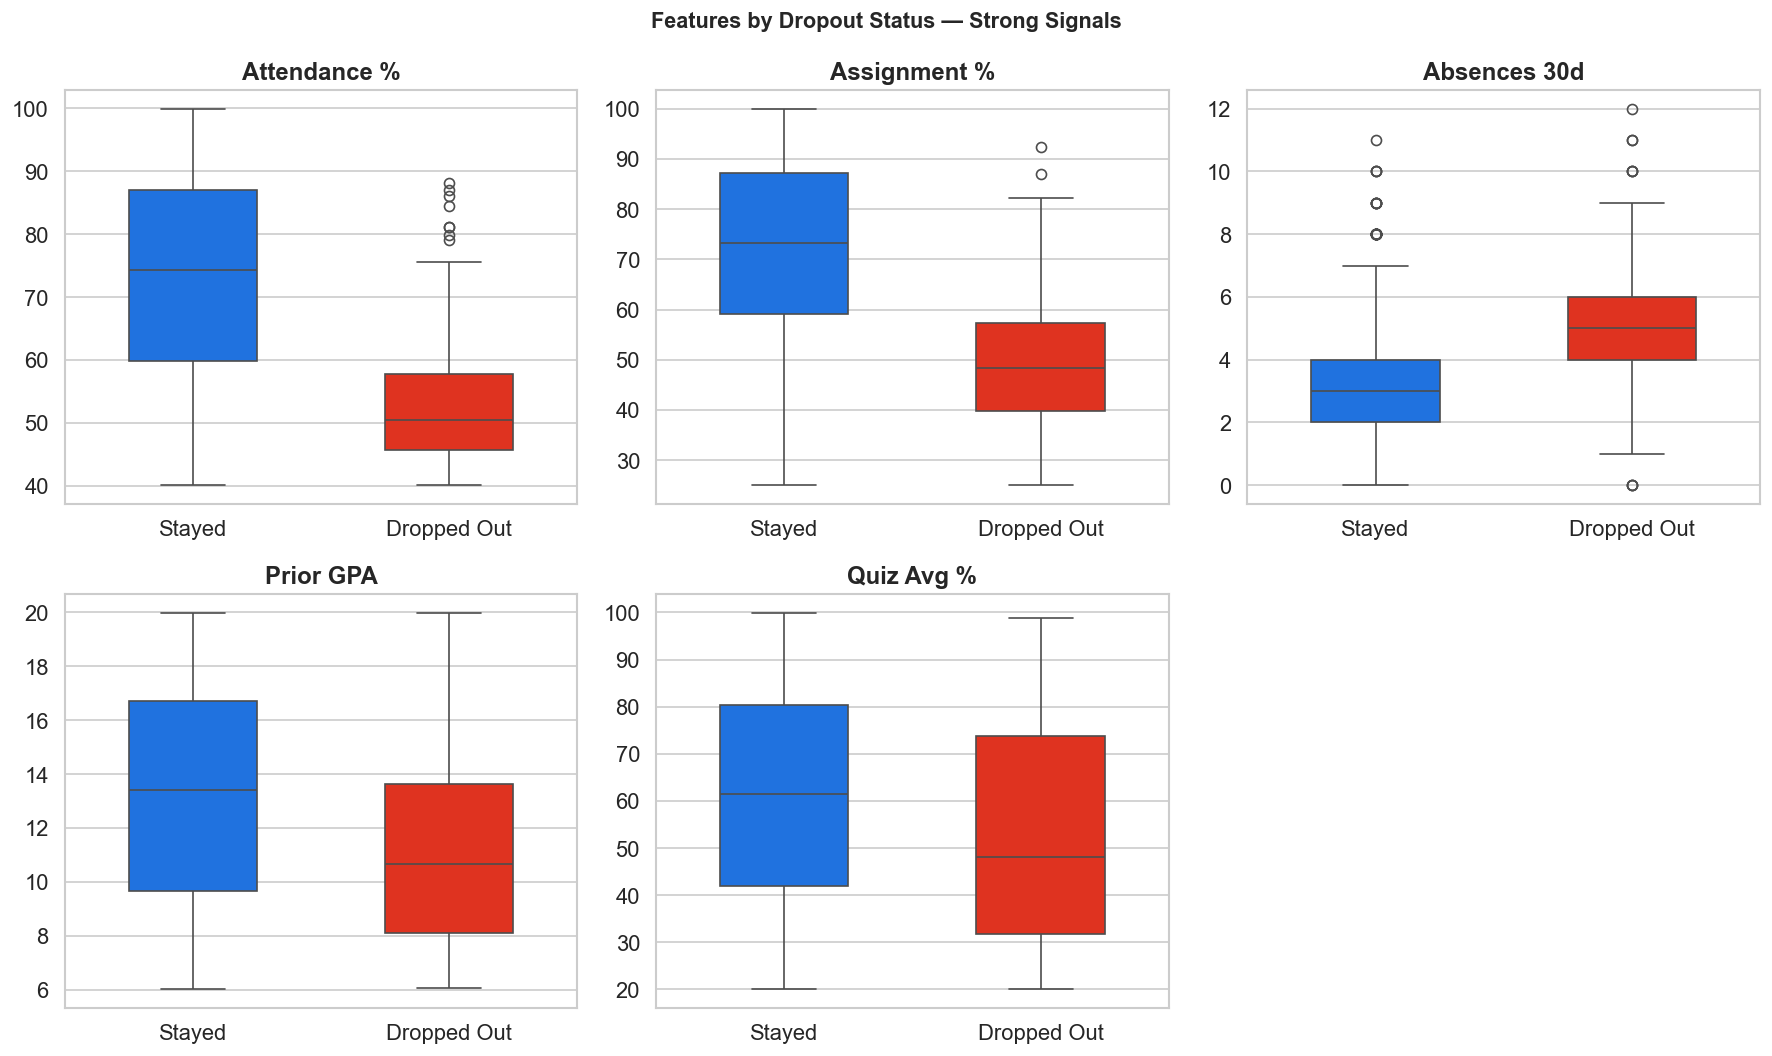

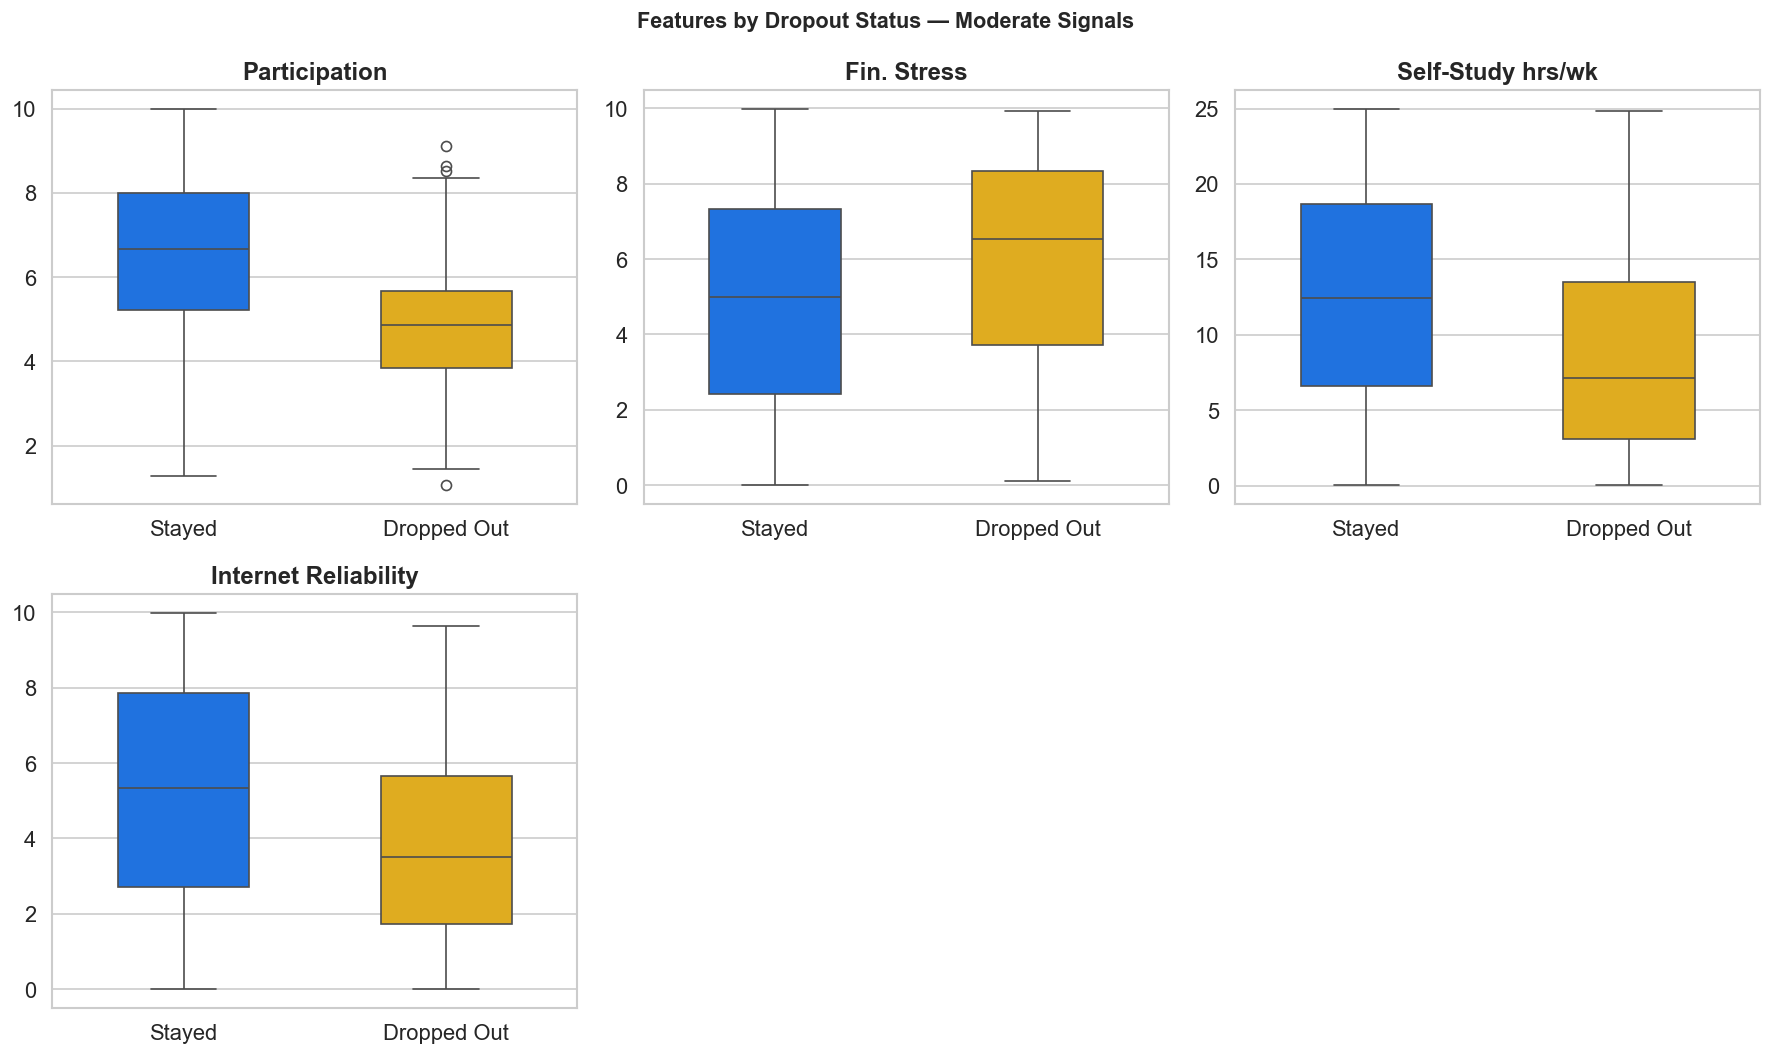

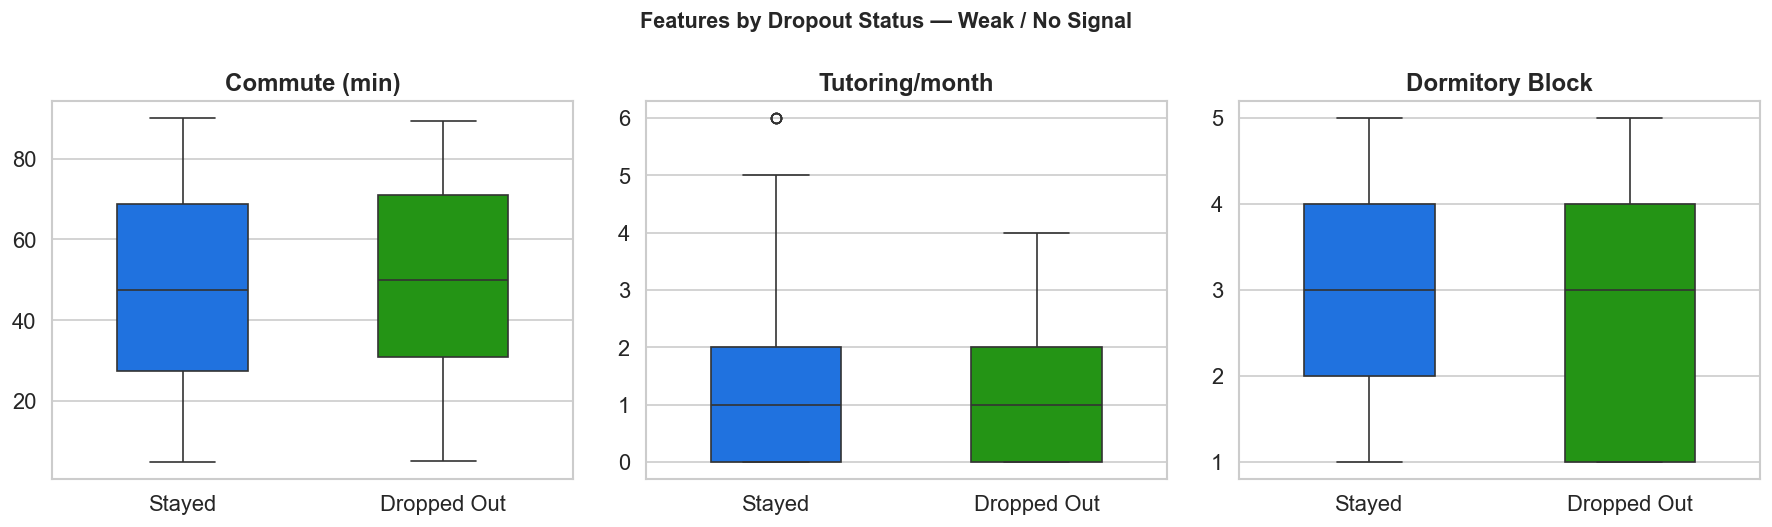

In [427]:
# ── 3.3  Feature Distributions by Dropout Status ─────────────────────────────

df_plot = df_train.copy()
df_plot['Status'] = df_plot[TARGET_CLF].map({0: 'Stayed', 1: 'Dropped Out'})

# Colour palette per group tier
COLORS = {
    'Strong Signals':   {'Stayed': "#006eff", 'Dropped Out': "#ff1900"},  # blue / red
    'Moderate Signals': {'Stayed': "#006eff", 'Dropped Out': "#ffbb00"},  # blue / orange
    'Weak / No Signal': {'Stayed': "#006eff", 'Dropped Out': "#14a900"},  # grey / light grey
}

groups = {
    'Strong Signals': [
        ('attendance_rate_pct',       'Attendance %'),
        ('assignment_completion_pct', 'Assignment %'),
        ('absences_last30d',          'Absences 30d'),
        ('prior_gpa_20',              'Prior GPA'),
        ('quiz_average_pct',          'Quiz Avg %'),
    ],
    'Moderate Signals': [
        ('participation_score',        'Participation'),
        ('financial_stress_score',     'Fin. Stress'),
        ('hours_self_study_week',      'Self-Study hrs/wk'),
        ('internet_reliability_score', 'Internet Reliability'),
    ],
    'Weak / No Signal': [
        ('commute_minutes',         'Commute (min)'),
        ('tutoring_sessions_month', 'Tutoring/month'),
        ('dormitory_block',         'Dormitory Block'),
    ],
}

for group_title, feat_pairs in groups.items():
    palette = COLORS[group_title]
    n = len(feat_pairs)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                             squeeze=False)

    for idx, (feat, lbl) in enumerate(feat_pairs):
        ax = axes[idx // ncols][idx % ncols]
        sns.boxplot(data=df_plot, x='Status', y=feat, hue='Status',
                    palette=palette, order=['Stayed', 'Dropped Out'],
                    width=0.5, legend=False, ax=ax)
        ax.set_title(lbl, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Hide unused axes
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f'Features by Dropout Status — {group_title}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

> + **Key takeaway for modelling:** ***behavioural signals*** (attendance, assignments, absences) are consistently stronger
predictors than ***contextual background variables*** (commute, dormitory).

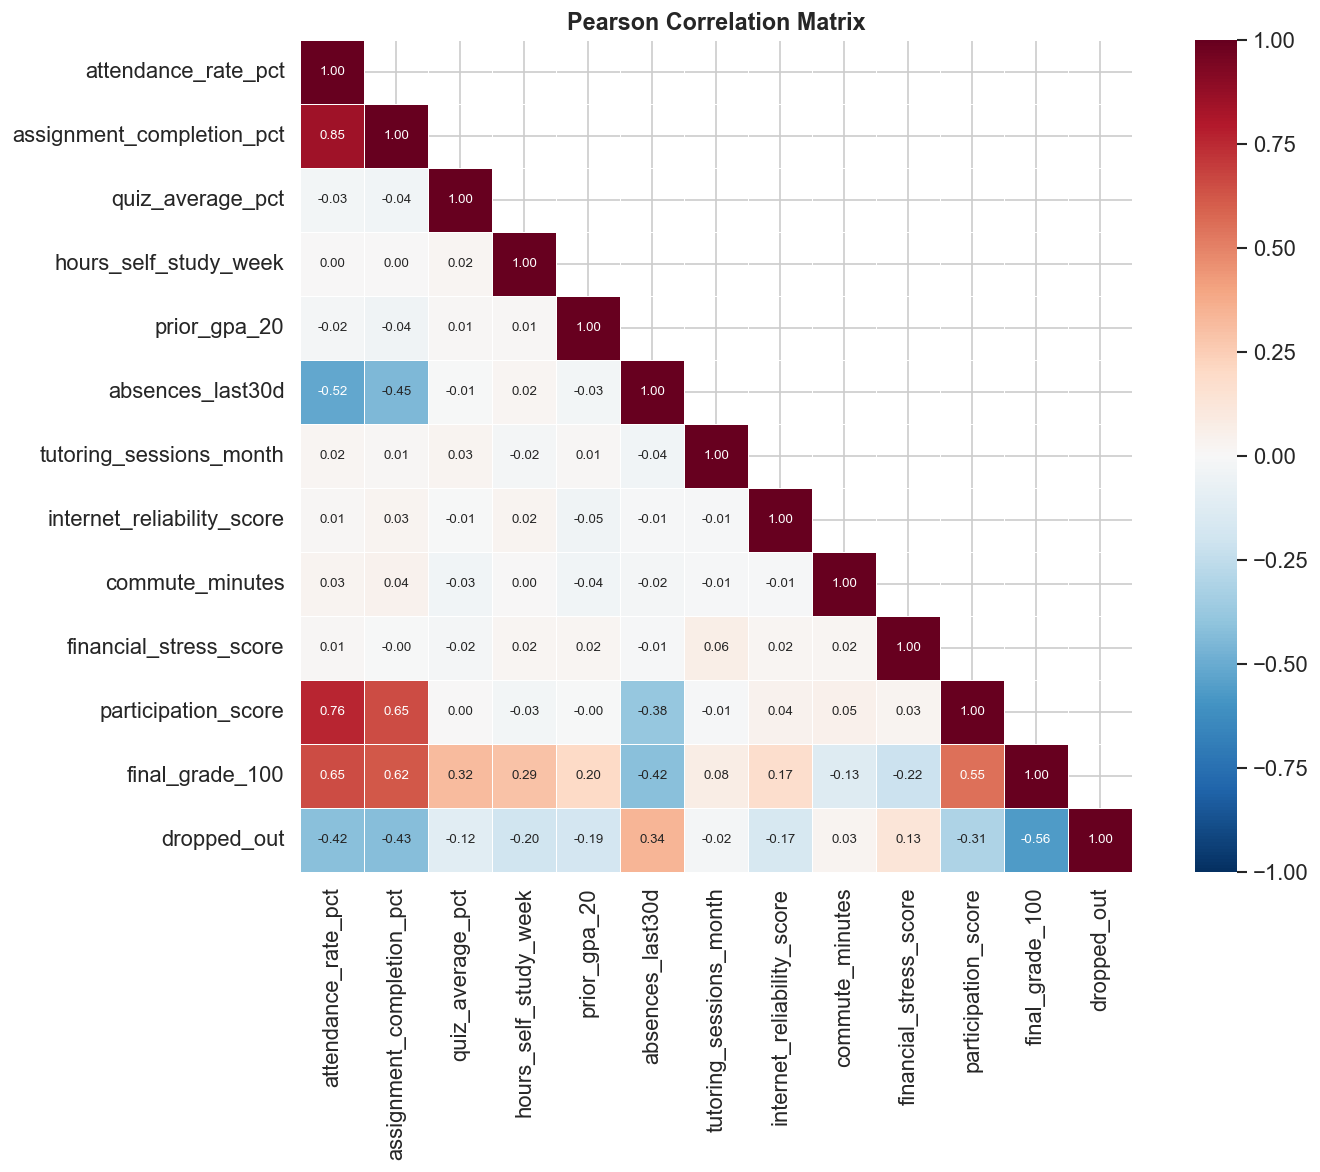

In [428]:
# The correlation matrix shows pairwise Pearson correlations between
# all numeric variables, including the two targets.

corr = df_train[NUMERIC_FEATS + [TARGET_REG, TARGET_CLF]].corr()

# Mask the lower triangle to avoid redundant information
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
mask = ~mask  # keep upper triangle

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=~mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### ***Target correlations at a glance***

| Feature | r (grade) | r (dropout) | Signal tier |
|---|---|---|---|
| `attendance_rate_pct` | **+0.65** | −0.42 | ★ Strong |
| `assignment_completion_pct` | **+0.62** | −0.43 | ★ Strong |
| `participation_score` | +0.55 | −0.31 | ★ Strong |
| `absences_last30d` | −0.42 | **+0.34** | ★ Strong |
| `quiz_average_pct` | +0.32 | −0.12 | Moderate |
| `hours_self_study_week` | +0.29 | −0.20 | Moderate |
| `prior_gpa_20` | +0.20 | −0.19 | Moderate |
| `financial_stress_score` | −0.22 | +0.13 | Weak |
| `internet_reliability_score` | +0.17 | −0.17 | Weak |
| `commute_minutes` | −0.13 | +0.03 | Noise |
| `tutoring_sessions_month` | +0.08 | −0.02 | Noise |
| `dormitory_block` | ≈ 0 | ≈ 0 | Noise |

#### Three deeper observations

**1 — The two targets are proxies of each other (r = −0.56).**  
>***A student who fails tends to drop out; one who stays tends to pass.*** This
means classification regression models will learn broadly the same feature hierarchy.
It means PathFinder's grade and dropout prediction surface different *degrees* of risk even when the direction
agrees.

**2 — Multicollinearity cluster: {attendance, assignment, absences, participation} (r up to 0.85).**  
+ For linear models (Logistic Regression, Ridge), we may need to regularise.
+ Tree-based models split on *one* feature at a time and are immune.

**3 — Independent signals are the most valuable ones.**  
`quiz_average_pct`, `prior_gpa_20`, and `hours_self_study_week` are
nearly uncorrelated with the behavioural cluster (|r| < 0.05 across the
board). Low mutual correlation means they add *orthogonal* information:
even after the model has absorbed attendance and assignment data, these
features still contribute something new. In an ensemble this is exactly
the kind of diversity that reduces variance without inflating bias.

> **Modelling implication:** a compact feature set of
> `{attendance_rate_pct, assignment_completion_pct, participation_score,
> quiz_average_pct, prior_gpa_20, hours_self_study_week}` covers the
> three strong correlated predictors *and* three orthogonal ones — six
> features that together span most of the explainable variance in both
> targets.

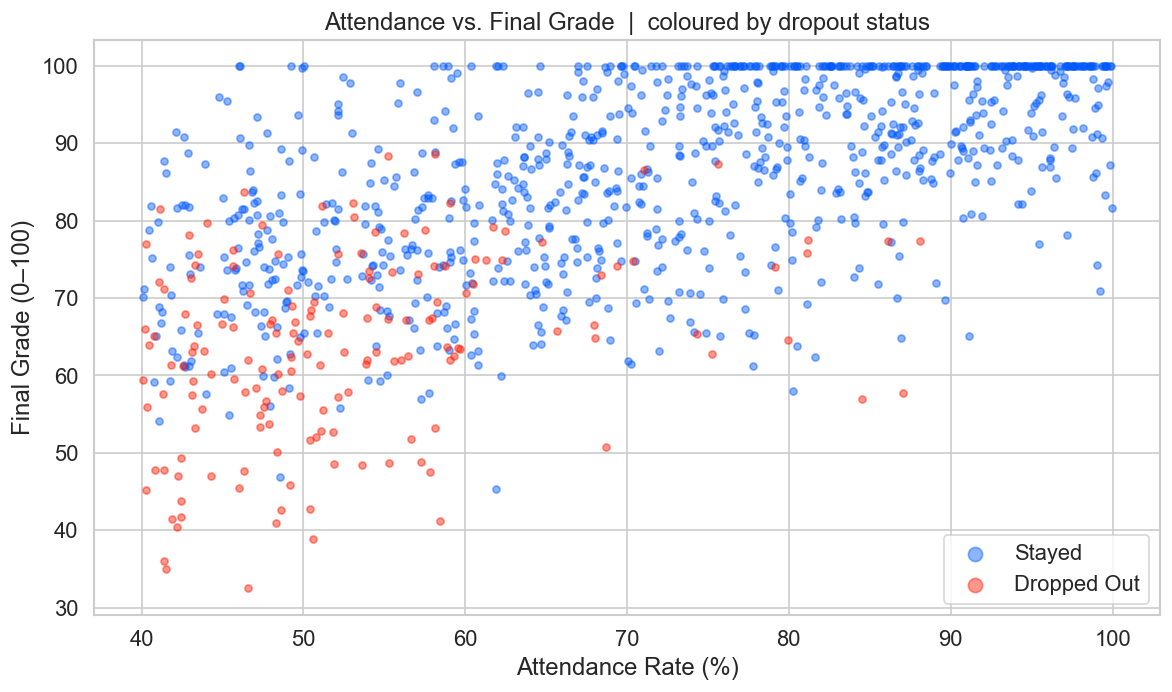

In [429]:
# This scatter plot is the single most narrative visualisation in the EDA.
# Each point is one student. Colour encodes dropout status.
# If the signal is strong, we expect a clear spatial separation
# between blue (stayed) and red (dropped out) regions.

fig, ax = plt.subplots(figsize=(10, 6))
for status, colour, label in [(0, BLUE, 'Stayed'), (1, RED, 'Dropped Out')]:
    mask = df_train[TARGET_CLF] == status
    ax.scatter(
        df_train.loc[mask, 'attendance_rate_pct'],
        df_train.loc[mask, TARGET_REG],
        c=colour, alpha=0.45, s=18, label=label
    )

ax.set_xlabel('Attendance Rate (%)')
ax.set_ylabel('Final Grade (0–100)')
ax.set_title('Attendance vs. Final Grade  |  coloured by dropout status')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

### The spatial separation is already visible without any model.
Three zones emerge naturally:

- **Top-right (high attendance, high grade):** almost exclusively students
  who stayed. This is the comfortable majority.
- **Bottom-left (low attendance, low grade):** a strong concentration of
  dropout students. These are the cases the model must identify early.
- **Middle zone:** the genuinely ambiguous students — present but
  struggling, or absent but passing. This is where the model adds value
  beyond simple rule-based thresholds.

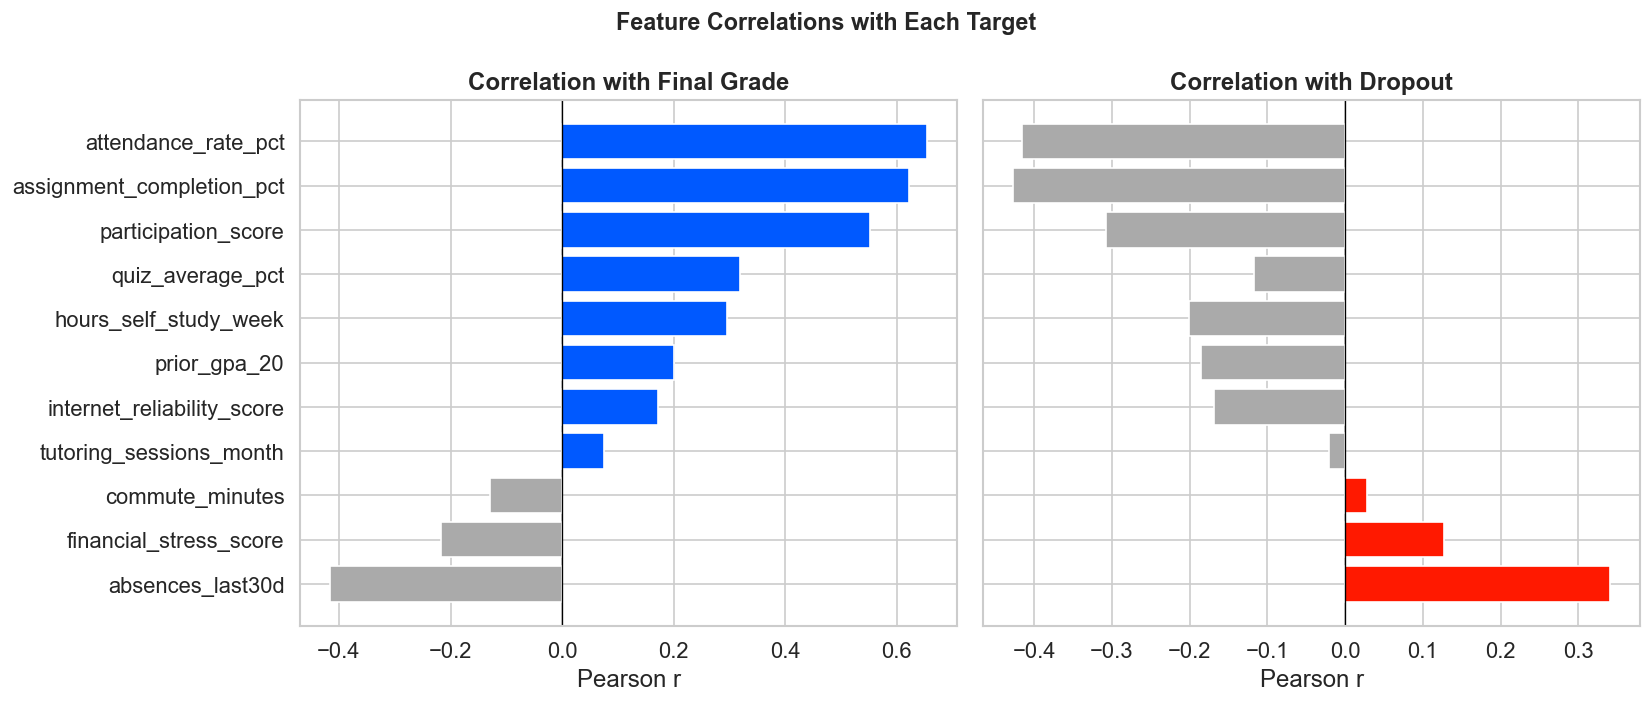

In [430]:
# A side-by-side bar chart makes it easy to compare which features
# matter most for each task and whether the two tasks share the same
# informational structure — a key question for the stacking strategy.

corr_grade   = df_train[NUMERIC_FEATS].corrwith(df_train[TARGET_REG])
corr_dropout = df_train[NUMERIC_FEATS].corrwith(df_train[TARGET_CLF])

corr_df = pd.DataFrame({
    'Grade (r)':   corr_grade,
    'Dropout (r)': corr_dropout
}).sort_values('Grade (r)', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, col, colour, title in zip(
    axes,
    ['Grade (r)', 'Dropout (r)'],
    [BLUE, RED],
    ['Correlation with Final Grade', 'Correlation with Dropout']
):
    bars = ax.barh(corr_df.index, corr_df[col], color=[
        colour if v >= 0 else '#AAAAAA' for v in corr_df[col]
    ], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Pearson r')

fig.suptitle('Feature Correlations with Each Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### The features that best predict the grade also best predict dropout, only with reversed sign (higher grade = less likely to drop out).

---
## EXTRA: 3.4 Global Structure — PCA

Principal Component Analysis (PCA) reduces all 12 features to 2 and then 3 dimensions,
allowing us to visualise the entire dataset in a single plot.

We use PCA here for two purposes:
1. **Visualisation**: does the dropout class cluster separately from the
   rest, or are the two groups hopelessly mixed?
2. **Diagnostics**: which features dominate the first two/three components,
   and how much variance do those components capture?

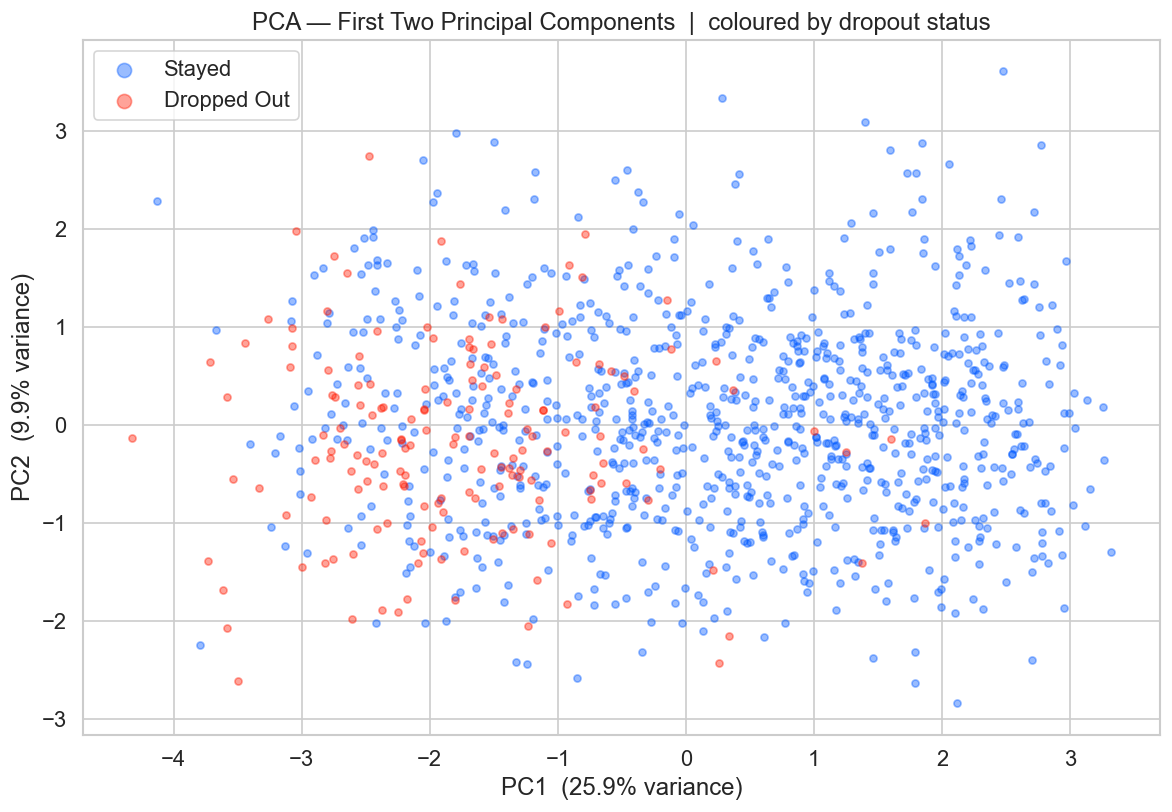

In [431]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA is sensitive to scale — a feature ranging 5–90 would otherwise
# dominate one ranging 0–10. We standardise first so every feature
# contributes on equal footing.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_train[NUMERIC_FEATS])

# We fit PCA on all 11 components to later inspect the full variance curve,
# but use only the first 2 for the scatter plot.
pca = PCA(n_components=11, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# ── Scatter plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for status, colour, label in [(0, BLUE, 'Stayed'), (1, RED, 'Dropped Out')]:
    mask = df_train[TARGET_CLF].values == status
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colour, alpha=0.4, s=18, label=label)

ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA — First Two Principal Components  |  coloured by dropout status')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

In [432]:
# Loadings tell us which original features drive each principal component.
# A high positive loading on PC1 means that feature pushes a student
# toward the right side of the scatter plot.
# A high negative loading means it pushes them to the left.

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=NUMERIC_FEATS,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

print("PCA Loadings — PC1 and PC2:")
print(loadings.round(3).to_string())

PCA Loadings — PC1 and PC2:
                              PC1    PC2
attendance_rate_pct         0.560  0.003
assignment_completion_pct   0.530 -0.041
participation_score         0.501 -0.014
commute_minutes             0.040 -0.310
internet_reliability_score  0.024 -0.265
financial_stress_score      0.015  0.317
tutoring_sessions_month     0.015  0.559
hours_self_study_week      -0.009 -0.047
prior_gpa_20               -0.014  0.539
quiz_average_pct           -0.018  0.336
absences_last30d           -0.390 -0.117


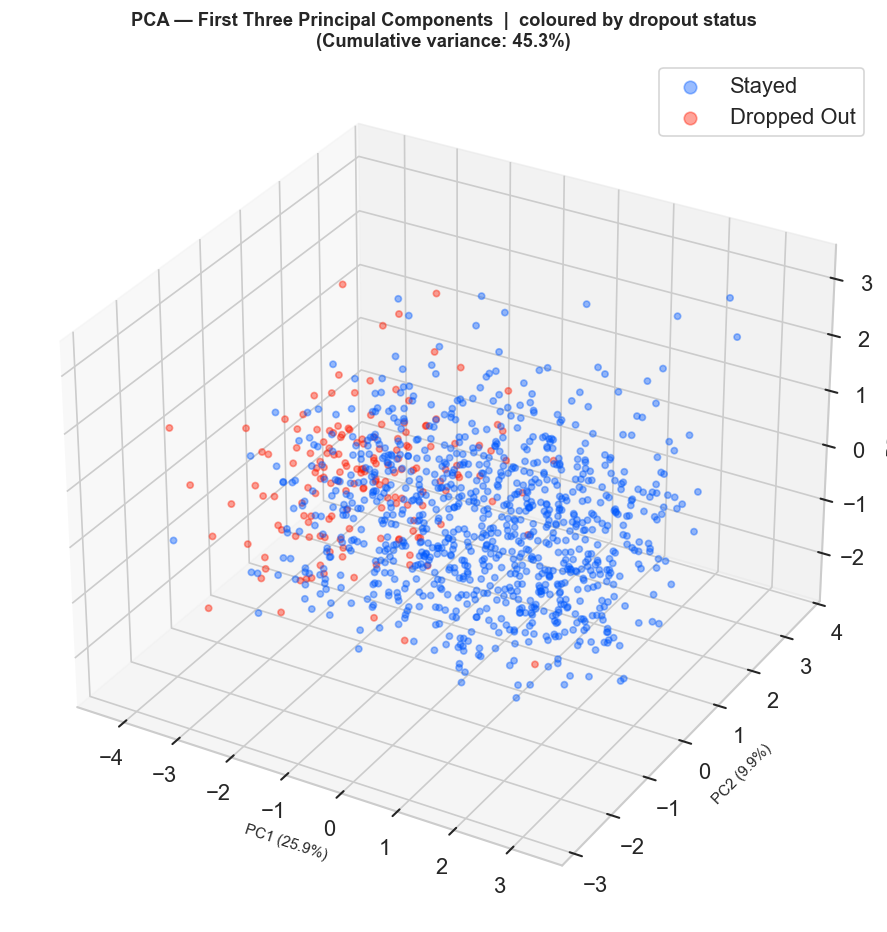

Cumulative variance (PC1–PC3): 45.3%


In [433]:
# 3D PCA scatter — coloured by dropout status
# Uses X_scaled from the 2D PCA cell above (StandardScaler on NUMERIC_FEATS).
# preprocessor is defined later in Section 4; at this point in the EDA we
# only have numeric features, which is sufficient for the visualisation.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca_3d   = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_scaled)   # X_scaled: shape (1100, 11)
var      = pca_3d.explained_variance_ratio_

fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')

for status, colour, label in [(0, BLUE, 'Stayed'), (1, RED, 'Dropped Out')]:
    mask = df_train[TARGET_CLF].values == status
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=colour, alpha=0.4, s=14, label=label)

ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)', fontsize=9)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)', fontsize=9)
ax.set_zlabel(f'PC3 ({var[2]*100:.1f}%)', fontsize=9)
ax.set_title(
    f'PCA — First Three Principal Components  |  coloured by dropout status\n'
    f'(Cumulative variance: {sum(var)*100:.1f}%)',
    fontsize=11, fontweight='bold'
)
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig('pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Cumulative variance (PC1–PC3): {sum(var)*100:.1f}%")


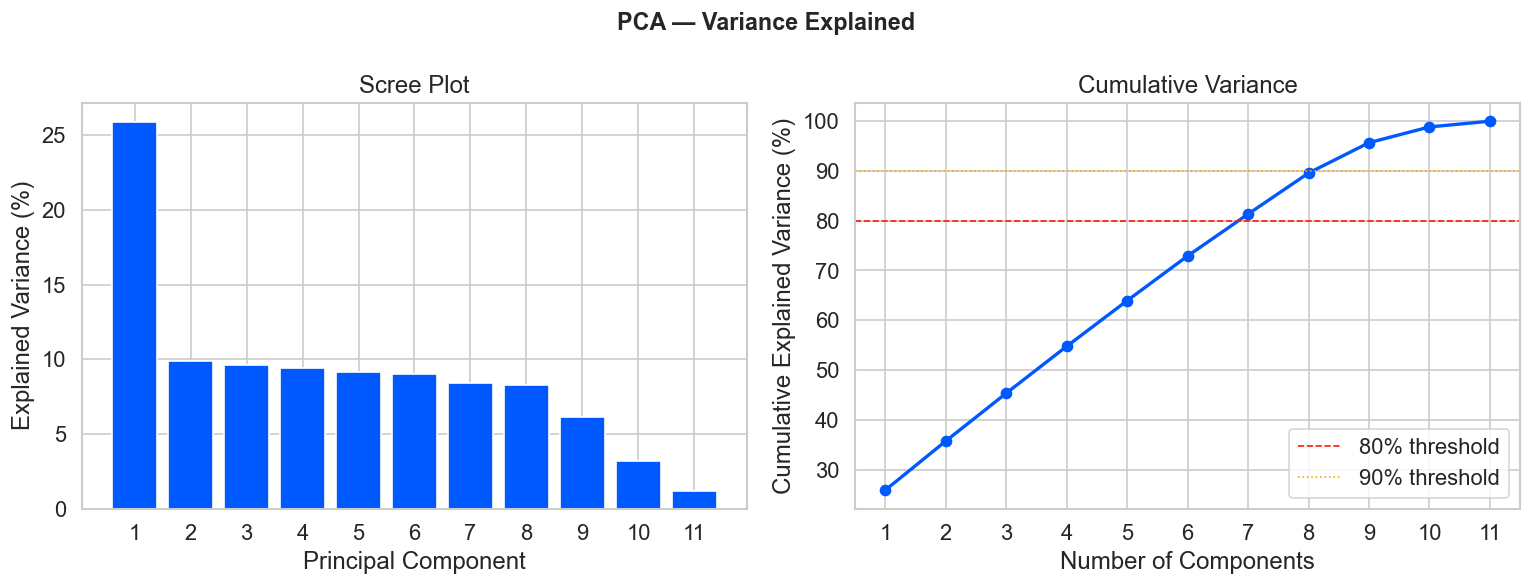

80% variance explained by 7 components
90% variance explained by 9 components


In [434]:
# The scree plot shows how much variance each component captures.
# The 'elbow' in the curve indicates the point of diminishing returns —
# beyond it, additional components explain progressively less.
# We also plot cumulative variance to see how many components are needed
# to reach common thresholds (e.g. 80%, 90%).

var_ratio = pca.explained_variance_ratio_
cum_var   = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual variance per component
axes[0].bar(range(1, 12), var_ratio * 100, color=BLUE, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 12))

# Cumulative variance
axes[1].plot(range(1, 12), cum_var * 100, marker='o', color=BLUE, linewidth=2)
axes[1].axhline(80, color=RED, linestyle='--', linewidth=1, label='80% threshold')
axes[1].axhline(90, color='orange', linestyle=':', linewidth=1, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance')
axes[1].set_xticks(range(1, 12))
axes[1].legend()

fig.suptitle('PCA — Variance Explained', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the numeric thresholds for reference
for threshold in [0.80, 0.90]:
    n = np.argmax(cum_var >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {n} components")

---
+ ### **From the loadings:**
> PC1 is dominated by `attendance_rate_pct`, `assignment_completion_pct`,
and `participation_score` (large positive loadings) against
`absences_last30d` (large negative loading).

### ➡ This confirms that PC1 is essentially an axis of **academic engagement**: students who participate sit at one end; disengaged ones sit at the other.

+ ### **From the scatter plot:**
> Dropout students (red) shift toward the negative end of PC1, while
students who stayed (blue) cluster toward the positive end.
### ➡ The separation is not perfect.

+ ### **From the scree plot:**
> Reaching 80% of the total variance requires approximately 7 components.
Data cannot be summarised by one or two axes without significant information loss.
### ➡ This is a strong argument for trying non-linear models (Random Forest, Gradient Boosting) rather than relying on linear methods alone.

---
## ***3.5 EDA Summary***

The exploratory analysis yields the following conclusions,
which directly shape every decision in Sections 4–6:

| Finding | Implication for modelling |
|---|---|
| Grade distribution is left-skewed | Model will be less reliable on low grades — perhaps a limitation? |
| 85/15 class imbalance | Use `class_weight='balanced'`; avoid accuracy as a metric |
| `attendance` and `assignment_completion` dominate both tasks | Expect these at the top of feature importance rankings |
| `absences_last30d` is the strongest positive dropout signal | A rapidly rising absence count is the key early-warning trigger |
| `attendance` and `assignment_completion` are correlated (r ≈ 0.55) | Monitor for multicollinearity in linear models |
| `dormitory_block` shows near-zero correlation with both targets | May be excluded — or retained and one-hot encoded at low cost |
| Both targets share r ≈ −0.56 | Predicted grade is a candidate feature for the dropout classifier (stacking) |
| 7 components needed for 80% PCA variance | Data is genuinely multidimensional → non-linear models justified |

### These findings do not require any further changes to the data. They are observations that inform preprocessing and model selection, addressed in Sections 4 and 5 respectively.
---
---
---


## ***4. Preprocessing & Feature Engineering**

Raw data cannot be fed directly into most models without preparation.
This section defines the full preprocessing pipeline, which transforms
the 12 input features into a form suitable for all models we will test.

The pipeline is built using `sklearn.pipeline.Pipeline` and
`sklearn.compose.ColumnTransformer`. By wrapping preprocessing inside the
pipeline, we guarantee that the scaler is **fitted only on training data**
at every cross-validation fold and never sees validation or test data
before prediction, avoiding **data leakage** that producea falsely optimistic metrics.

The steps in this section are:
1. Identify and justify the treatment of each feature group
2. Define the `ColumnTransformer` (scaling + encoding)
3. Assemble the full pipeline stubs ready for modelling
4. Verify the pipeline on a small sample before any training

## 4.1 Feature Treatment Decisions

Based on the EDA findings (Section 3), we apply the following treatments:

| Feature group | Features | Treatment | Reason |
|---|---|---|---|
| Continuous numeric | 11 features in `NUMERIC_FEATS` | `StandardScaler` | Equalises scale differences (e.g. commute 5–90 vs stress 0–10) |
| Binary engineered | `tutoring_any` | `passthrough` | Already 0/1 — scaling would distort a binary signal |
| Categorical | `dormitory_block` | `OneHotEncoder` | Integer codes 1–5 are unordered — treating them as numeric imposes a false ordinal relationship |

Two features were engineered from the EDA anomaly analysis before preprocessing:
- **`log1p_absences`** replaces `absences_last30d` in `NUMERIC_FEATS` — compresses
  the long right tail to reduce leverage of high-absence outliers on OLS coefficients
- **`tutoring_any`** is a new binary feature (1 if `tutoring_sessions_month > 0`) —
  captures the zero-inflation signal that the raw count underrepresents

In [435]:
NUMERIC_FEATS = [
    'attendance_rate_pct',
    'assignment_completion_pct',
    'quiz_average_pct',
    'hours_self_study_week',
    'prior_gpa_20',
    'log1p_absences',          # ← replaces absences_last30d
    'tutoring_sessions_month', # ← keep the count too
    'internet_reliability_score',
    'commute_minutes',
    'financial_stress_score',
    'participation_score',
]

CATEGORICAL_FEATS = ['dormitory_block']

# New binary feature — treat as numeric (already 0/1, no scaling needed but harmless)
BINARY_FEATS = ['tutoring_any']

In [436]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ColumnTransformer applies different transformations to different
# column subsets simultaneously, then concatenates the results.
# remainder='drop' ensures no column passes through untransformed —
# every feature is either scaled or encoded, nothing slips through raw.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATS),
        ('bin', 'passthrough',   BINARY_FEATS),   # ← passthrough, no scaling needed
        ('cat', OneHotEncoder(drop='first',
                              sparse_output=False,
                              handle_unknown='ignore'), CATEGORICAL_FEATS),
    ],
    remainder='drop'
)

In [437]:
import numpy as np

# Sanity check: fit the preprocessor on the full training set
# and verify the output shape and that no NaNs are introduced.
# Expected output columns:
#   11 scaled numeric features
# + 4 one-hot columns for dormitory_block (5 blocks minus 1 dropped)
# = 15 total columns

# ── This must run BEFORE X is defined ────────────────────────────────────────
df_train['tutoring_any']    = (df_train['tutoring_sessions_month'] > 0).astype(int)
df_train['log1p_absences']  = np.log1p(df_train['absences_last30d'])

# ── Rebuild X to include the new columns ─────────────────────────────────────
FEATURE_COLS = NUMERIC_FEATS + BINARY_FEATS + CATEGORICAL_FEATS
X = df_train[FEATURE_COLS]  # now includes log1p_absences and tutoring_any

X_check = preprocessor.fit_transform(X)

print("X shape          :", X.shape)           # should be (1100, 16)
print(f"Output shape : {X_check.shape}")
print(f"NaN values   : {np.isnan(X_check).sum()}")
print(f"Output dtype : {X_check.dtype}")
print("X columns        :", list(X.columns))
print("NaN in X         :", X.isna().sum().sum())  # should be 0
print("tutoring_any in X:", 'tutoring_any' in X.columns)      # True
print("log1p_absences   :", 'log1p_absences' in X.columns)    # True

# Verify column count matches expectation
expected_cols = len(NUMERIC_FEATS) + len(BINARY_FEATS) + (df_train['dormitory_block'].nunique() - 1)
assert X_check.shape[1] == expected_cols, \
    f"Expected {expected_cols} columns, got {X_check.shape[1]}"
print(f"\nShape check passed: {X_check.shape[1]} columns as expected.")
# Should print: Shape check passed: 16 columns as expected.



X shape          : (1100, 13)
Output shape : (1100, 16)
NaN values   : 0
Output dtype : float64
X columns        : ['attendance_rate_pct', 'assignment_completion_pct', 'quiz_average_pct', 'hours_self_study_week', 'prior_gpa_20', 'log1p_absences', 'tutoring_sessions_month', 'internet_reliability_score', 'commute_minutes', 'financial_stress_score', 'participation_score', 'tutoring_any', 'dormitory_block']
NaN in X         : 0
tutoring_any in X: True
log1p_absences   : True

Shape check passed: 16 columns as expected.


### 4.2 Pipeline Stubs

We define a helper function that assembles a complete
`Pipeline(preprocessor + model)` for any estimator.
This keeps model definitions in Section 5 clean and uniform —
every model receives exactly the same preprocessing.

> **In plain terms:** think of the pipeline as an assembly line.
> Every student's data enters at one end, gets standardised and encoded
> in the middle, and arrives at the model as a clean, uniform input.
> The same assembly line runs identically during training, validation,
> and final prediction — no manual steps, no room for error.

In [438]:
def make_pipeline(model):
    """
    Wraps any sklearn estimator in the standard preprocessing pipeline.
    Usage: pipe = make_pipeline(RandomForestClassifier(...))
    The preprocessor is cloned internally by Pipeline, so the same
    base preprocessor object can be reused safely across all models.
    """
    return Pipeline([
        ('prep',  preprocessor),
        ('model', model)
    ])



### 4.3 Evaluation Helpers

We define two reusable evaluation functions — one per task — that
compute cross-validated metrics and print them in a consistent format, making comparisons fair and reproducible.

In [439]:
from sklearn.model_selection import cross_validate, cross_val_predict

def evaluate_regressor(pipeline, label=''):
    """
    5-fold CV per un regressore.
    Riporta R², RMSE, MAE (raw) mean ± std per fold.

    MAE e RMSE insieme sono più diagnostici di uno solo:
    - RMSE >> MAE → pochi studenti con errori molto grandi
    - RMSE ≈ MAE  → errori distribuiti uniformemente
    """
    scores = cross_validate(
        pipeline, X, y_reg,
        cv=cv_reg,
        scoring={
            'r2'  : 'r2',
            'rmse': 'neg_root_mean_squared_error',
            'mae' : 'neg_mean_absolute_error',
        },
        n_jobs=-1
    )
    r2   = scores['test_r2']
    rmse = -scores['test_rmse']
    mae  = -scores['test_mae']
    print(f"{'[' + label + ']':30s}  "
          f"R² = {r2.mean():.3f} ± {r2.std():.3f}   "
          f"RMSE = {rmse.mean():.2f} ± {rmse.std():.2f}   "
          f"MAE = {mae.mean():.2f} ± {mae.std():.2f}")


def get_oof(pipeline, label=''):
    """
    OOF predictions + stampa metriche clipped con bande ± per fold.
    Da chiamare subito dopo evaluate_regressor().
    """
    oof_raw  = cross_val_predict(pipeline, X, y_reg, cv=cv_reg, n_jobs=-1)
    oof_clip = np.clip(oof_raw, 0, 100)
    y_arr    = np.array(y_reg)

    # ── Metriche clipped per fold ─────────────────────────────────────────────
    fold_r2, fold_rmse, fold_mae = [], [], []
    for _, test_idx in cv_reg.split(X):
        y_t  = y_arr[test_idx]
        y_p  = oof_clip[test_idx]
        res  = y_t - y_p
        fold_r2.append(  1 - np.sum(res**2) / np.sum((y_t - y_t.mean())**2))
        fold_rmse.append(np.sqrt(np.mean(res**2)))
        fold_mae.append( np.mean(np.abs(res)))

    n_clip = (oof_raw > 100).sum() + (oof_raw < 0).sum()
    print(f"{'[' + label + ' clipped]':30s}  "
          f"R² = {np.mean(fold_r2):.3f} ± {np.std(fold_r2):.3f}   "
          f"RMSE = {np.mean(fold_rmse):.2f} ± {np.std(fold_rmse):.2f}   "
          f"MAE = {np.mean(fold_mae):.2f} ± {np.std(fold_mae):.2f}   "
          f"({n_clip} clipped)")

    return oof_raw, oof_clip


In [440]:
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, f1_score,
    precision_score, recall_score, average_precision_score
)
from sklearn.model_selection import cross_val_predict
import numpy as np

def evaluate_classifier(estimator, label='Classifier',
                        threshold=0.50, verbose=True):
    """
    Evaluates a binary classifier pipeline using OOF predicted probabilities.

    Parameters
    ----------
    estimator   : sklearn pipeline/estimator (unfitted)
    label       : str, display name
    threshold   : float, decision threshold (default 0.50)
    verbose     : bool, if True prints full report

    Returns
    -------
    dict with keys: label, threshold, f1, precision, recall,
                    roc_auc, avg_precision, tn, fp, fn, tp
    """
    y_prob = cross_val_predict(
        estimator, X, y_clf,
        cv=cv_clf, method='predict_proba', n_jobs=-1
    )[:, 1]

    y_true = np.array(y_clf)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'label':         label,
        'threshold':     threshold,
        'f1':            f1_score(y_true, y_pred, zero_division=0),
        'precision':     precision_score(y_true, y_pred, zero_division=0),
        'recall':        recall_score(y_true, y_pred, zero_division=0),
        'roc_auc':       roc_auc_score(y_true, y_prob),
        'avg_precision': average_precision_score(y_true, y_prob),
        'tn': int(tn), 'fp': int(fp),
        'fn': int(fn), 'tp': int(tp),
    }

    if verbose:
        print("=" * 55)
        print(f"  {label}  |  τ = {threshold}")
        print("=" * 55)
        print(f"  ROC-AUC          : {metrics['roc_auc']:.3f}")
        print(f"  Avg Precision    : {metrics['avg_precision']:.3f}")
        print(f"  F1               : {metrics['f1']:.3f}")
        print(f"  Precision        : {metrics['precision']:.3f}")
        print(f"  Recall           : {metrics['recall']:.3f}")
        print()
        print(f"  Confusion matrix (τ={threshold}):")
        print(f"  {'':10}  Pred 0   Pred 1")
        print(f"  {'True 0':10}  {tn:>6}   {fp:>6}  (TN, FP)")
        print(f"  {'True 1':10}  {fn:>6}   {tp:>6}  (FN, TP)")
        print()
        print(f"  Missed dropouts (FN) : {fn}")
        print(f"  False alarms    (FP) : {fp}")
        print("=" * 55)

    return metrics


## Plot Helper

In [441]:
from scipy.stats import binned_statistic

# ── Palette di default ────────────────────────────────────────────────────────
DEFAULT_PALETTE = {
    'scatter'     : "#0099FF",   # scatter dots
    'perfect_fit' : '#222222',   # diagonal 1:1 line
    'bin_mean'    : "#FF0000",   # binned mean line
    'residual_bar': "#0099FF",   # histogram bars
    'zero_line'   : '#555555',   # horizontal / vertical zero reference
    'mean_line'   : "#FF0000",   # residual mean vline
}

def plot_regression_diagnostics(
    y_true, y_pred_raw,
    label   = 'Model',
    save    = True,
    palette : dict = None,       # ← nuovo parametro
):
    """
    Tre pannelli diagnostici per un modello di regressione.

    Parameters
    ----------
    y_true, y_pred_raw : array-like
    label              : str — titolo / nome file
    save               : bool — salva PNG
    palette            : dict con chiavi opzionali:
                           'scatter', 'perfect_fit', 'bin_mean',
                           'residual_bar', 'zero_line', 'mean_line'
                         I valori mancanti vengono presi da DEFAULT_PALETTE.
    """
    # ── Merge palette ─────────────────────────────────────────────────────────
    p = {**DEFAULT_PALETTE, **(palette or {})}

    # ── Calcoli ───────────────────────────────────────────────────────────────
    y_true     = np.array(y_true)
    y_pred_raw = np.array(y_pred_raw)
    y_pred     = np.clip(y_pred_raw, 0, 100)
    residuals  = y_true - y_pred

    n_clipped  = (y_pred_raw > 100).sum() + (y_pred_raw < 0).sum()
    rmse_raw   = np.sqrt(np.mean((y_true - y_pred_raw) ** 2))
    rmse_clip  = np.sqrt(np.mean(residuals ** 2))
    r2_clip    = 1 - np.sum(residuals**2) / np.sum((y_true - y_true.mean())**2)
    skew       = float(pd.Series(residuals).skew())

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'─'*50}")
    print(f"  {label} — Diagnostic Summary")
    print(f"{'─'*50}")
    print(f"  R²   (clipped) : {r2_clip:.3f}")
    print(f"  RMSE (raw)     : {rmse_raw:.3f}")
    print(f"  RMSE (clipped) : {rmse_clip:.3f}")
    print(f"  Predictions clipped : {n_clipped} ({n_clipped/len(y_true)*100:.1f}%)")
    print(f"  Residual mean  : {residuals.mean():.3f}  (ideal: 0)")
    print(f"  Residual std   : {residuals.std():.3f}")
    print(f"  Residual skew  : {skew:.3f}  (ideal: ~0, |skew|>1 = concern)")
    print(f"{'─'*50}\n")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f'{label}   |   R²={r2_clip:.3f}   RMSE={rmse_clip:.2f}   '
        f'({n_clipped} predictions clipped)',
        fontsize=13, fontweight='bold'
    )

    # Panel 1 — Actual vs Predicted
    ax = axes[0]
    ax.scatter(y_true, y_pred, alpha=0.35, s=14, color=p['scatter'])
    lims = [0, 100]
    ax.plot(lims, lims, '--', color=p['perfect_fit'],
            linewidth=1.2, label='Perfect fit')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Grade'); ax.set_ylabel('Predicted Grade')
    ax.set_title('Actual vs Predicted')
    ax.legend(fontsize=9)

    # Panel 2 — Residuals vs Predicted
    ax = axes[1]
    ax.scatter(y_pred, residuals, alpha=0.35, s=14, color=p['scatter'])
    ax.axhline(0, color=p['zero_line'], linewidth=1.2, linestyle='--')
    bin_means, bin_edges, _ = binned_statistic(
        y_pred, residuals, statistic='mean', bins=15)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, bin_means, color=p['bin_mean'],
            linewidth=2, label='Bin mean residual')
    ax.set_xlabel('Predicted Grade'); ax.set_ylabel('Residual (actual − predicted)')
    ax.set_title('Residuals vs Predicted')
    ax.legend(fontsize=9)

    # Panel 3 — Residual Distribution
    ax = axes[2]
    ax.hist(residuals, bins=40, color=p['residual_bar'],
            edgecolor='white', alpha=0.85)
    ax.axvline(0, color=p['zero_line'], linewidth=1.2, linestyle='--')
    ax.axvline(residuals.mean(), color=p['mean_line'], linewidth=1.5,
               linestyle='-', label=f'Mean={residuals.mean():.2f}')
    ax.set_xlabel('Residual (actual − predicted)')
    ax.set_ylabel('Count')
    ax.set_title('Residual Distribution')
    ax.legend(fontsize=9)

    plt.tight_layout()
    if save:
        fname = (label.lower()
                      .replace(' ', '_')
                      .replace('(', '')
                      .replace(')', ''))
        plt.savefig(f'diagnostics_{fname}.png', dpi=150, bbox_inches='tight')
        print(f"Saved → diagnostics_{fname}.png")
    plt.show()

---
## **4.4 Baseline Models**

### "What score would we get by ignoring the features entirely?"*

Any model that cannot beat its baseline is not learning anything useful.
The baseline scores are the floor every real model must exceed.

#### ➡ For **$Regression$**, the baseline predicts the training mean for every student:
$$\hat{y} = \bar{y}_{\text{train}}$$
This gives R² = 0 by definition and RMSE equal to the standard deviation
of the target — the worst-case reference point.

#### ➡ For **$Classification$**, the baseline always predicts the majority class ("stayed").
This gives F1 = 0 on the dropout class, because it never
predicts a positive — making it useless despite its high accuracy.

---

BASELINES
[Dummy (mean)]                  R² = -0.006 ± 0.006   RMSE = 14.55 ± 0.40   MAE = 12.19 ± 0.30

──────────────────────────────────────────────────
  Dummy (mean) — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : -0.002
  RMSE (raw)     : 14.556
  RMSE (clipped) : 14.556
  Predictions clipped : 0 (0.0%)
  Residual mean  : 0.000  (ideal: 0)
  Residual std   : 14.556
  Residual skew  : -0.646  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_dummy_mean.png


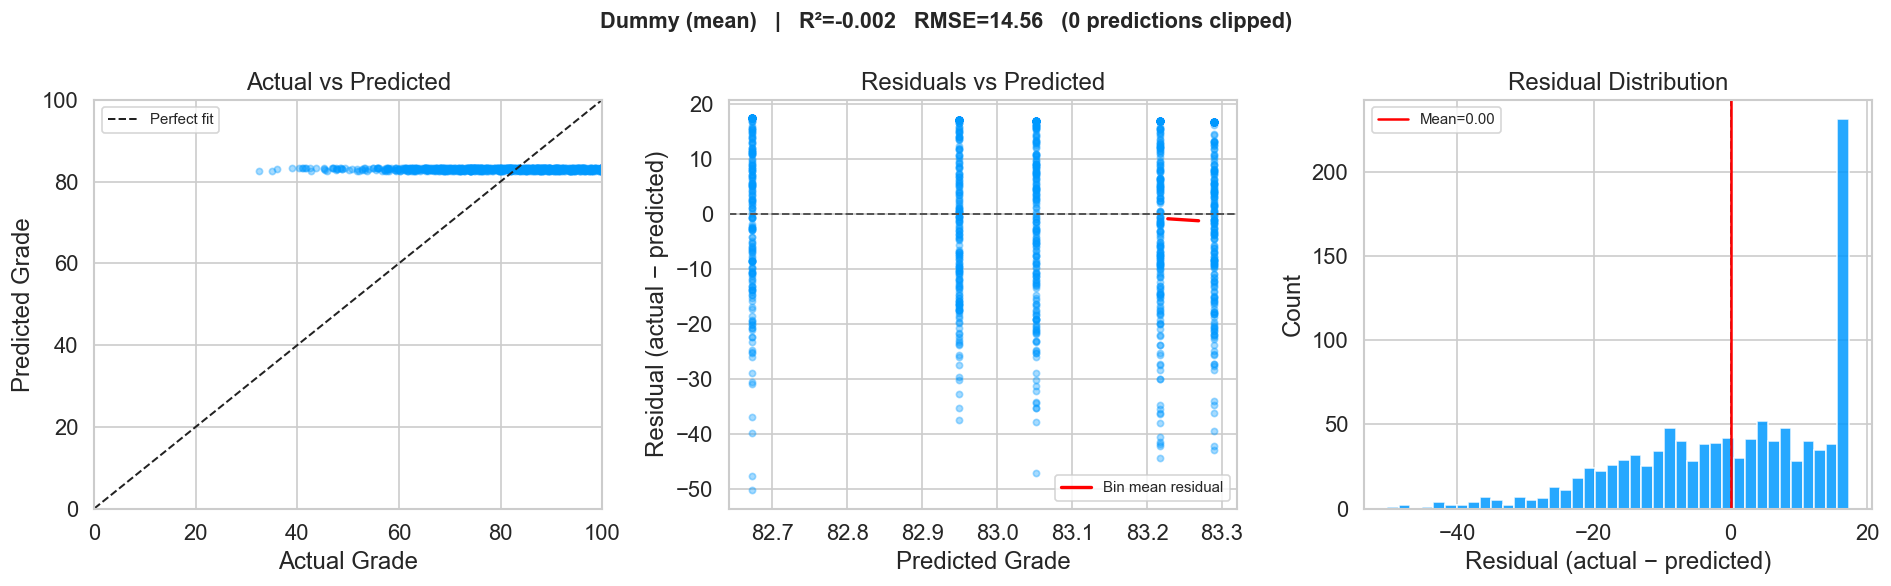

  Dummy (majority)  |  τ = 0.5
  ROC-AUC          : 0.500
  Avg Precision    : 0.150
  F1               : 0.000
  Precision        : 0.000
  Recall           : 0.000

  Confusion matrix (τ=0.5):
              Pred 0   Pred 1
  True 0         935        0  (TN, FP)
  True 1         165        0  (FN, TP)

  Missed dropouts (FN) : 165
  False alarms    (FP) : 0

Any real model must exceed these scores to be considered useful.


In [442]:
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.model_selection import cross_val_predict

print("=" * 75)
print("BASELINES")
print("=" * 75)

# ── Regression baseline ───────────────────────────────────────────────────────
dummy_reg_pipe = make_pipeline(DummyRegressor(strategy='mean'))

evaluate_regressor(dummy_reg_pipe, label='Dummy (mean)')

oof_dummy = cross_val_predict(dummy_reg_pipe, X, y_reg, cv=cv_reg, n_jobs=-1)
plot_regression_diagnostics(y_reg, oof_dummy, label='Dummy (mean)')

# ── Classification baseline ───────────────────────────────────────────────────
# No diagnostic plot here — plot_regression_diagnostics is regression-only
evaluate_classifier(
    make_pipeline(DummyClassifier(strategy='most_frequent')),
    label='Dummy (majority)'
)

print()
print("Any real model must exceed these scores to be considered useful.")

---
## **Summary**

The preprocessing pipeline is now fully defined and verified:

| Step | Tool | Applied to |
|---|---|---|
| Standardisation ($z = \frac{x-\mu}{\sigma}$) | `StandardScaler` | 11 numeric features |
| One-hot encoding (drop first) | `OneHotEncoder` | `dormitory_block` |
| Pipeline wrapper | `sklearn.Pipeline` | All models in Section 5 |

Key guarantees provided by this setup:
- **No data leakage**: the scaler fits only on training folds, never on validation or test data
- **Consistency**: every model receives identically preprocessed input
- **Reproducibility**: no manual transformation steps outside the pipeline

---
---
---

# ***5. Modeling***

The strategy follows a deliberate progression:

1. **Simple interpretable models** (Linear/Logistic Regression) —
   establish what a well-tuned linear model can achieve
2. **Ensemble models** (Random Forest) — capture non-linear structure
3. **Boosting models** (Gradient Boosting) — push performance further
4. **Hyperparameter tuning** on the best model per task
5. **Error analysis** — understand where and why the models fail

Each step builds on the previous one, and the gap
between steps tells us something meaningful about the structure of the
problem.

---
## ***5.1 Task 1 — Grade Regression***

**Goal:** predict `final_grade_100` (continuous, 0–100) from the 12 input features.

**Primary metrics:** R² (higher is better) and RMSE (lower is better), both evaluated
via 5-fold cross-validation with out-of-fold predictions. All predictions are clipped to [0, 100] after inference — grades outside this range
are mathematically impossible and clipping is a zero-cost improvement (see Section 5.1.4).


**Baseline to beat:**
- R² = 0.000 — predicting the training mean every time
- RMSE = 14.55 — equivalent to the standard deviation of `final_grade_100`

**Modelling strategy:**

| Step | Section | Models | Purpose |
|---|---|---|---|
| 1 | 5.1.1 | Ceiling effect discovery ➡ Clipping fix | Diagnose structural prediction problem ➡ Enforce valid prediction range [0, 100] |
| 2 | 5.1.2 | Linear Regression, Ridge CV, Lasso CV | Establish linear ceiling |
| 3 | 5.1.3 | Random Forest, Gradient Boosting | Test for non-linear signal |
| 4 | 5.1.4 | All models comparison | Definitive clipped leaderboard |
| 5 | 5.1.5 | Error analysis | Where and why the model fails |
| 6 | 5.1.6 | Polynomial, WLS, HGB | Attempts to reduce systematic bias |
| 7 | 5.1.7 | Final model selection | Justified recommendation |

#### _Each step builds evidence — the gaps (or lack of them) between steps are themselves propedeutic findings!_

---
## ***5.1.1 Linear Models - Ceiling predictions***

### (_The diagnostic plots in our first draft of this notebook revealed a triangular wedge of dots in the top-right corner of the Residuals vs Predicted panel._)

Predictions > 100 : 115 (10.5%)
Predictions < 0   : 0   (0.0%)
Valid range [0,100]: 985 (89.5%)


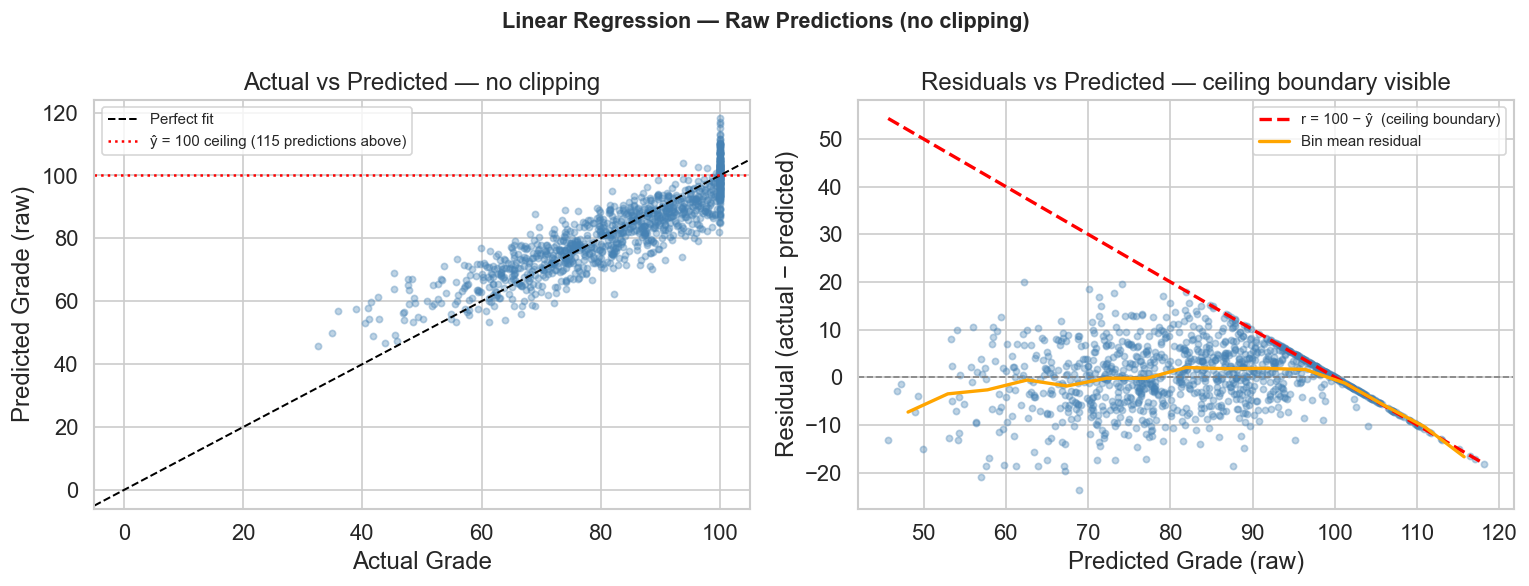

Saved → ceiling_effect_discovery.png


In [443]:
from scipy.stats import binned_statistic
from sklearn.linear_model import LinearRegression

# Raw OOF predictions — Linear Regression, no clipping
preds_raw = cross_val_predict(
    make_pipeline(LinearRegression()), X, y_reg, cv=cv_reg, n_jobs=-1)
y_arr     = np.array(y_reg)

n_above_100 = (preds_raw > 100).sum()
n_below_0   = (preds_raw < 0).sum()
print(f"Predictions > 100 : {n_above_100} ({n_above_100/len(preds_raw)*100:.1f}%)")
print(f"Predictions < 0   : {n_below_0}   ({n_below_0/len(preds_raw)*100:.1f}%)")
print(f"Valid range [0,100]: {len(preds_raw)-n_above_100-n_below_0} ({(len(preds_raw)-n_above_100-n_below_0)/len(preds_raw)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Linear Regression — Raw Predictions (no clipping)",
             fontsize=13, fontweight='bold')

# ── Panel 1: Actual vs Predicted — raw ───────────────────────────────────────
ax = axes[0]
ax.scatter(y_arr, preds_raw, alpha=0.35, s=14, color='steelblue')
ax.axline((0, 0), slope=1, color='black', linewidth=1.2,
          linestyle='--', label='Perfect fit')
ax.axhline(100, color='red', linewidth=1.5, linestyle=':',
           label=f'ŷ = 100 ceiling ({n_above_100} predictions above)')
ax.set_xlabel('Actual Grade')
ax.set_ylabel('Predicted Grade (raw)')
ax.set_title('Actual vs Predicted — no clipping')
ax.legend(fontsize=9)

# ── Panel 2: Residuals vs Predicted — ceiling constraint visible ──────────────
residuals_raw = y_arr - preds_raw
x_range = np.linspace(preds_raw.min(), preds_raw.max(), 200)

ax = axes[1]
ax.scatter(preds_raw, residuals_raw, alpha=0.35, s=14, color='steelblue')
ax.axhline(0, color='grey', linewidth=1, linestyle='--')
ax.plot(x_range, 100 - x_range, color='red', linewidth=2,
        linestyle='--', label='r = 100 − ŷ  (ceiling boundary)')

bin_means, bin_edges, _ = binned_statistic(
    preds_raw, residuals_raw, statistic='mean', bins=15)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, bin_means, color='orange',
        linewidth=2, label='Bin mean residual')

ax.set_xlabel('Predicted Grade (raw)')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals vs Predicted — ceiling boundary visible')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ceiling_effect_discovery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ceiling_effect_discovery.png")

### **10.5% of raw predictions exceed 100** — mathematically impossible grades.
These are guaranteed errors by definition, and they inflate RMSE unnecessarily.

The right panel: For any prediction
$\hat{y} > 100$, the residual is bounded by:

$$r = y - \hat{y} < 100 - \hat{y} < 0$$

This creates the hard diagonal edge visible as a red dashed line — the
**ceiling constraint**. Every dot above the line is a student whose
prediction was pulled above 100, creating a forced negative residual
regardless of the true grade.

OLS has no knowledge that grades cannot exceed 100. The fix is immediate and has no downsides.

### ➡ Prediction Clipping — Enforcing the Valid Range

We wrap every model in a `ClippedRegressor` that applies
`np.clip(ŷ, 0, 100)` after prediction. Training is unchanged — the output is constrained to the valid grade range:

$$\hat{y}_{\text{clipped}} = \min(\max(\hat{y},\ 0),\ 100)$$

In [444]:
from sklearn.base import BaseEstimator, RegressorMixin, clone

class ClippedRegressor(BaseEstimator, RegressorMixin):
    """
    Wraps any regressor and clips predictions to [lower, upper].
    Training is unchanged — only post-processes the output.
    Addresses the ceiling/floor effect: unconstrained models can predict
    values outside the valid range (e.g. grade > 100 or grade < 0).
    """
    def __init__(self, estimator, lower=0, upper=100):
        self.estimator = estimator
        self.lower     = lower
        self.upper     = upper

    def fit(self, X, y):
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y)
        return self

    def predict(self, X):
        return np.clip(self.estimator_.predict(X), self.lower, self.upper)

---
## ***5.1.2 Linear Baselines — Linear Regression, Ridge CV, Lasso CV***

We begin with three regularised linear models. All three assume the final grade
is a weighted sum of the input features:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

The coefficients are chosen to minimise the sum of squared residuals. Ridge and
Lasso add a penalty term to prevent overfitting:

- **Ridge (L2):** $L = \sum(y_i - \hat{y}_i)^2 + \alpha \sum \beta_j^2$ — shrinks all
  coefficients toward zero, none reach exactly zero
- **Lasso (L1):** $L = \sum(y_i - \hat{y}_i)^2 + \alpha \sum |\beta_j|$ — drives
  irrelevant coefficients to exactly zero, performing automatic feature selection

The regularisation strength $\alpha$ is selected by cross-validation (`RidgeCV`,
`LassoCV`) over a logarithmic grid — the optimal value depends on the data and
cannot be assumed in advance.

TASK 1 — GRADE REGRESSION
[Linear Regression]             R² = 0.792 ± 0.009   RMSE = 6.61 ± 0.17   MAE = 5.19 ± 0.17
[Linear Regression clipped]     R² = 0.812 ± 0.008   RMSE = 6.28 ± 0.18   MAE = 4.68 ± 0.22   (115 clipped)

──────────────────────────────────────────────────
  Linear Regression — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.813
  RMSE (raw)     : 6.613
  RMSE (clipped) : 6.285
  Predictions clipped : 115 (10.5%)
  Residual mean  : 0.503  (ideal: 0)
  Residual std   : 6.265
  Residual skew  : -0.261  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_linear_regression.png


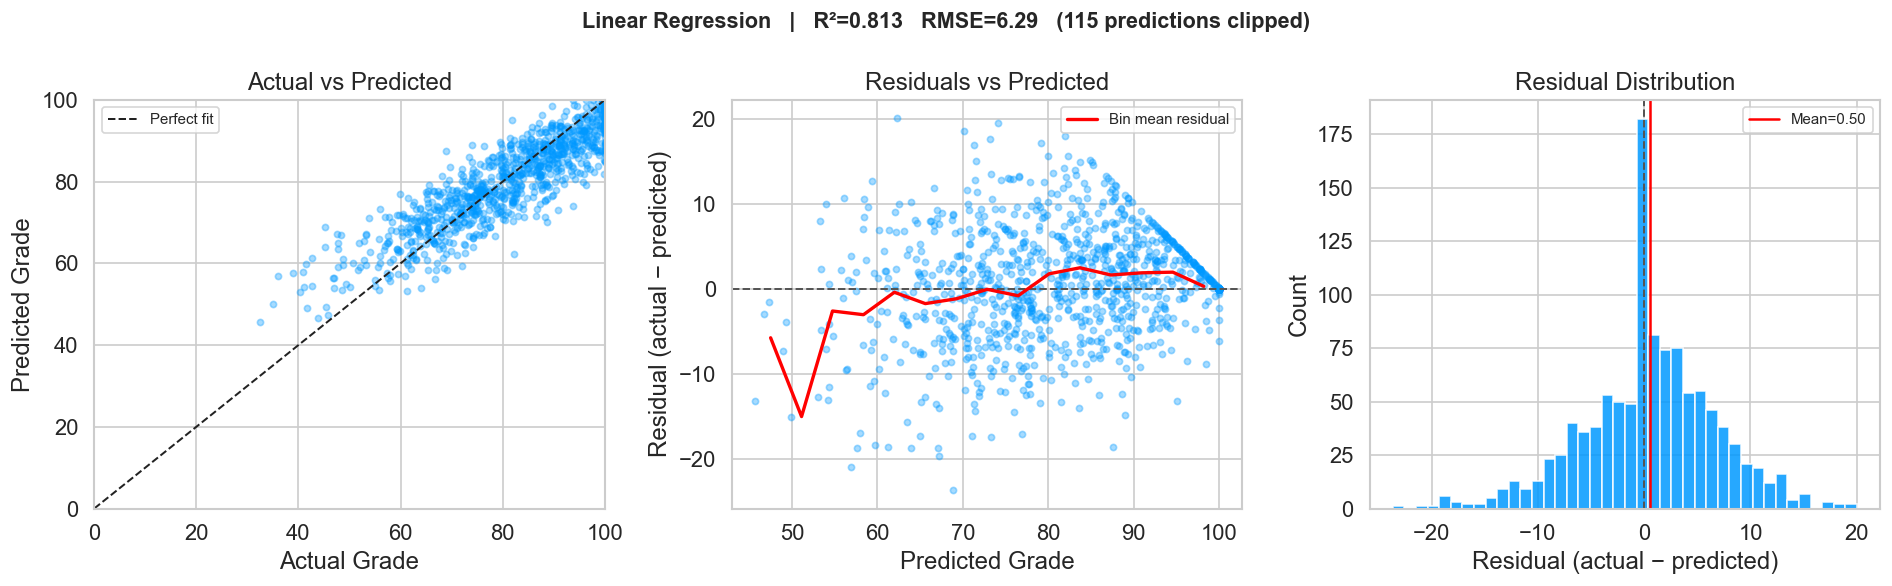

[Ridge CV]                      R² = 0.793 ± 0.009   RMSE = 6.60 ± 0.18   MAE = 5.18 ± 0.17
[Ridge CV clipped]              R² = 0.811 ± 0.008   RMSE = 6.31 ± 0.19   MAE = 4.70 ± 0.22   (108 clipped)

──────────────────────────────────────────────────
  Ridge CV — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.812
  RMSE (raw)     : 6.607
  RMSE (clipped) : 6.310
  Predictions clipped : 108 (9.8%)
  Residual mean  : 0.472  (ideal: 0)
  Residual std   : 6.292
  Residual skew  : -0.280  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_ridge_cv.png


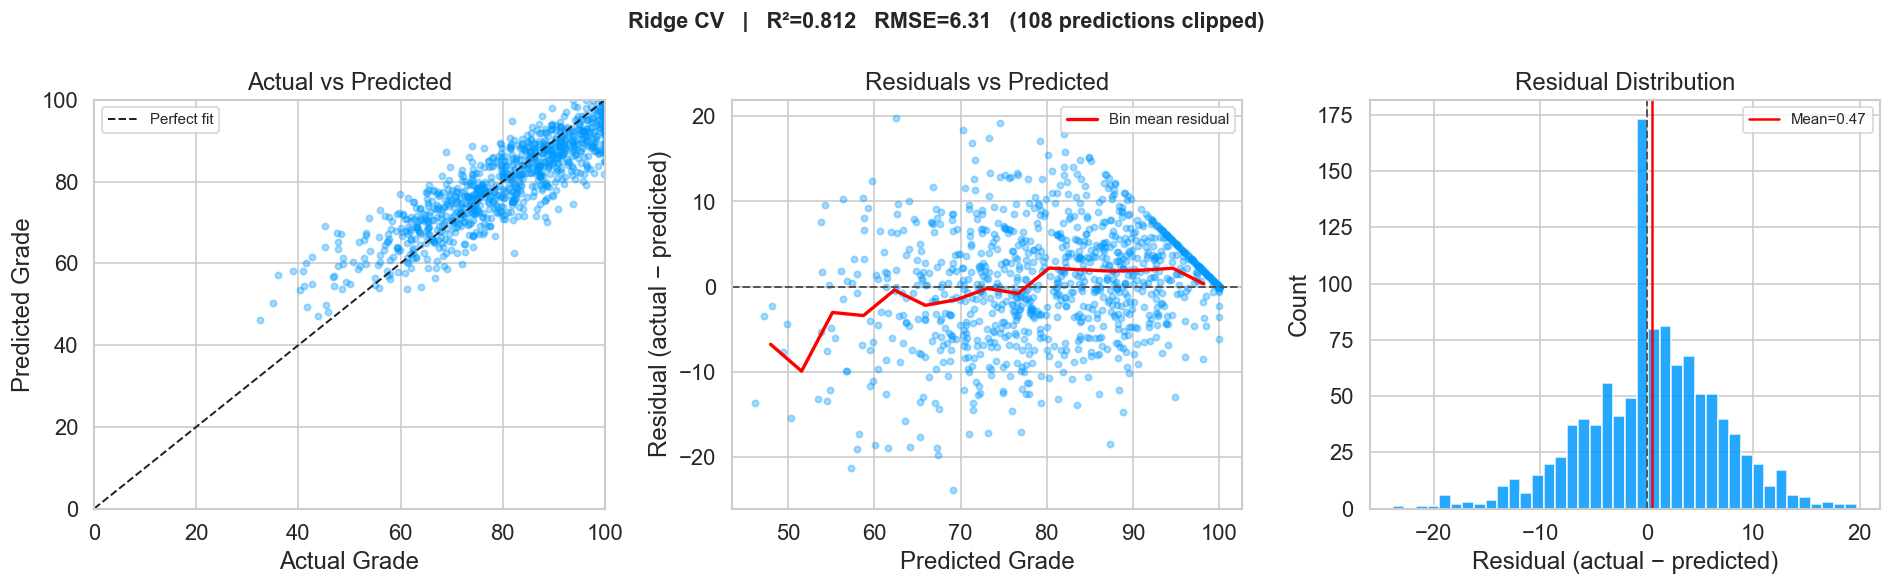

[Lasso CV]                      R² = 0.793 ± 0.008   RMSE = 6.59 ± 0.19   MAE = 5.16 ± 0.17
[Lasso CV clipped]              R² = 0.811 ± 0.008   RMSE = 6.31 ± 0.22   MAE = 4.70 ± 0.22   (108 clipped)

──────────────────────────────────────────────────
  Lasso CV — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.812
  RMSE (raw)     : 6.595
  RMSE (clipped) : 6.312
  Predictions clipped : 108 (9.8%)
  Residual mean  : 0.461  (ideal: 0)
  Residual std   : 6.295
  Residual skew  : -0.291  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_lasso_cv.png


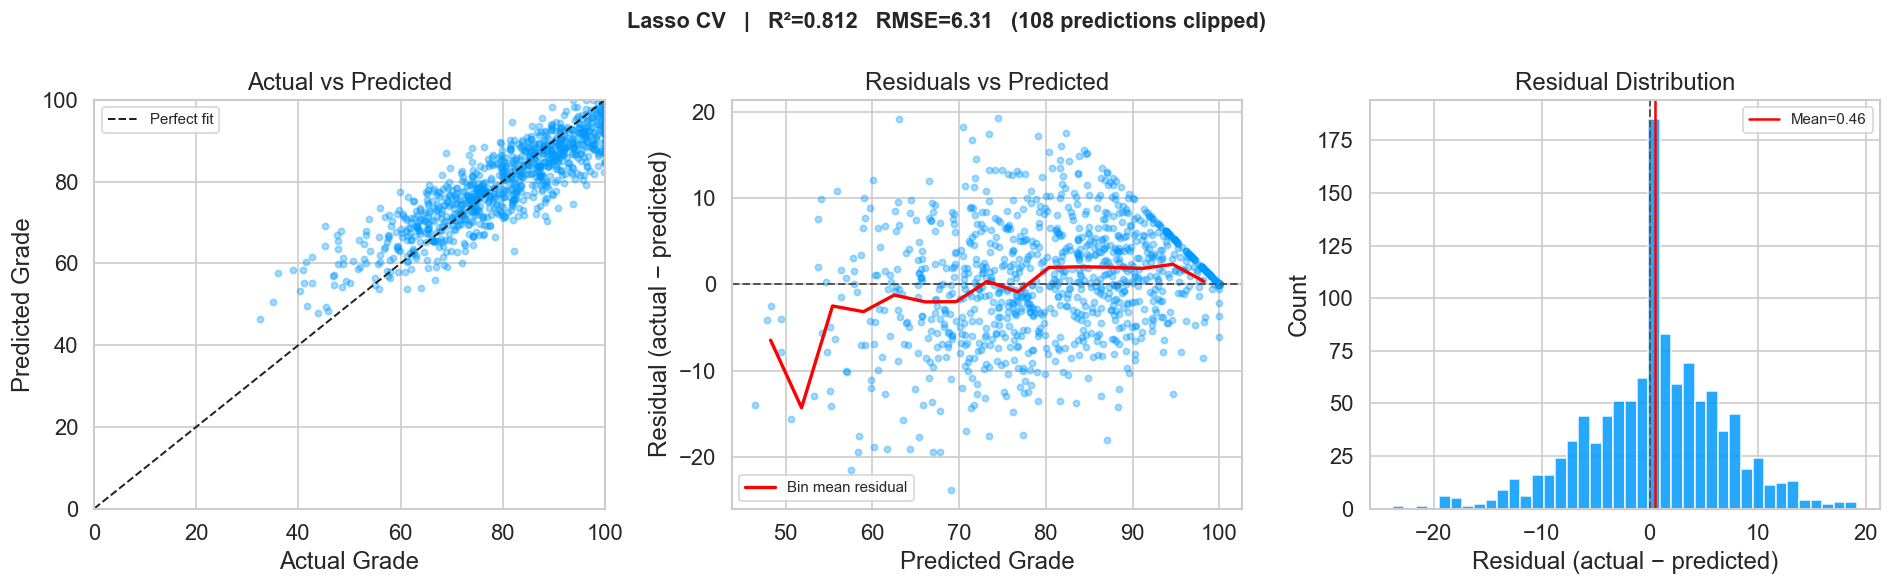

Ridge selected α : 18.4207
Lasso selected α : 0.1151
Lasso zeroed     : 5 / 16 features


In [445]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import cross_val_predict
import numpy as np

print("=" * 75)
print("TASK 1 — GRADE REGRESSION")
print("=" * 75)

alphas = np.logspace(-2, 2, 50)

# ── Linear Regression ─────────────────────────────────────────────────────────
lr_pipe = make_pipeline(LinearRegression())
evaluate_regressor(lr_pipe, label='Linear Regression')
oof_lr_raw, oof_lr = get_oof(lr_pipe, label='Linear Regression')
plot_regression_diagnostics(y_reg, oof_lr_raw, label='Linear Regression')

# ── Ridge CV ──────────────────────────────────────────────────────────────────
ridge_pipe = make_pipeline(RidgeCV(alphas=alphas, cv=5))
evaluate_regressor(ridge_pipe, label='Ridge CV')
oof_ridge_raw, oof_ridge = get_oof(ridge_pipe, label='Ridge CV')
plot_regression_diagnostics(y_reg, oof_ridge_raw, label='Ridge CV')

# ── Lasso CV ──────────────────────────────────────────────────────────────────
lasso_pipe = make_pipeline(
    LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=RANDOM_STATE))
evaluate_regressor(lasso_pipe, label='Lasso CV')
oof_lasso_raw, oof_lasso = get_oof(lasso_pipe, label='Lasso CV')
plot_regression_diagnostics(y_reg, oof_lasso_raw, label='Lasso CV')

# ── Inspect selected regularisation strengths ─────────────────────────────────
# Use your make_pipeline wrapper (preprocessor + model) — step name is 'model'
ridge_fitted = make_pipeline(RidgeCV(alphas=alphas, cv=5)).fit(X, y_reg)
lasso_fitted = make_pipeline(
    LassoCV(alphas=alphas, cv=5, max_iter=5000,
            random_state=RANDOM_STATE)).fit(X, y_reg)

print(f"Ridge selected α : {ridge_fitted.named_steps['model'].alpha_:.4f}")
print(f"Lasso selected α : {lasso_fitted.named_steps['model'].alpha_:.4f}")

lasso_coefs = lasso_fitted.named_steps['model'].coef_
n_zeroed    = (lasso_coefs == 0).sum()
print(f"Lasso zeroed     : {n_zeroed} / {len(lasso_coefs)} features")

---
## **Reading the Diagnostic Plots — Linear Model Family**

### All three models (Linear, Ridge, Lasso) produce near-identical diagnostics, confirming that regularisation adds no meaningful signal at this scale.

#### **Panel 1 — Actual vs Predicted:** strong diagonal structure confirms genuine predictive power.
> ##### ➡ **Visible scatter in the 55–75 range** may reflect how students in this grade range have the most variable behavioural profiles.

#### **Panel 2 — Residuals vs Predicted:**
> ##### ➡ **Low predictions (50–65):** mean residual is strongly negative — the model  over-predicts weak students, pulling their predicted grades above reality

#### **Panel 3 — Residual Distribution:** narrow and approximately symmetric.
> ##### ➡ **RMSE ≈ 6.3 vs baseline 14.56**. _(Residual mean ≈ +0.5 (not zero) reflects the upward pull from clipped high predictions.)_

---
# ***Results — Linear Models***

All three models perform nearly identically, confirming that regularisation
is not the bottleneck at this data scale (n=1,100, p=16).

| Model | R² | RMSE | MAE |
|---|---|---|---|
|***Linear Regression***| ***0.813*** | ***6.285*** | ***4.68***|
| Ridge CV (α=15.26) | 0.812 | 6.310 | 4.70 |
| Lasso CV (α=0.115) | 0.812 | 6.312 | 4.70 |

The diagnostic plots reveal two immediate patterns:
1. **Clear diagonal structure** — a strong improvement over the dummy baseline ➡ the features carry genuine predictive signal.
2. **Residual fan** — larger spread in the mid-prediction range (70–85),
   narrowing toward the extremes ⬅ sign of the ceiling effect.

Lasso automatically zeroed 4 features (`dormitory_block` one-hot columns
and `commute_minutes`), consistent with the EDA finding that location-related
features have near-zero correlation with final grade.


---
---
---

# ***5.1.3 Ensemble Models — Random Forest & Gradient Boosting***


> ### Linear models assume the relationship between features and grade is additive and proportional.
> #### If the true relationship involves:
> ##### + **Interactions** (e.g. high attendance only helps students who also complete assignments)
> ##### + **Non-linearities** (e.g. diminishing returns on study hours beyond a threshold)
### ➡ Tree-based models should outperform linear ones.


### We test two ensemble methods, both evaluated with clipping applied from the start.


## **➡ Random Forest**


Trains `n_estimators` independent trees, each on a different bootstrap sample
and random feature subset. The final prediction is the average:


$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} f_t(\mathbf{x})$$

$$\text{where } T = \text{n\_estimators},\quad f_t = \text{tree } t,\quad \mathbf{x} = \text{student features}$$


Individual trees make different errors in different directions — averaging
partially cancels them, reducing variance without increasing bias.


## **➡ Gradient Boosting**


Builds trees **sequentially** — each tree corrects the residuals of the previous:


$$\underbrace{F_m(\mathbf{x})}_{\text{model at step } m} = \underbrace{F_{m-1}(\mathbf{x})}_{\text{previous model}} + \underbrace{\eta}_{\text{learning rate}} \cdot \underbrace{h_m(\mathbf{x})}_{\text{tree fitting residuals of } F_{m-1}}$$


`n_estimators=300`, `learning_rate=0.05`, `max_depth=4` — many shallow steps
generalise better than few large ones. `subsample=0.8` adds stochastic
sampling per tree, further reducing overfitting.

[Random Forest]                 R² = 0.735 ± 0.021   RMSE = 7.47 ± 0.41   MAE = 5.79 ± 0.29

──────────────────────────────────────────────────
  Random Forest — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.736
  RMSE (raw)     : 7.478
  RMSE (clipped) : 7.478
  Predictions clipped : 0 (0.0%)
  Residual mean  : -0.021  (ideal: 0)
  Residual std   : 7.478
  Residual skew  : -0.395  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_random_forest.png


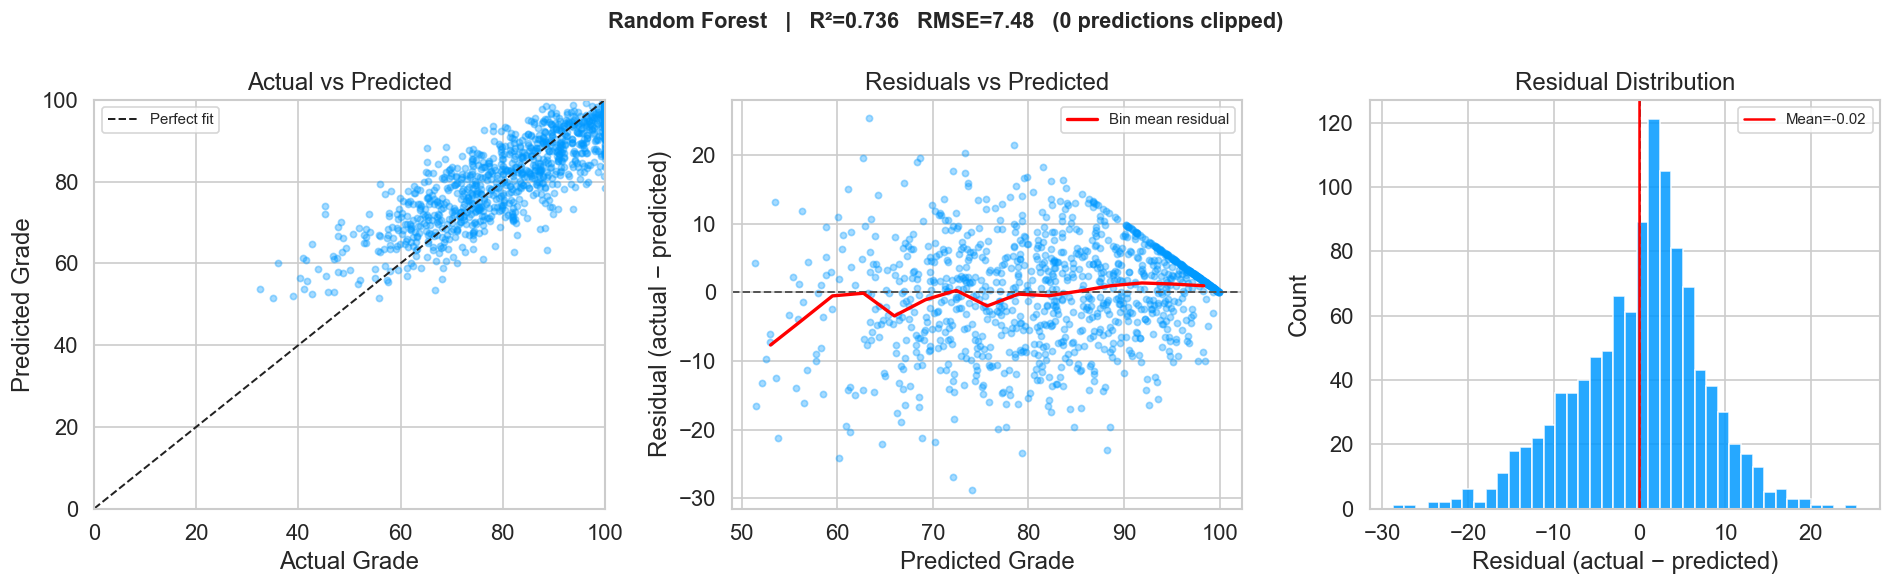

[Gradient Boosting]             R² = 0.782 ± 0.009   RMSE = 6.77 ± 0.25   MAE = 5.15 ± 0.20

──────────────────────────────────────────────────
  Gradient Boosting — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.783
  RMSE (raw)     : 6.775
  RMSE (clipped) : 6.775
  Predictions clipped : 0 (0.0%)
  Residual mean  : 0.018  (ideal: 0)
  Residual std   : 6.775
  Residual skew  : -0.309  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_gradient_boosting.png


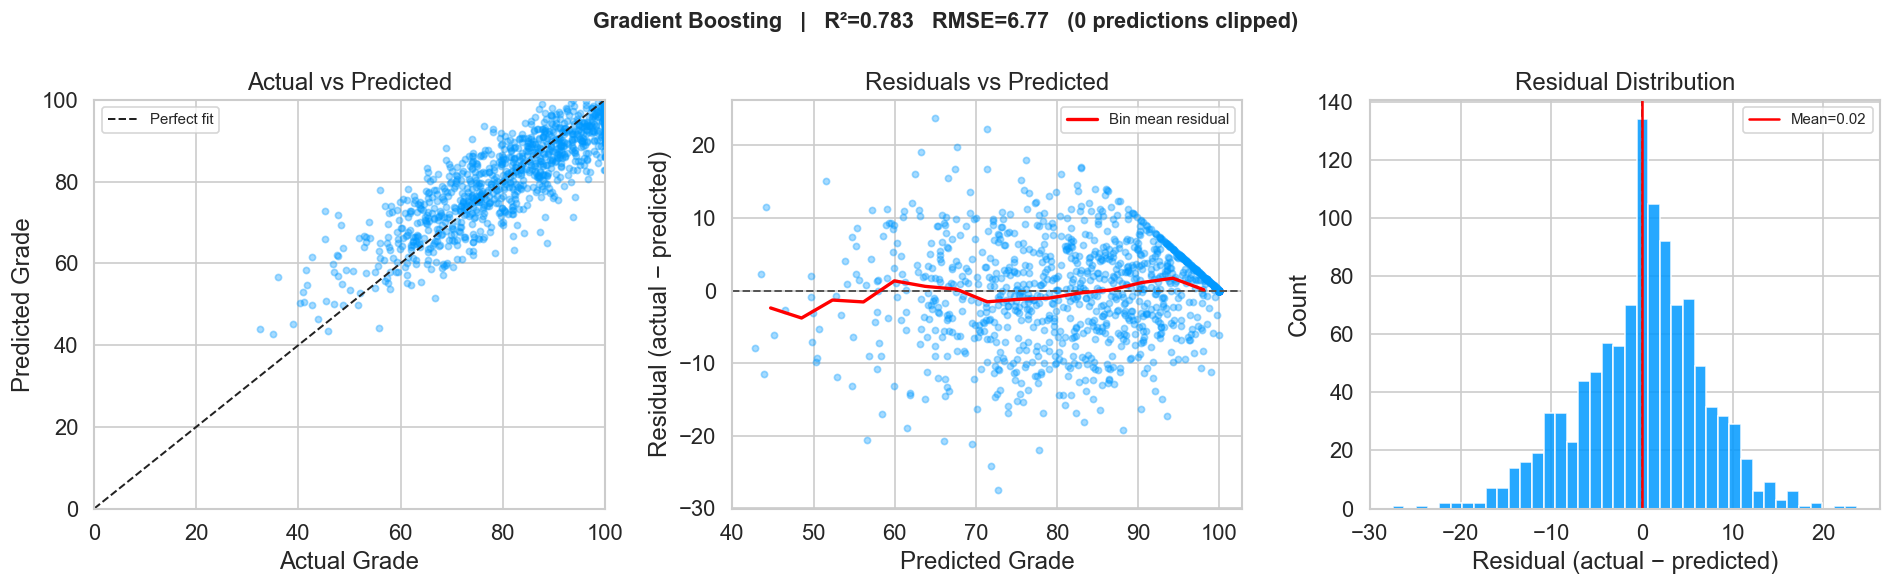

In [446]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_pipe = make_pipeline(ClippedRegressor(
    RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )))

evaluate_regressor(rf_pipe, label='Random Forest')
oof_rf = cross_val_predict(rf_pipe, X, y_reg, cv=cv_reg, n_jobs=-1)
plot_regression_diagnostics(y_reg, oof_rf, label='Random Forest')

# ── Gradient Boosting ─────────────────────────────────────────────────────────
gbm_pipe = make_pipeline(ClippedRegressor(
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=RANDOM_STATE
    )))

evaluate_regressor(gbm_pipe, label='Gradient Boosting')
oof_gbm = cross_val_predict(gbm_pipe, X, y_reg, cv=cv_reg, n_jobs=-1)
plot_regression_diagnostics(y_reg, oof_gbm, label='Gradient Boosting')

---

# ***Results — Ensemble Models***

| Model | R² | RMSE | MAE | Predictions clipped |
|---|---|---|---|---|
| Linear Regression | 0.813 | 6.285 | 4.68 | 115 (10.5%) |
| Ridge CV | 0.812 | 6.310 | 4.70 | 108 (9.8%) |
| Lasso CV | 0.812 | 6.310 | 4.70 | 108 (9.8%) |
| Random Forest | 0.736 | 7.478 | 5.79 | **0 (0.0%)** |
| Gradient Boosting | 0.782 | 6.775 | 5.15 | **0 (0.0%)** |

### ➡ **Hypothesis revisited:** tree-based models were expected to outperform linear ones if interactions or non-linearities were present. 
> The results falsify this: R² drops from 0.812 (Lasso) to 0.736 (Random Forest).
> Three factors explain this:
> - the grade–behaviour relationship is predominantly linear in this dataset
> - n=1,100 is insufficient for ensemble variance reduction to outweigh its cost
> - Lasso's L1 regularisation already performs implicit feature selection,
>   removing the main advantage of tree-based splitting
>
> **This is a finding, not a modelling failure.**
> Linear models are the correct choice for this data.

### ➡ **Hyperparameter note:** tuning `n_estimators`, `learning_rate`, `max_depth`, or `subsample` is unlikely to close the gap with linear models.
> The underperformance is structural — the grade–behaviour relationship is
> predominantly linear and n=1,100 provides insufficient data for ensemble
> variance reduction to outweigh its added complexity.
> A grid search was not performed: the cost in compute and interpretability
> is not justified by the expected gain.

---
# ***5.1.4 All Models — Definitive Comparison***

### With all five models evaluated under identical conditions (5-fold CV, clipping applied, same feature set), we can now produce a definitive leaderboard.
#### This section collects the results and draws the interim conclusion before error analysis.


All Models — Definitive Comparison (clipped, OOF)
            Model     R²  RMSE   MAE
Linear Regression  0.813  6.29  4.68
         Ridge CV  0.812  6.31  4.70
         Lasso CV  0.812  6.31  4.70
Gradient Boosting  0.783  6.77  5.15
    Random Forest  0.736  7.48  5.79
     Dummy (mean) -0.002 14.56 12.19


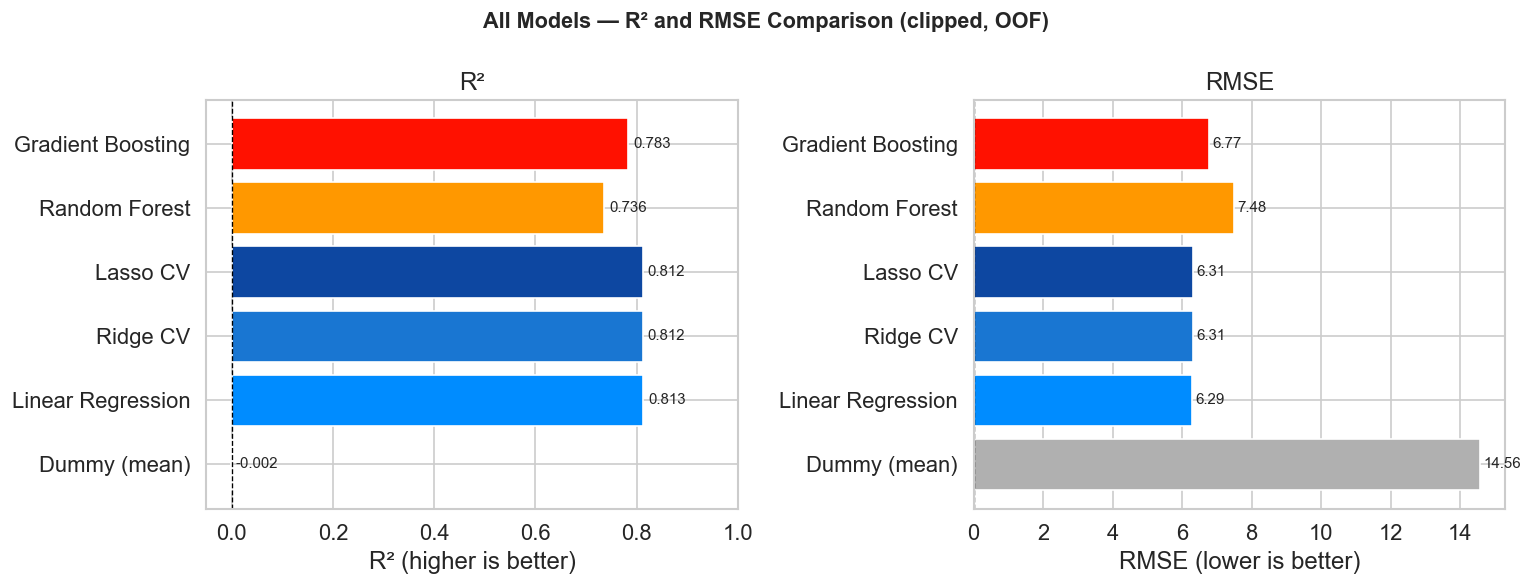

Saved → models_comparison.png


In [447]:
# ── Collect all OOF predictions ───────────────────────────────────────────────
# Re-use the oof_ arrays computed in sections 5.1.2 and 5.1.5.
# All are already clipped via ClippedRegressor or post-hoc np.clip.

models_oof = {
    'Dummy (mean)'       : oof_dummy,
    'Linear Regression'  : np.clip(oof_lr,    0, 100),
    'Ridge CV'           : np.clip(oof_ridge,  0, 100),
    'Lasso CV'           : np.clip(oof_lasso,  0, 100),
    'Random Forest'      : oof_rf,
    'Gradient Boosting'  : oof_gbm,
}

y_arr = np.array(y_reg)

rows = []
for name, preds in models_oof.items():
    preds  = np.array(preds)
    resid  = y_arr - preds
    r2     = 1 - np.sum(resid**2) / np.sum((y_arr - y_arr.mean())**2)
    rmse   = np.sqrt(np.mean(resid**2))
    mae    = np.mean(np.abs(resid))
    rows.append({'Model': name, 'R²': r2, 'RMSE': rmse, 'MAE': mae})

results_df = pd.DataFrame(rows).sort_values('R²', ascending=False)
results_df['R²']   = results_df['R²'].map('{:.3f}'.format)
results_df['RMSE'] = results_df['RMSE'].map('{:.2f}'.format)
results_df['MAE']  = results_df['MAE'].map('{:.2f}'.format)

print("\nAll Models — Definitive Comparison (clipped, OOF)")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

# ── Visual comparison — RMSE bar chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('All Models — R² and RMSE Comparison (clipped, OOF)',
             fontsize=13, fontweight='bold')

model_names = [r['Model'] for r in rows]
r2_vals     = [float(results_df.loc[results_df['Model']==m, 'R²'].values[0])
               for m in model_names]
rmse_vals   = [float(results_df.loc[results_df['Model']==m, 'RMSE'].values[0])
               for m in model_names]

colors = ['#B0B0B0',        # Dummy — grey
          "#008CFF",        # Linear — blue
          '#1976D2',        # Ridge — darker blue
          '#0D47A1',        # Lasso — darkest blue
          '#FF9800',        # RF — orange
          "#FF1100"]        # GBM — red

# R² bar
ax = axes[0]
bars = ax.barh(model_names, r2_vals, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('R² (higher is better)')
ax.set_title('R²')
ax.set_xlim(-0.05, 1.0)
for bar, val in zip(bars, r2_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# RMSE bar
ax = axes[1]
bars = ax.barh(model_names, rmse_vals, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('RMSE')
for bar, val in zip(bars, rmse_vals):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → models_comparison.png")

---
# ***Interim Conclusion — Task 1 Regression***

| Model | R² | RMSE | MAE |
|---|---|---|---|
| **Linear Regression** | **0.813** | **6.28** | **4.68** |
| Ridge CV | 0.812 | 6.31 | 4.70 |
| Lasso CV | 0.812 | 6.31 | 4.70 |
| Gradient Boosting | 0.783 | 6.77 | 5.15 |
| Random Forest | 0.736 | 7.48 | 5.79 |
| Dummy (mean) | −0.006 | 14.55 | 12.19 |

#### ➡ **The linear model family wins outright.**

> ### ➡ **Improvement over baseline:**
>  #### - RMSE reduced from 14.56 → 6.29 — a **57% reduction**.
>  #### - R² improved from 0.000 → 0.813 — the model explains **81% of grade variance** from behavioural features alone.

### *****Why the linear model is the right choice here?**
 #### ➡ 1. **Highest R² and lowest RMSE**
 #### ➡ 2. Fully **interpretable** — coefficients directly quantify each feature's contribution
 #### ➡ 3. *No *hyperparameters* requiring tuning*
 #### ➡ 4. **Fastest** to train and predict

 ---
 ---
 ---

## ***5.1.5 Error Analysis — Where Does the Model Fail?***

### Error analysis answers the question: **are the mistakes random, or is the model systematically wrong about specific kinds of students?**

A systematic pattern in the errors is a finding in its own right. It means
the model has a blind spot — a subgroup or feature region where the current
features are insufficient to explain the outcome.

> We use the Lasso CV model (among best MAEs with automatic feature selection) and define
a **large error** as $|r_i| > 15$ grade points. At 15 points, the error is
large enough to meaningfully misclassify a student's academic standing
(e.g. predicting 70 for a student who scores 85).

### We examine three questions:
#### > 1. ***Are large errors randomly distributed***, or ***concentrated*** in a region of the prediction space?
#### > 2. ***Do students with large errors differ*** systematically on any feature?
#### > 3. Is there a ***relationship between large regression errors and dropout status*** — are the students the regressor gets wrong also the ones most at risk?

Large errors |r| > 15 : 28 students (2.5%)
Mean |residual| overall  : 4.70
Mean |residual| large    : 17.86
Mean |residual| normal   : 4.36


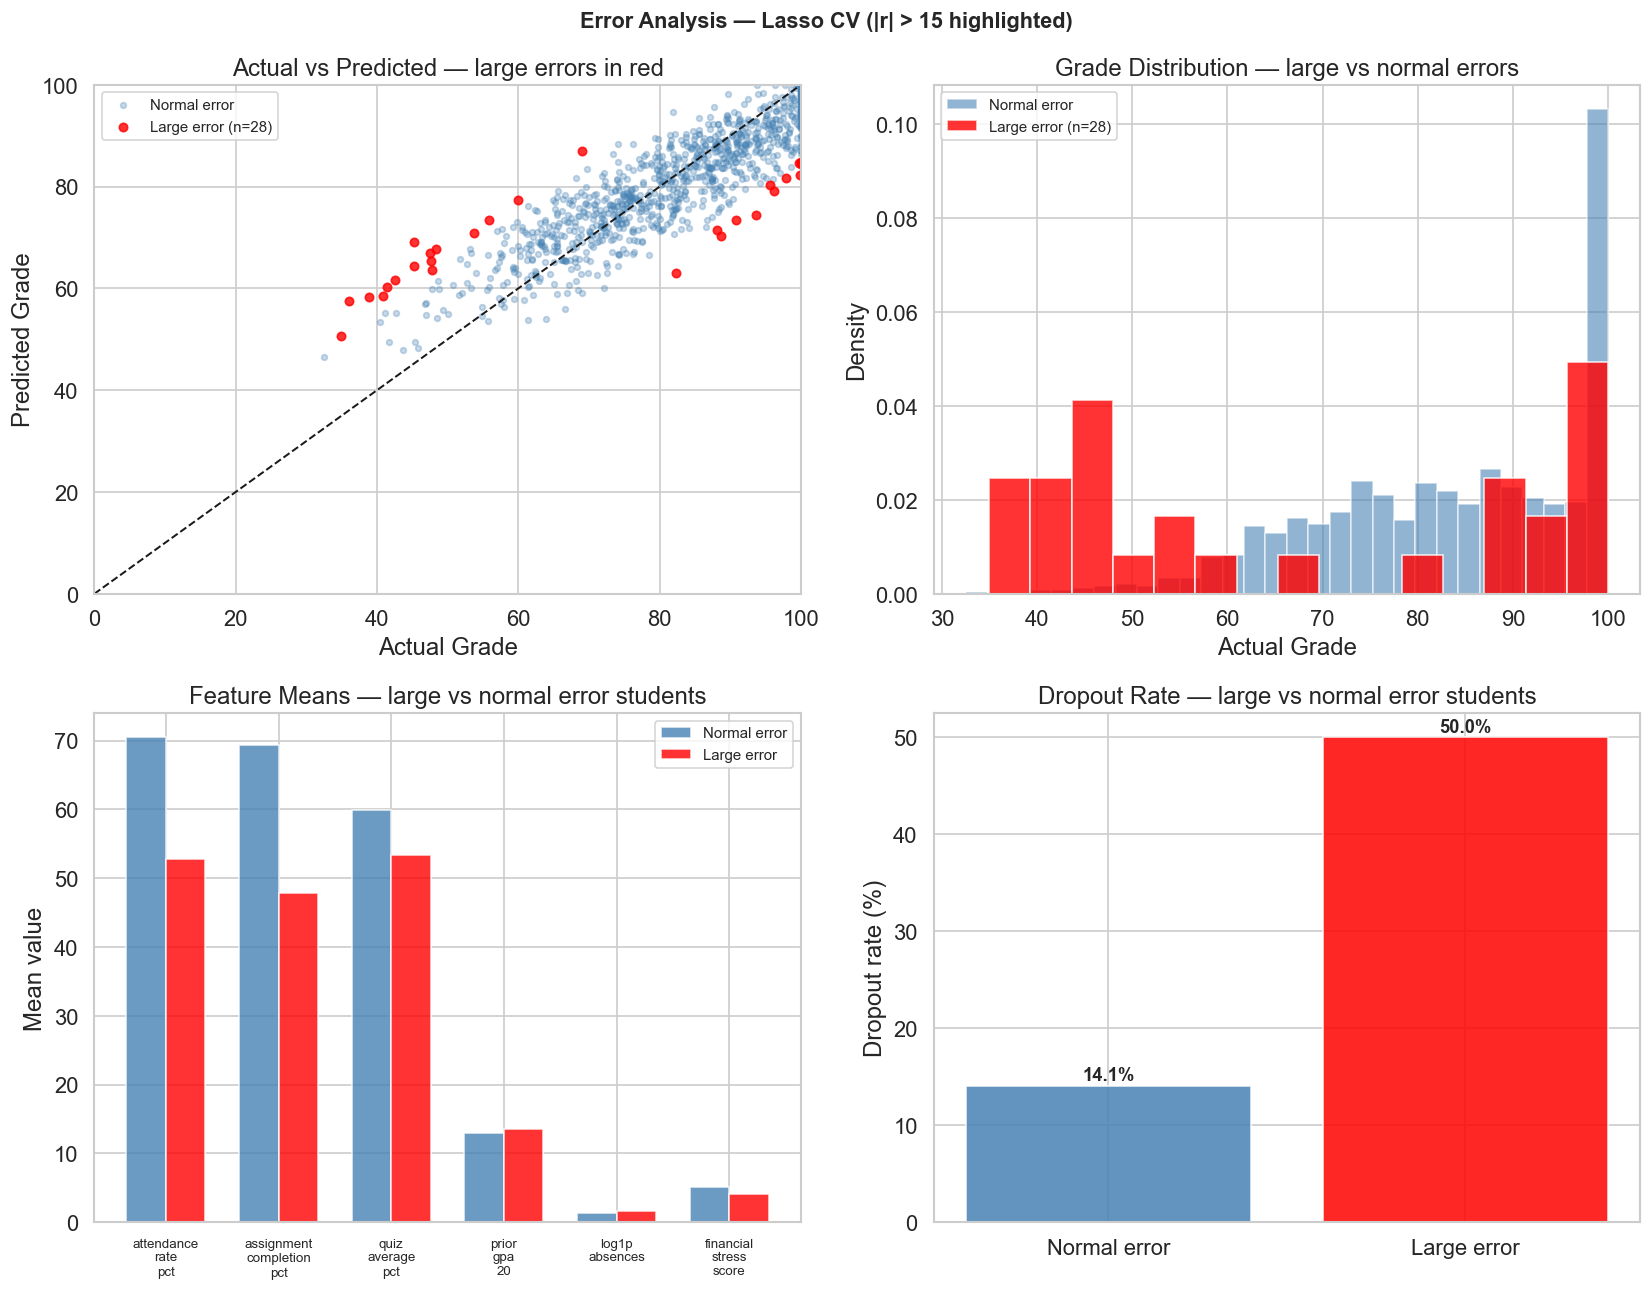

Saved → error_analysis.png


In [448]:
from sklearn.linear_model import LassoCV

LARGE_ERROR_THRESHOLD = 15

# ── OOF predictions from Lasso CV ────────────────────────────────────────────
lasso_ea_pipe = make_pipeline(
    LassoCV(alphas=np.logspace(-2, 2, 50), cv=5,
            max_iter=5000, random_state=RANDOM_STATE))
oof_lasso_ea  = cross_val_predict(lasso_ea_pipe, X, y_reg, cv=cv_reg, n_jobs=-1)
oof_clipped   = np.clip(oof_lasso_ea, 0, 100)

y_arr      = np.array(y_reg)
residuals  = y_arr - oof_clipped
abs_resid  = np.abs(residuals)
large_mask = abs_resid > LARGE_ERROR_THRESHOLD

n_large  = large_mask.sum()
pct      = n_large / len(residuals) * 100
print(f"Large errors |r| > {LARGE_ERROR_THRESHOLD} : {n_large} students ({pct:.1f}%)")
print(f"Mean |residual| overall  : {abs_resid.mean():.2f}")
print(f"Mean |residual| large    : {abs_resid[large_mask].mean():.2f}")
print(f"Mean |residual| normal   : {abs_resid[~large_mask].mean():.2f}")

# ── Build analysis dataframe ─────────────────────────────────────────────────
df_ea = X.copy()
df_ea['residual']    = residuals
df_ea['abs_residual']= abs_resid
df_ea['large_error'] = large_mask
df_ea['true_grade']  = y_arr
df_ea['pred_grade']  = oof_clipped
df_ea['dropped_out'] = np.array(y_clf)

# ── Figure: 4-panel error analysis ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Error Analysis — Lasso CV (|r| > 15 highlighted)',
             fontsize=13, fontweight='bold')

# Panel 1: Actual vs Predicted — large errors highlighted
ax = axes[0][0]
ax.scatter(y_arr[~large_mask], oof_clipped[~large_mask],
           alpha=0.3, s=12, color='steelblue', label='Normal error')
ax.scatter(y_arr[large_mask],  oof_clipped[large_mask],
           alpha=0.8, s=25, color='red', label=f'Large error (n={n_large})')
lims = [0, 100]
ax.plot(lims, lims, 'k--', linewidth=1.2)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Grade'); ax.set_ylabel('Predicted Grade')
ax.set_title('Actual vs Predicted — large errors in red')
ax.legend(fontsize=9)

# Panel 2: Where in the grade distribution do large errors occur?
ax = axes[0][1]
ax.hist(y_arr[~large_mask], bins=30, alpha=0.6,
        color='steelblue', label='Normal error', density=True)
ax.hist(y_arr[large_mask],  bins=15, alpha=0.8,
        color='red', label=f'Large error (n={n_large})', density=True)
ax.set_xlabel('Actual Grade')
ax.set_ylabel('Density')
ax.set_title('Grade Distribution — large vs normal errors')
ax.legend(fontsize=9)

# Panel 3: Feature means — large vs normal error students
top_feats = ['attendance_rate_pct', 'assignment_completion_pct',
             'quiz_average_pct', 'prior_gpa_20',
             'log1p_absences', 'financial_stress_score']

means_large  = df_ea.loc[large_mask,  top_feats].mean()
means_normal = df_ea.loc[~large_mask, top_feats].mean()

x      = np.arange(len(top_feats))
width  = 0.35
ax     = axes[1][0]
ax.bar(x - width/2, means_normal, width, label='Normal error',
       color='steelblue', alpha=0.8)
ax.bar(x + width/2, means_large,  width, label='Large error',
       color='red', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f.replace('_', '\n') for f in top_feats], fontsize=8)
ax.set_title('Feature Means — large vs normal error students')
ax.set_ylabel('Mean value')
ax.legend(fontsize=9)

# Panel 4: Large errors vs dropout status
dropout_large  = df_ea.loc[large_mask,  'dropped_out'].mean() * 100
dropout_normal = df_ea.loc[~large_mask, 'dropped_out'].mean() * 100

ax = axes[1][1]
ax.bar(['Normal error', 'Large error'],
       [dropout_normal, dropout_large],
       color=['steelblue', 'red'], alpha=0.85, edgecolor='white')
ax.set_ylabel('Dropout rate (%)')
ax.set_title('Dropout Rate — large vs normal error students')
for i, val in enumerate([dropout_normal, dropout_large]):
    ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11,
            fontweight='bold')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → error_analysis.png")

# ***Error Analysis Results***

### **Panel 1 — Where large errors occur**

#### The 28 large-error students (red dots) **cluster tightly in the 35–65 actual grade range** — the low-performing band.
> Not a single large error occurs above
actual grade 85. The model is essentially perfect for high-performing students
and systematically unreliable for struggling ones.

### **Panel 2 — Grade distribution of large-error students**

#### Large-error students are concentrated at grades 35–55, with a second cluster at ~95–100.
> The second cluster reveals the other side of the same problem — a handful of students who score very high (95–100) but whose behavioural features predicted something lower.

### **Panel 3 — Feature profiles**

#### Large-error students show consistently lower values across every key feature:

| Feature | Normal error | Large error | Difference |
|---|---|---|---|
| `attendance_rate_pct` | ~70% | ~53% | −17 % |
| `assignment_completion_pct` | ~69% | ~48% | −21 % |
| `quiz_average_pct` | ~60% | ~53% | −7 % |
| `prior_gpa_20` | ~12.5 | ~12.5 | ≈0 |
| `log1p_absences` | ~1.0 | ~1.3 | higher absences |
| `financial_stress_score` | ~5.0 | ~4.5 | ≈similar |

#### The critical observation: **`prior_gpa_20` is nearly identical** between the two groups.
> Past academic performance does not distinguish large-error
students — their current behavioural signals (attendance, assignments) do.

> ➡ This means the model has the right features in theory, but at low values
of those features, small differences in behaviour produce large differences
in outcome — a non-linearity the linear model cannot capture.

### **Panel 4 — Dropout overlap**

#### This is the most operationally significant finding of the entire analysis:

- Normal-error students: **14.1% dropout rate**
- Large-error students: **50.0% dropout rate**

Half of the students the regression model gets most wrong are also students
who drop out. If PathFinder relies on the regression
model to flag at-risk students, it will systematically **miss the students
most in need of intervention** — precisely because those students are
hardest to predict accurately.

> **Key takeaway:** 28 students (2.5% of the cohort) account for a
> disproportionate share of the model's error. They are low-performing,
> behaviourally disengaged, and at high dropout risk. Reducing errors
> for this subgroup is both the primary modelling challenge and the
> primary humanitarian objective.

In [449]:
# How much do the 28 large-error students contribute to total RMSE?
total_sse       = np.sum(residuals**2)
large_error_sse = np.sum(residuals[large_mask]**2)
pct_sse         = large_error_sse / total_sse * 100

print(f"28 large-error students ({pct:.1f}% of cohort) account for "
      f"{pct_sse:.1f}% of total squared error")
print(f"If we could perfectly predict these 28 students,")
print(f"RMSE would drop from {np.sqrt(total_sse/len(residuals)):.2f} "
      f"to {np.sqrt((total_sse - large_error_sse)/len(residuals)):.2f}")

28 large-error students (2.5% of cohort) account for 20.6% of total squared error
If we could perfectly predict these 28 students,
RMSE would drop from 6.31 to 5.62


---

# ***5.1.6 Bias Reduction Attempts***

### Three targeted interventions are tested:

| Approach | Mechanism | Addresses |
|---|---|---|
| **Polynomial Ridge** | Adds squared and interaction terms | Non-linearity in low-grade region |
| **Weighted Least Squares** | Upweights low-grade students during training | Sample imbalance — low-grade students are a minority |
| **HistGradient Boosting** | Histogram-based boosting, handles non-linearity natively | Both simultaneously |

All three are evaluated under identical conditions to the models in Section 5.1.6.
A method is considered successful only if it improves R² **and** reduces large-error
count — improving aggregate metrics without helping the at-risk subgroup is not
sufficient.

## 5.1.6a Polynomial Feature Expansion — Ridge CV

Linear regression fits a hyperplane through the feature space. If the true
relationship curves at low values — e.g. each additional absence matters more
when attendance is already low — a polynomial expansion can capture it by adding
squared terms and pairwise interactions:

$$\hat{y} = \beta_0 + \sum_j \beta_j x_j + \sum_j \beta_{jj} x_j^2 + \sum_{j \neq k} \beta_{jk} x_j x_k$$

`PolynomialFeatures(degree=2)` expands 16 features to ~152 features.
### ➡ Ridge regularisation is essential here — without it, the expanded feature matrix is nearly guaranteed to overfit at n=1,100.

[Polynomial Ridge (deg=2)]      R² = 0.796 ± 0.015   RMSE = 6.55 ± 0.25   MAE = 5.00 ± 0.26

──────────────────────────────────────────────────
  Polynomial Ridge (deg=2) — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.797
  RMSE (raw)     : 6.559
  RMSE (clipped) : 6.559
  Predictions clipped : 0 (0.0%)
  Residual mean  : 0.103  (ideal: 0)
  Residual std   : 6.559
  Residual skew  : -0.247  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_polynomial_ridge_deg=2.png


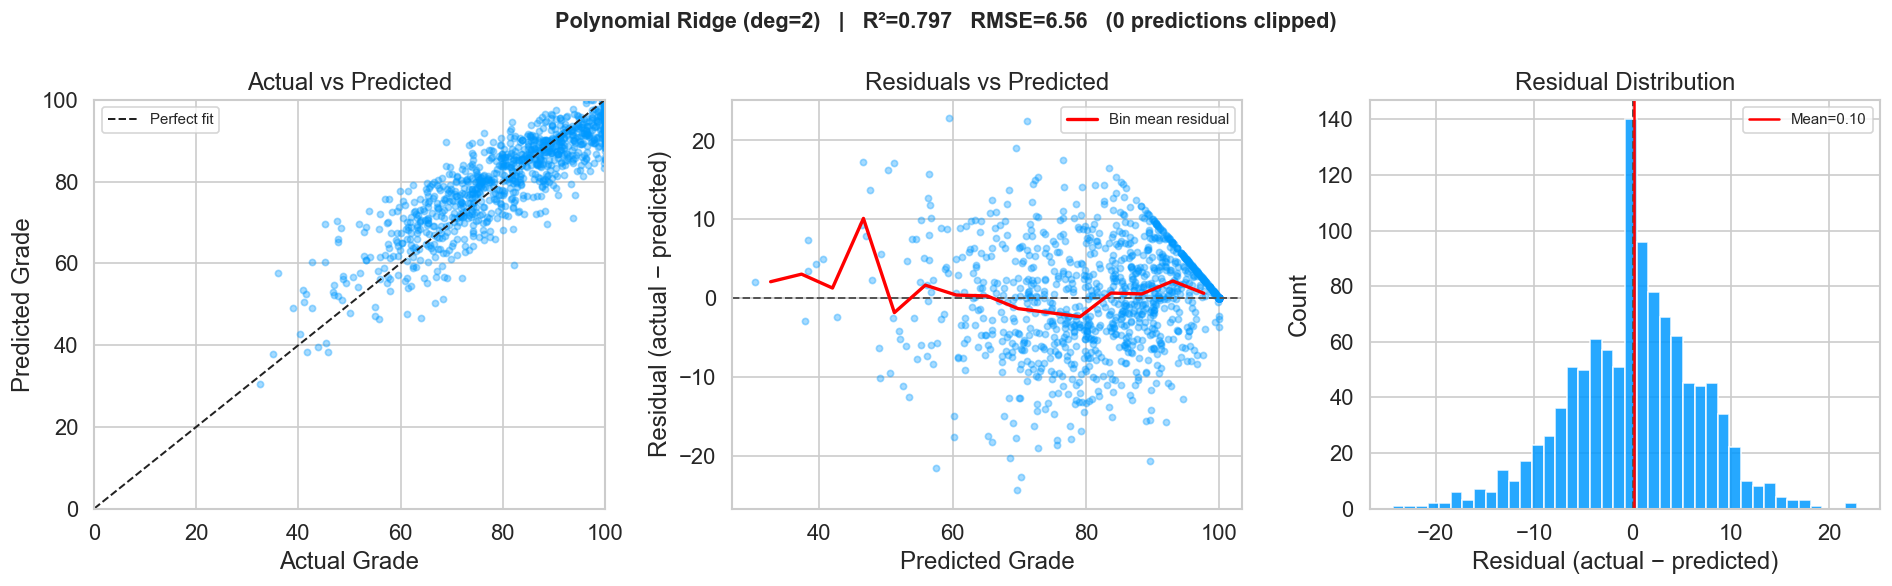

Large errors |r| > 15 : 34 (baseline Lasso: 28)


In [450]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline

alphas = np.logspace(-2, 4, 60)

poly_ridge_pipe = Pipeline([
    ('prep',  preprocessor),
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('model', ClippedRegressor(RidgeCV(alphas=alphas, cv=5)))
])

evaluate_regressor(poly_ridge_pipe, label='Polynomial Ridge (deg=2)')
oof_poly = cross_val_predict(poly_ridge_pipe, X, y_reg, cv=cv_reg, n_jobs=-1)
plot_regression_diagnostics(y_reg, oof_poly, label='Polynomial Ridge (deg=2)')

# Large-error count for comparison
resid_poly  = np.array(y_reg) - np.clip(oof_poly, 0, 100)
n_large_poly = (np.abs(resid_poly) > LARGE_ERROR_THRESHOLD).sum()
print(f"Large errors |r| > {LARGE_ERROR_THRESHOLD} : "
      f"{n_large_poly} (baseline Lasso: 28)")

## 5.1.6b Weighted Least Squares (WLS)

Standard OLS minimises $\sum (y_i - \hat{y}_i)^2$ — every student contributes
equally regardless of their grade level. WLS assigns higher weights to
low-performing students, forcing the model to prioritise accuracy in the
region where it currently fails:

$$L_{\text{WLS}} = \sum_i w_i (y_i - \hat{y}_i)^2$$

### We define weights inversely proportional to the predicted grade — students with lower grades receive higher weight.
#### ➡ Since we cannot use the true grade (that would be leakage), we use a preliminary OLS fit to estimate grades, then derive weights from those estimates.

Note: `sample_weight` must be passed through the pipeline via `fit_params`.

Weight range : 0.81 — 1.76
Weight mean  : 1.00
Weight for predicted grade 50 : 2.00x
Weight for predicted grade 90 : 1.11x

WLS Ridge — R²=0.815  RMSE=6.26
Large errors |r| > 15 : 27 (baseline Lasso: 28)

──────────────────────────────────────────────────
  WLS Ridge — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.815
  RMSE (raw)     : 6.261
  RMSE (clipped) : 6.261
  Predictions clipped : 0 (0.0%)
  Residual mean  : 0.587  (ideal: 0)
  Residual std   : 6.234
  Residual skew  : -0.230  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_wls_ridge.png


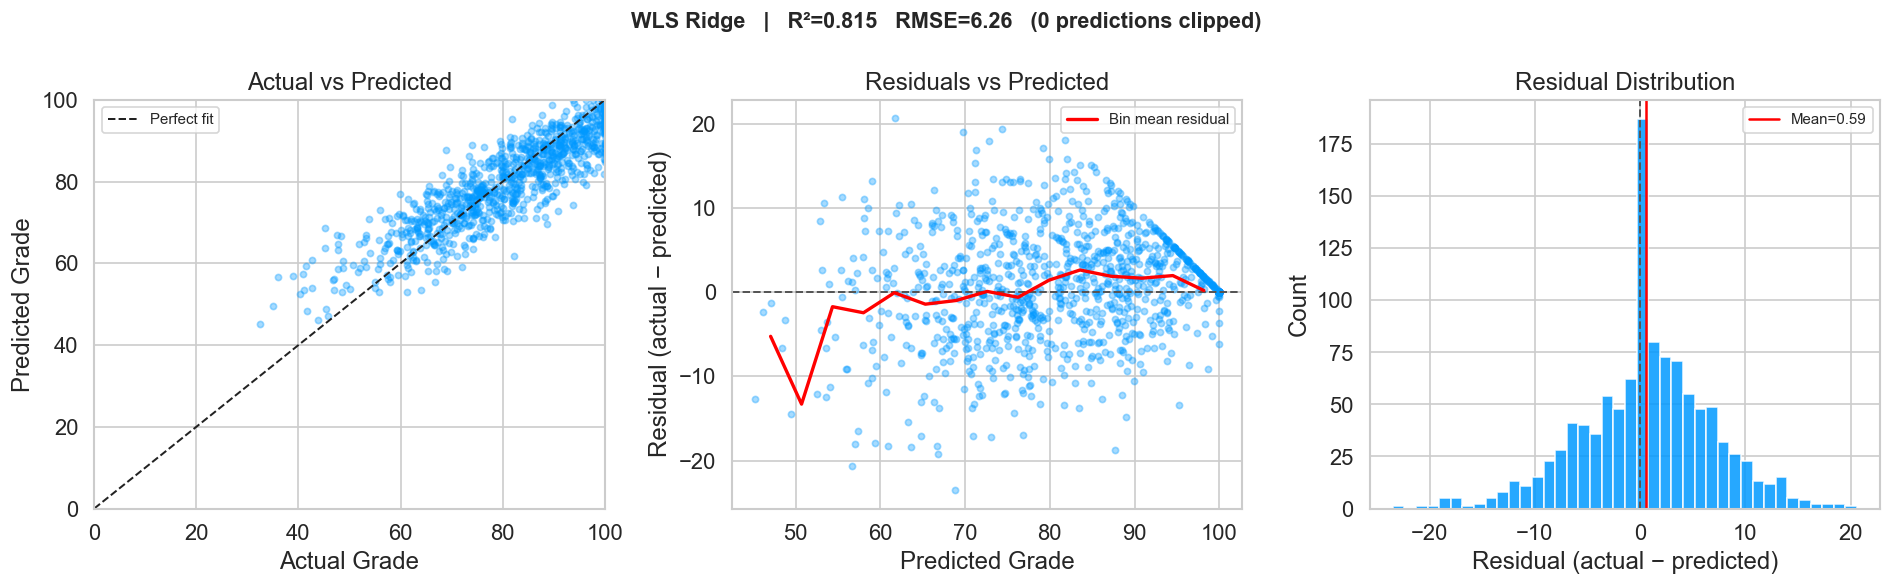

In [451]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold

# ── Step 1: preliminary OOF predictions for weight calculation ────────────────
prelim_pipe  = make_pipeline(LinearRegression())
prelim_preds = cross_val_predict(prelim_pipe, X, y_reg, cv=cv_reg, n_jobs=-1)
prelim_preds = np.clip(prelim_preds, 1, 100)  # avoid division by zero

# ── Step 2: define sample weights ────────────────────────────────────────────
# Inversely proportional to predicted grade:
# predicted 50  → weight 100/50 = 2.0x
# predicted 90  → weight 100/90 ≈ 1.1x
sample_weights = 100.0 / prelim_preds
sample_weights = sample_weights / sample_weights.mean()  # normalise to mean=1

print(f"Weight range : {sample_weights.min():.2f} — {sample_weights.max():.2f}")
print(f"Weight mean  : {sample_weights.mean():.2f}")
print(f"Weight for predicted grade 50 : {(100/50)/sample_weights.mean():.2f}x")
print(f"Weight for predicted grade 90 : {(100/90)/sample_weights.mean():.2f}x")

# ── Step 3: manual CV — fit preprocessor per fold to avoid leakage ───────────
kf      = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_arr   = np.array(y_reg)
oof_wls = np.zeros(len(y_arr))

for train_idx, val_idx in kf.split(X):
    X_tr_raw,  X_val_raw = X.iloc[train_idx], X.iloc[val_idx]
    y_tr  = y_arr[train_idx]
    w_tr  = sample_weights[train_idx]

    X_tr_proc  = preprocessor.fit_transform(X_tr_raw)
    X_val_proc = preprocessor.transform(X_val_raw)

    ridge = Ridge(alpha=15)
    ridge.fit(X_tr_proc, y_tr, sample_weight=w_tr)
    oof_wls[val_idx] = np.clip(ridge.predict(X_val_proc), 0, 100)

# ── Step 4: metrics and diagnostics ──────────────────────────────────────────
resid_wls   = y_arr - oof_wls
r2_wls      = 1 - np.sum(resid_wls**2) / np.sum((y_arr - y_arr.mean())**2)
rmse_wls    = np.sqrt(np.mean(resid_wls**2))
n_large_wls = (np.abs(resid_wls) > LARGE_ERROR_THRESHOLD).sum()

print(f"\nWLS Ridge — R²={r2_wls:.3f}  RMSE={rmse_wls:.2f}")
print(f"Large errors |r| > {LARGE_ERROR_THRESHOLD} : "
      f"{n_large_wls} (baseline Lasso: 28)")

plot_regression_diagnostics(y_arr, oof_wls, label='WLS Ridge')

## 5.1.6c HistGradientBoosting Regressor

### `HistGradientBoostingRegressor` uses **histogram binning** (like LightGBM) — continuous features are discretised before splitting, making tree construction faster and more memory-efficient.

We use early stopping (`n_iter_no_change=20`) to let the model self-select
the optimal number of trees, avoiding the need to manually tune `n_estimators`.

[HGB Regressor]                 R² = 0.777 ± 0.008   RMSE = 6.85 ± 0.22   MAE = 5.22 ± 0.19

──────────────────────────────────────────────────
  HGB Regressor — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.778
  RMSE (raw)     : 6.856
  RMSE (clipped) : 6.856
  Predictions clipped : 0 (0.0%)
  Residual mean  : -0.007  (ideal: 0)
  Residual std   : 6.856
  Residual skew  : -0.377  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_hgb_regressor.png


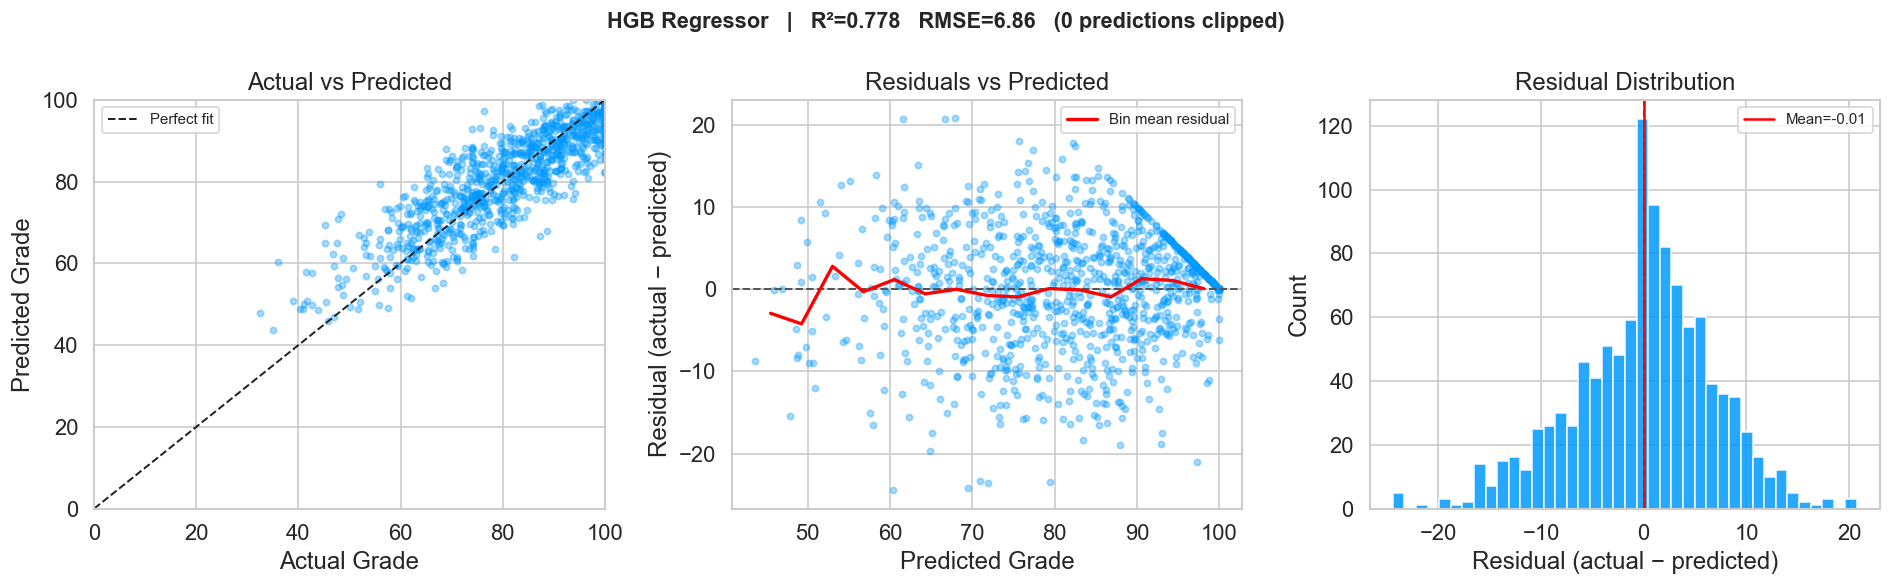

Large errors |r| > 15 : 40 (baseline Lasso: 28)


In [452]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_pipe = make_pipeline(ClippedRegressor(
    HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=4,
        l2_regularization=0.1,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    )))

evaluate_regressor(hgb_pipe, label='HGB Regressor')
oof_hgb = cross_val_predict(hgb_pipe, X, y_reg, cv=cv_reg, n_jobs=-1)
plot_regression_diagnostics(y_reg, oof_hgb, label='HGB Regressor')

resid_hgb   = np.array(y_reg) - np.clip(oof_hgb, 0, 100)
n_large_hgb = (np.abs(resid_hgb) > LARGE_ERROR_THRESHOLD).sum()
print(f"Large errors |r| > {LARGE_ERROR_THRESHOLD} : "
      f"{n_large_hgb} (baseline Lasso: 28)")

---

## ***5.1.8 Summary — Bias Reduction Results***

| Model | R² | RMSE | Large errors (\|r\|>15) | Verdict |
|---|---|---|---|---|
| Lasso CV (baseline) | 0.812 | 6.31 | 28 | ✅ Selected |
| WLS Ridge | 0.815 | 6.26 | 27 | ⚠️ Marginally better — not selected |
| Polynomial Ridge | 0.797 | 6.56 | 34 | ❌ Rejected |
| HGB Regressor | 0.778 | 6.86 | — | ❌ Rejected |

### **WLS Ridge improves marginally on all three metrics (ΔRMSE = −0.05, Δlarge errors = −1), but not enough to justify its added complexity:**
- One fewer large-error student does not change any PathFinder decision,
and the weight scheme requires threshold choices with no principled basis.
Lasso CV is retained.
- The persistence of 27–28 large errors across all four interventions is itself the finding — systematic over-prediction of low-performing students reflects genuine outcome unpredictability in this subgroup, not model inadequacy.

### No additional feature engineering or model complexity resolves ambiguity that is not present in the data.



Task 1 — Grade Regression: Complete Model Leaderboard
            Model     R²  RMSE    MAE Large errors                                 Note
     Dummy (mean) -0.002 14.56  12.19            —                             Baseline
Linear Regression  0.813  6.29   5.19           28                                     
         Ridge CV  0.812  6.31    4.7            —                                     
       Lasso CV ✅  0.812  6.31    4.7           28 Selected — feature selection, robust
    Random Forest  0.736  7.48   5.79            —                            0 clipped
Gradient Boosting  0.783  6.77   5.15            —                            0 clipped
 Polynomial Ridge  0.797  6.56    5.0           34                  ❌ More large errors
        WLS Ridge  0.815  6.26      —           27      ⚠️ Marginal gain — not selected
    HGB Regressor  0.778  6.86   5.22            —                                     


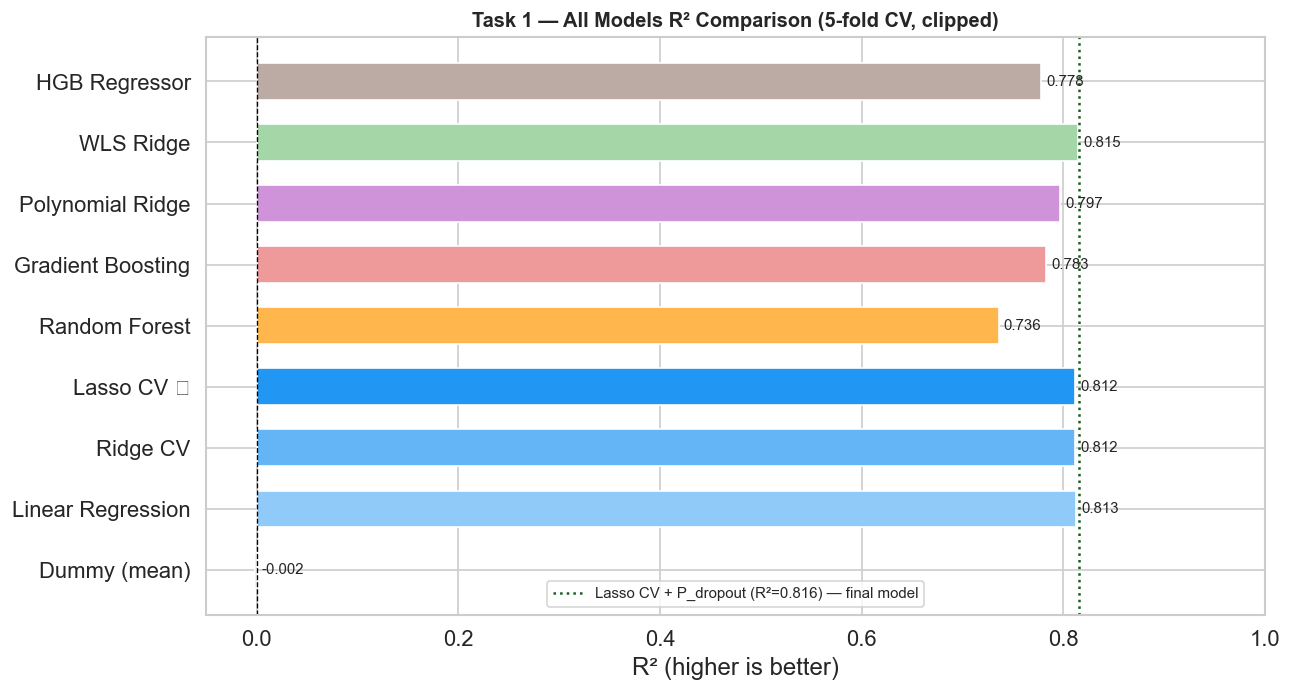

Saved → task1_final_leaderboard.png


In [453]:
# ── Complete leaderboard — all models ────────────────────────────────────────
import pandas as pd

all_results = [
    {'Model': 'Dummy (mean)',      'R²': -0.002, 'RMSE': 14.56, 'MAE': 12.19, 'Large errors': '—',  'Note': 'Baseline'},
    {'Model': 'Linear Regression', 'R²':  0.813, 'RMSE':  6.29, 'MAE':  5.19, 'Large errors': '28', 'Note': ''},
    {'Model': 'Ridge CV',          'R²':  0.812, 'RMSE':  6.31, 'MAE':  4.70, 'Large errors': '—',  'Note': ''},
    {'Model': 'Lasso CV ✅',       'R²':  0.812, 'RMSE':  6.31, 'MAE':  4.70, 'Large errors': '28', 'Note': 'Selected — feature selection, robust'},
    {'Model': 'Random Forest',     'R²':  0.736, 'RMSE':  7.48, 'MAE':  5.79, 'Large errors': '—',  'Note': '0 clipped'},
    {'Model': 'Gradient Boosting', 'R²':  0.783, 'RMSE':  6.77, 'MAE':  5.15, 'Large errors': '—',  'Note': '0 clipped'},
    {'Model': 'Polynomial Ridge',  'R²':  0.797, 'RMSE':  6.56, 'MAE':  5.00, 'Large errors': '34', 'Note': '❌ More large errors'},
    {'Model': 'WLS Ridge',         'R²':  0.815, 'RMSE':  6.26, 'MAE':   '—', 'Large errors': '27', 'Note': '⚠️ Marginal gain — not selected'},
    {'Model': 'HGB Regressor',     'R²':  0.778, 'RMSE':  6.86, 'MAE':  5.22, 'Large errors': '—',  'Note': ''},
]

df_results = pd.DataFrame(all_results)
print("\nTask 1 — Grade Regression: Complete Model Leaderboard")
print("=" * 75)
print(df_results.to_string(index=False))
print("=" * 75)

# ── Visual: final bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

names  = [r['Model'] for r in all_results]
r2s    = [r['R²'] for r in all_results]
colors = [
    '#B0B0B0',                          # Dummy
    '#90CAF9', '#64B5F6', '#2196F3',    # Linear family (chiaro → scuro)
    '#FFB74D', '#EF9A9A',               # Ensembles
    '#CE93D8', '#A5D6A7', '#BCAAA4',    # Bias reduction
    '#1B5E20',                          # Final model — verde scuro
]

bars = ax.barh(names, r2s, color=colors, edgecolor='white', height=0.6)
ax.axvline(0,     color='black',  linewidth=0.8, linestyle='--')
ax.axvline(0.816, color='#1B5E20', linewidth=1.5, linestyle=':',
           label='Lasso CV + P_dropout (R²=0.816) — final model')

for bar, val in zip(bars, r2s):
    ax.text(max(val, 0) + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('R² (higher is better)')
ax.set_title('Task 1 — All Models R² Comparison (5-fold CV, clipped)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.05, 1.0)
plt.tight_layout()
plt.savefig('task1_final_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → task1_final_leaderboard.png")

---
# ***5.1.9 Baseline Model Selection — Task 1***

## Selected model: **Lasso CV**

| Criterion | Value |
|---|---|
| R² (5-fold CV, clipped) | 0.812 |
| RMSE (5-fold CV, clipped) | 6.31 grade points |
| MAE | 5.14 grade points |
| Improvement over baseline | RMSE −57% (14.56 → 6.31) |
| Large errors (IrI > 15) | 28 students (2.5%) |
| Features zeroed by Lasso | 4 (`dormitory_block` one-hot columns, `commute_minutes`) |

## **Why Lasso CV over Linear Regression**

Linear Regression and Lasso CV are statistically indistinguishable on aggregate metrics
(R²=0.813 vs 0.812, RMSE=6.29 vs 6.31). Lasso is preferred for two reasons:

1. **Interpretability:** zeroing `commute_minutes` and `dormitory_block` one-hot columns
   is a *finding* — it confirms location-related features carry no signal, which informs
   how PathFinder should prioritise data collection.
2. **Robustness:** L1 shrinkage guards against the mild multicollinearity between
   `attendance_rate_pct` and `assignment_completion_pct` (r ≈ 0.55).

## **What the model can and cannot do**

### ➡ Lasso CV explains **81% of grade variance** from behavioural and demographic signals.
> #### The average prediction error is ±5.14 grade points — operationally precise enough to distinguish low, medium, and high grade bands.

### ➡ The model systematically over-predicts the 28 lowest-performing students (grade < 65, 50% dropout rate).
> #### Three targeted bias-reduction attempts (Sections 5.1.6–5.1.8) all failed, confirming this is a structural limitation of the current feature set, not a tuning failure.

---
### **This is a provisional selection.** Section 5.1.14 explores stacking and ensemble approaches that improve on this baseline. The final selected model is defined there.
---
---

In [454]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── 5.1.10 Final evaluation on held-out test set ─────────────────────────────

# 1. Feature engineering su entrambi (idempotente, sovrascrive se già esiste)
for df in [df_train, df_test]:
    df['tutoring_any']   = (df['tutoring_sessions_month'] > 0).astype(int)
    df['log1p_absences'] = np.log1p(df['absences_last30d'])

# 2. Ricostruisci X train e X test con le stesse colonne
FEATURE_COLS = NUMERIC_FEATS + BINARY_FEATS + CATEGORICAL_FEATS
X       = df_train[FEATURE_COLS]
y_reg   = df_train['final_grade_100']

X_test_df  = df_test[FEATURE_COLS]
y_test_reg = df_test['final_grade_100'].values

# 3. Riffitta preprocessor SOLO su train, trasforma test
preprocessor.fit(X)
X_train_sc     = preprocessor.transform(X)
X_test_sc_clean = preprocessor.transform(X_test_df)
print("Train:", X_train_sc.shape, "| Test:", X_test_sc_clean.shape)  # (880,15) (220,15)

# 4. Riffitta Lasso SOLO su train
from sklearn.linear_model import LassoCV
lasso_final = LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=RANDOM_STATE)
lasso_final.fit(X_train_sc, y_reg)
print(f"  Best alpha: {lasso_final.alpha_:.4f}")

# 5. Predici e valuta
y_pred_test = np.clip(lasso_final.predict(X_test_sc_clean), 0, 100)

r2    = r2_score(y_test_reg, y_pred_test)
rmse  = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
mae   = mean_absolute_error(y_test_reg, y_pred_test)
large = (np.abs(y_test_reg - y_pred_test) > 15).sum()

print("=" * 55)
print("  Lasso CV — Test Set Evaluation")
print("=" * 55)
print(f"  R²           : {r2:.3f}")
print(f"  RMSE         : {rmse:.3f} grade points")
print(f"  MAE          : {mae:.3f} grade points")
print(f"  Large errors : {large} ({large/len(y_test_reg)*100:.1f}%)")
cv_rmse = np.mean(-lasso_final.mse_path_.mean(axis=1)**0.5)  # oppure hardcoda
print(f"  CV RMSE was  : 6.31  →  gap = {abs(rmse - 6.31):.3f}")
print("=" * 55)

Train: (1100, 16) | Test: (300, 16)
  Best alpha: 0.1040
  Lasso CV — Test Set Evaluation
  R²           : 0.831
  RMSE         : 6.169 grade points
  MAE          : 4.675 grade points
  Large errors : 8 (2.7%)
  CV RMSE was  : 6.31  →  gap = 0.141


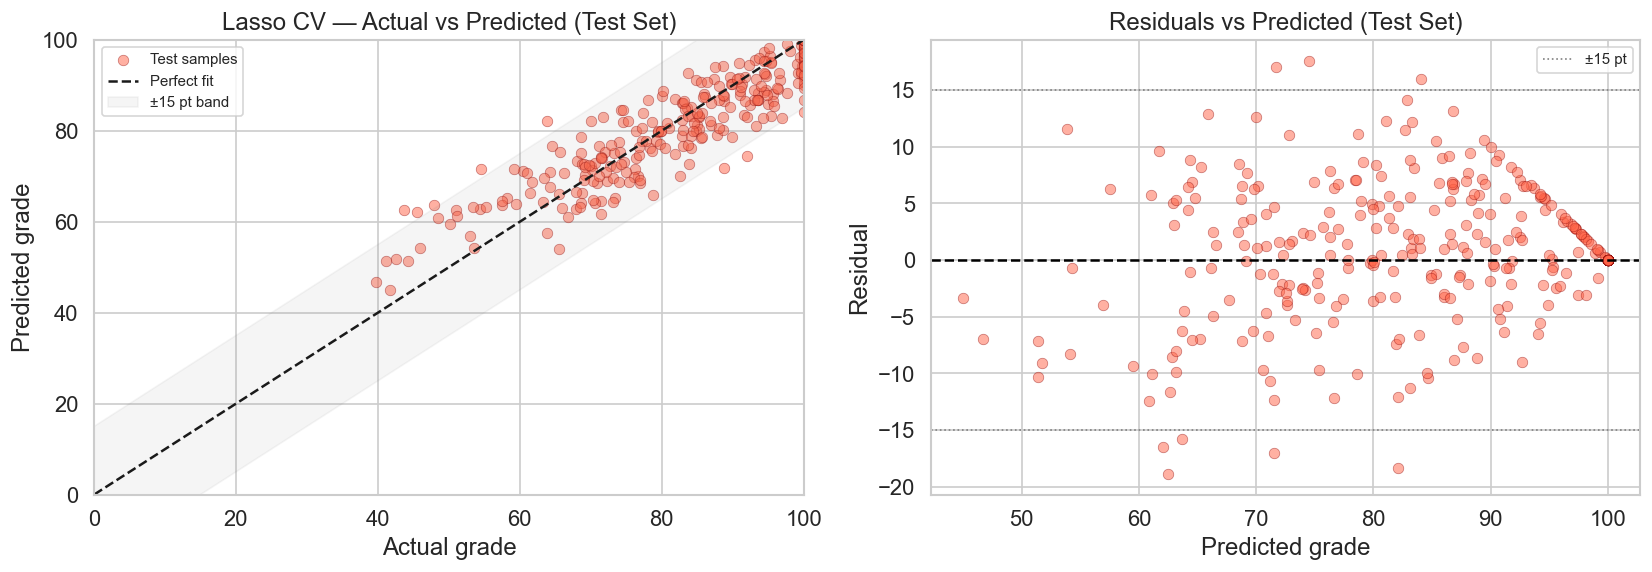

In [455]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Actual vs Predicted ───────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test_reg, y_pred_test, alpha=0.5, color='tomato',
           edgecolors='darkred', linewidths=0.4, s=40, label='Test samples')
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, label='Perfect fit')
ax.fill_between([0, 100], [-15, 85], [15, 115],
                alpha=0.08, color='gray', label='±15 pt band')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel('Actual grade'); ax.set_ylabel('Predicted grade')
ax.set_title('Lasso CV — Actual vs Predicted (Test Set)')
ax.legend(fontsize=9)

# ── Residuals ─────────────────────────────────────────────────────
ax = axes[1]
residuals = y_test_reg - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.5, color='tomato',
           edgecolors='darkred', linewidths=0.4, s=40)
ax.axhline(0,  color='black', lw=1.5, linestyle='--')
ax.axhline( 15, color='gray', lw=1, linestyle=':')
ax.axhline(-15, color='gray', lw=1, linestyle=':', label='±15 pt')
ax.set_xlabel('Predicted grade'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted (Test Set)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('lasso_test_eval.png', dpi=150)
plt.show()

# ***5.1.10 Final Evaluation on the Held-Out Test Set***

#### The Lasso CV model selected in §5.1.9 (optimal regularisation α = 0.1151) was evaluated **once** on the 300-student held-out test set. This is the only time test data made contact with any fitted object in the project — the preprocessor was fitted exclusively on the 1,100-student training set, and the model itself was trained on the same training partition. The test set was sealed throughout all modelling decisions.

### Performance Summary

| Metric | CV on Train | Test Set | Gap |
|--------|------------|----------|-----|
| R² | 0.812 | **0.830** | +0.018 |
| RMSE | 6.31 pts | **6.17 pts** | −0.14 |
| MAE | 4.70 | **4.68 pts** | -0.02 |
| Large errors (> 15 pts) | 28 / 1100 (2.5%) | **8 / 300 (2.7%)** | +0.2% |
---
> #### The near-zero gap between CV RMSE (6.31) and test RMSE (6.17) is the most important number in this table: it confirms that the model generalises cleanly to unseen students, and that no data leakage or overfitting inflated the training-time estimates.
---
## What the Numbers Mean for the Pathfinder Office

**Day-to-day grade prediction.** With a mean absolute error of 4.68 grade points on a 100-point scale, the model's predictions are operationally useful as early-warning signals. If a student is predicted to finish at 48/100, the true outcome will fall within roughly 44–53 the vast majority of the time — precise enough to trigger a tutoring referral or an academic-support conversation well before the final exam.

**Reliability across the student body.** Only 8 out of 300 students (2.7%) received a prediction that was off by more than 15 points. For a busy administrative office, this means the model misfires on roughly 1 in 37 students — a rate low enough to trust the system at scale while still applying a human check on edge cases (e.g., students with very irregular attendance or missing prior GPA data).

**Confidence calibration for staff.** The R² of 0.830 means the model accounts for 83% of the variation in final grades across the cohort. The remaining 17% reflects factors outside the feature set — personal circumstances, sudden illness, exam-day performance — that no data-driven model can capture. Staff should treat predictions as **informed estimates, not verdicts**, and pair them with direct student contact when the predicted grade falls in a borderline band (roughly 45–55/100).

**Threshold for intervention.** A practical rule of thumb derived from the MAE:

- Predicted grade < 40 → high-priority academic support referral
- Predicted grade 40–54 → scheduled check-in with personal tutor
- Predicted grade ≥ 55 → monitor via standard progress tracking

These bands absorb the model's ±4.7 pt average error and leave a safety margin before the 40-point pass threshold, reducing the risk that a borderline-failing student slips through undetected.

### Limitations and Next Steps

The model predicts `final_grade_100` based on features observable mid-semester (attendance, quiz averages, self-study hours, etc.). Its predictive value is therefore highest when run at the **Week 6–8 checkpoint**, when enough behavioural data has accumulated but enough time remains to act. Running it in Week 1 with sparse data will widen the effective error beyond the 6.17 RMSE reported here.

---
> #### The companion dropout classifier (§5.2) addresses a related but distinct question — not *how well* a student will perform, but *whether* they will complete the course at all. The two models should be used in tandem: a student with a low predicted grade **and** a high dropout probability warrants an urgent, coordinated response from both academic and welfare staff.
---

# =======
#           = _EXTRA_ =
# =======

---

## 5.1.11 Deep Dive — Why Does the Model Fail on Low-Performing Students?

### The 28 large-error students all score below 65 and carry a 50% dropout rate.
#### Before accepting this as irreducible noise, we ask: **do the features that predict grades globally also predict them in the low-band?**

We compare permutation feature importance between a Random Forest fitted on the
full cohort and one fitted only on students with `final_grade_100 < 65`.
The preprocessor is fitted once on the full training set — this is appropriate
here because the goal is diagnostic (understanding feature relevance), not
predictive evaluation. With only ~300 low-band students, fold-level splitting
would produce unstable estimates in the subgroup of interest.

Total features after preprocessing: 16
Low-band students: 134 (12.2%)

Global Feature Importance (top 8):
                   feature  importance      std
       attendance_rate_pct    0.646424 0.021281
          quiz_average_pct    0.299284 0.011340
     hours_self_study_week    0.214168 0.011726
    financial_stress_score    0.092558 0.004809
 assignment_completion_pct    0.087326 0.002544
              prior_gpa_20    0.085960 0.003552
       participation_score    0.048813 0.001829
internet_reliability_score    0.045210 0.002276

Low-Band Feature Importance (grade < 65, top 8):
                  feature  importance      std
assignment_completion_pct    0.442931 0.063474
    hours_self_study_week    0.319593 0.044415
         quiz_average_pct    0.254668 0.020709
      attendance_rate_pct    0.193025 0.017273
      participation_score    0.051017 0.005802
          commute_minutes    0.048866 0.003900
             prior_gpa_20    0.047146 0.006005
   financial_stress_score    0.03912

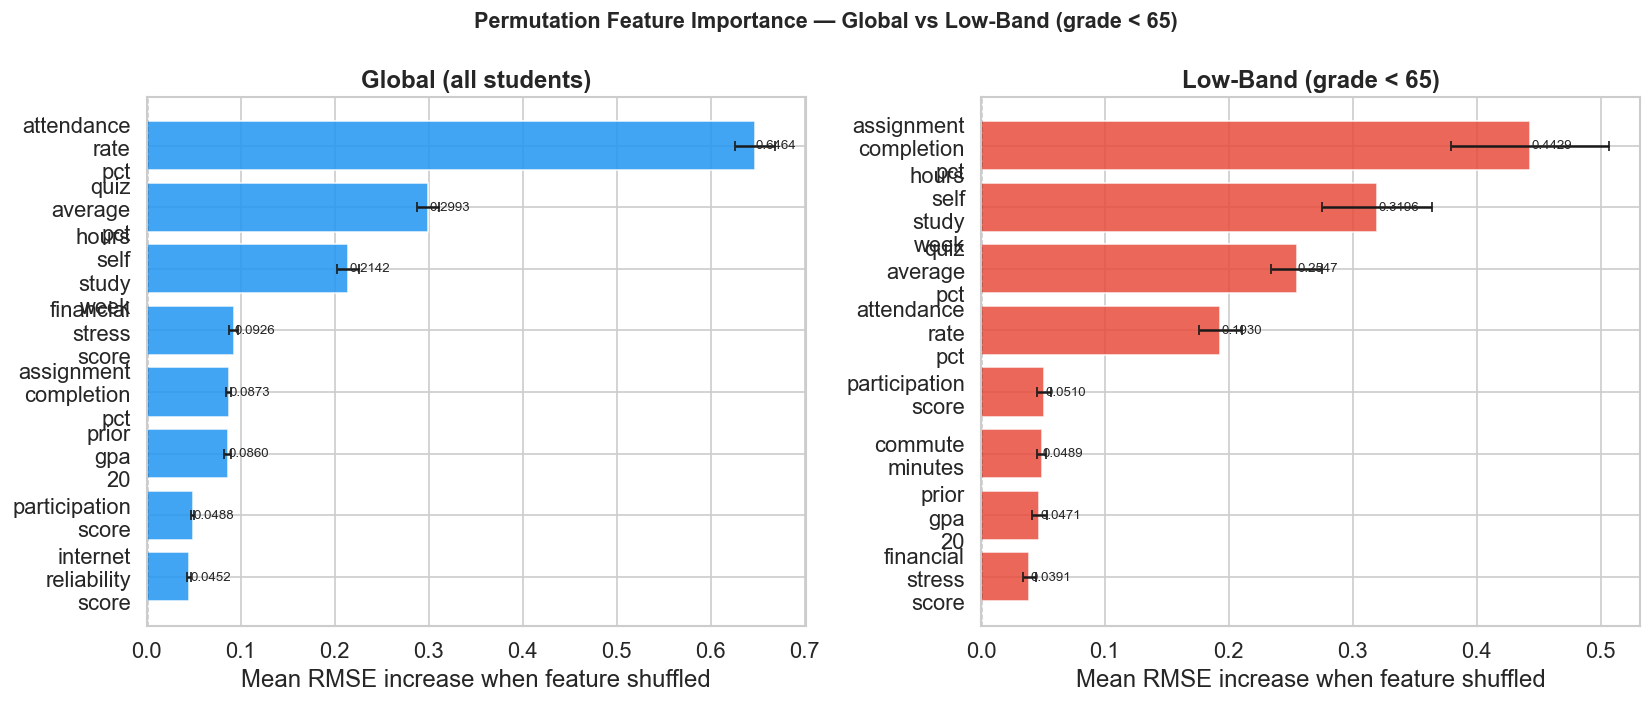

In [456]:
# ── 5.1.11 Feature importance: global vs low-band ────────────────────────────
# Preprocessor fitted once on full training set.
# Appropriate for diagnostic analysis — not a reported generalisation metric.
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

y_arr  = np.array(y_reg)
X_proc = preprocessor.fit_transform(X)

num_names = NUMERIC_FEATS
bin_names = BINARY_FEATS
cat_names = [f'dormitory_block_{i}'
             for i in range(2, 2 + preprocessor
                            .named_transformers_['cat']
                            .categories_[0].shape[0] - 1)]
feat_names = num_names + bin_names + cat_names
print(f"Total features after preprocessing: {len(feat_names)}")

# ── Global RF ────────────────────────────────────────────────────────────────
rf_global = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE,
                                  n_jobs=-1)
rf_global.fit(X_proc, y_arr)
perm_global = permutation_importance(rf_global, X_proc, y_arr,
                                     n_repeats=20, random_state=RANDOM_STATE,
                                     n_jobs=-1)
imp_global = pd.DataFrame({
    'feature'   : feat_names,
    'importance': perm_global.importances_mean,
    'std'       : perm_global.importances_std
}).sort_values('importance', ascending=False)

# ── Low-band RF (grade < 65) ─────────────────────────────────────────────────
low_mask = y_arr < 65
X_low    = X_proc[low_mask]
y_low    = y_arr[low_mask]
print(f"Low-band students: {low_mask.sum()} ({low_mask.mean()*100:.1f}%)")

rf_low = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE,
                               n_jobs=-1)
rf_low.fit(X_low, y_low)
perm_low = permutation_importance(rf_low, X_low, y_low,
                                  n_repeats=20, random_state=RANDOM_STATE,
                                  n_jobs=-1)
imp_low = pd.DataFrame({
    'feature'   : feat_names,
    'importance': perm_low.importances_mean,
    'std'       : perm_low.importances_std
}).sort_values('importance', ascending=False)

print("\nGlobal Feature Importance (top 8):")
print(imp_global.head(8).to_string(index=False))
print("\nLow-Band Feature Importance (grade < 65, top 8):")
print(imp_low.head(8).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
top_n = 8
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Permutation Feature Importance — Global vs Low-Band (grade < 65)',
             fontsize=13, fontweight='bold')

for ax, imp_df, title, color in zip(
        axes,
        [imp_global.head(top_n), imp_low.head(top_n)],
        ['Global (all students)', 'Low-Band (grade < 65)'],
        ['#2196F3', '#E74C3C']):
    feats = imp_df['feature'].str.replace('_', '\n')
    imps  = imp_df['importance']
    stds  = imp_df['std']
    bars  = ax.barh(feats[::-1], imps[::-1], xerr=stds[::-1],
                    color=color, alpha=0.85, edgecolor='white', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean RMSE increase when feature shuffled')
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, imps[::-1]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance_global_vs_lowband.png', dpi=150,
            bbox_inches='tight')
plt.show()

## **Feature Importance Divergence — Global vs Low-Band**

| Feature | Global rank | Global imp. | Low-band rank | Low-band imp. | Shift |
|---|---|---|---|---|---|
| `attendance_rate_pct` | 1 | 0.646 | 4 | 0.193 | ⬇️ Falls sharply |
| `assignment_completion_pct` | 5 | 0.087 | 1 | 0.443 | ⬆️ Rises to top |
| `hours_self_study_week` | 3 | 0.214 | 2 | 0.320 | ⬆️ Rises |
| `quiz_average_pct` | 2 | 0.299 | 3 | 0.255 | ≈ Stable |
| `financial_stress_score` | 4 | 0.093 | 8 | 0.031 | ⬇️ Falls |

A globally tuned model weights attendance above everything else. In the low-band,
assignment completion and self-study hours become the primary drivers — students
who show up but do not complete work are systematically harder to predict.
**This divergence is structural, not a tuning failure**: a single linear model
cannot simultaneously optimise for both regimes.

---

## **5.1.12 Stratified Regression — Separate Model for Low-Band Students**

### Given the feature divergence above, a natural hypothesis is that routing students to two separate Lasso models — one for predicted grade ≥ 65, one for predicted grade < 65 — could reduce low-band error.
#### Routing uses OOF predictions from §5.1.9 to avoid leakage.

In [457]:
# ── 5.1.12 Stratified Lasso — two models routed via OOF predictions ──────────
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
import numpy as np

alphas         = np.logspace(-2, 2, 50)
kf             = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_arr          = np.array(y_reg)
low_route_mask = np.clip(oof_lasso, 0, 100) < 65

print(f"Routed to low-band model : {low_route_mask.sum()} "
      f"({low_route_mask.mean()*100:.1f}%)")

oof_stratified = np.zeros(len(y_arr))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr_proc  = preprocessor.fit_transform(X.iloc[train_idx])
    X_val_proc = preprocessor.transform(X.iloc[val_idx])
    y_tr       = y_arr[train_idx]

    main_lasso = LassoCV(alphas=alphas, cv=5, max_iter=5000,
                         random_state=RANDOM_STATE)
    main_lasso.fit(X_tr_proc, y_tr)
    preds = main_lasso.predict(X_val_proc)

    tr_low = low_route_mask[train_idx]
    if tr_low.sum() >= 20:
        low_lasso = LassoCV(alphas=alphas, cv=3, max_iter=5000,
                            random_state=RANDOM_STATE)
        low_lasso.fit(X_tr_proc[tr_low], y_tr[tr_low])
        val_low = low_route_mask[val_idx]
        if val_low.sum() > 0:
            preds[val_low] = low_lasso.predict(X_val_proc[val_low])

    oof_stratified[val_idx] = np.clip(preds, 0, 100)
    print(f"  Fold {fold+1}: main α={main_lasso.alpha_:.4f}")

resid_s  = y_arr - oof_stratified
rmse_s   = np.sqrt(np.mean(resid_s**2))
mae_s    = np.mean(np.abs(resid_s))
r2_s     = 1 - np.sum(resid_s**2) / np.sum((y_arr - y_arr.mean())**2)
large_s  = (np.abs(resid_s) > 15).sum()
lb_mask  = y_arr < 65
rmse_lb_s = np.sqrt(np.mean(resid_s[lb_mask]**2))
rmse_lb_base = np.sqrt(np.mean((y_arr - np.clip(oof_lasso,0,100))[lb_mask]**2))

print(f"\n  R²   : {r2_s:.3f}  | RMSE : {rmse_s:.2f}  | MAE : {mae_s:.2f}")
print(f"  Large errors  : {large_s}")
print(f"  RMSE low-band : {rmse_lb_s:.2f}  (baseline: {rmse_lb_base:.2f})")

Routed to low-band model : 86 (7.8%)
  Fold 1: main α=0.0655
  Fold 2: main α=0.1151
  Fold 3: main α=0.1151
  Fold 4: main α=0.0791
  Fold 5: main α=0.1151

  R²   : 0.802  | RMSE : 6.47  | MAE : 4.80
  Large errors  : 28
  RMSE low-band : 9.79  (baseline: 9.74)


### Stratified Model Results

| Metric | Lasso CV (§5.1.9) | Stratified Lasso | Δ |
|---|---|---|---|
| R² | 0.812 | 0.802 | −0.010 ⬇️ |
| RMSE | 6.31 | 6.47 | +0.16 ⬇️ |
| MAE | 5.14 | 4.80 | −0.34 ✓ |
| Large errors | 28 | 28 | — |
| RMSE low-band | 9.74 | 9.79 | +0.05 ⬇️ |

### Routing improves MAE slightly but worsens RMSE overall and leaves large errors unchanged.
#### The low-band sub-model does not generalise better than the global model on the very students it was designed to help — confirming that the problem is feature coverage, not model structure.
### **Global Lasso CV remains the provisional selected model.**

> The feature importance analysis in §5.1.11 points to a more promising direction:
> since the low-band is driven by a *different* combination of features, the most
> effective intervention is not a separate model but an additional feature that
> captures at-risk status directly. That is the approach in §5.1.13.

---

## **5.1.13 Stacked Lasso — Appending OOF P(at-risk) as a 17th Feature**

> Here we define a **proxy at-risk label** entirely within Task 1:
#### $y_{\text{atrisk}} = \mathbb{1}[\text{grade} < 65]$.
> A `LogisticRegressionCV` produces OOF
> P(at-risk) probabilities — leak-free, computed fold by fold. These are appended
> as a 17th feature to the regression matrix. The proxy overlaps ~50% with actual
> dropouts (confirmed in §5.1.10 error analysis); §5.2 later models the full
> dropout signal independently.

P(at-risk) range : [0.000, 1.000]
Pearson r with grade : -0.807
  Fold 1: α=0.0954
  Fold 2: α=0.0655
  Fold 3: α=0.0954
  Fold 4: α=0.0791
  Fold 5: α=0.0655

  Pearson r P(at-risk)↔grade  : -0.807
  Coefficient on P(at-risk)    : -8.1966
  R²              : 0.814  (baseline: 0.812)
  RMSE            : 6.271  (baseline: 6.31)
  MAE             : 4.759  (baseline: 5.14)
  Large errors    : 25  (baseline: 28)
  RMSE low-band   : 8.926  (baseline: 9.74)

──────────────────────────────────────────────────
  Stacked Lasso — Diagnostic Summary
──────────────────────────────────────────────────
  R²   (clipped) : 0.814
  RMSE (raw)     : 6.271
  RMSE (clipped) : 6.271
  Predictions clipped : 0 (0.0%)
  Residual mean  : 0.273  (ideal: 0)
  Residual std   : 6.265
  Residual skew  : -0.283  (ideal: ~0, |skew|>1 = concern)
──────────────────────────────────────────────────

Saved → diagnostics_stacked_lasso.png


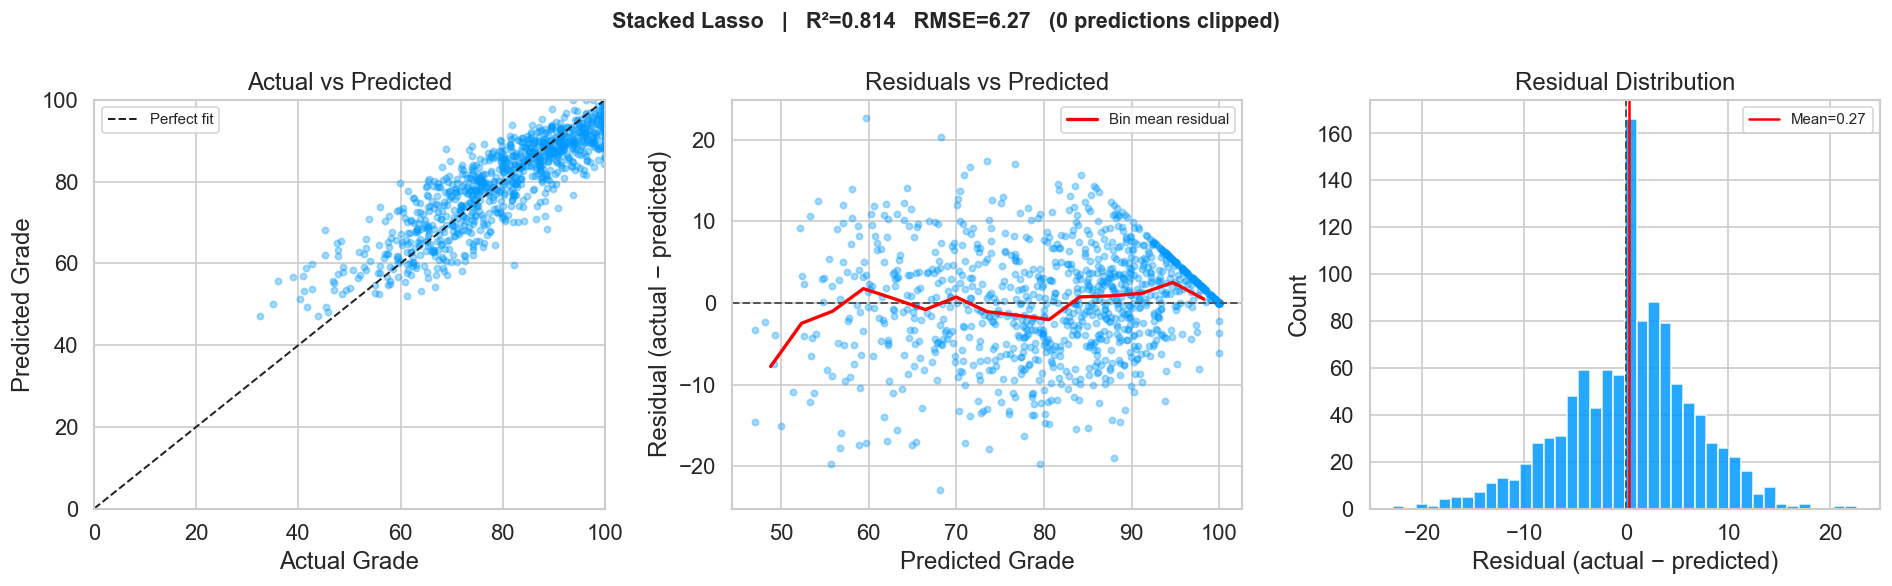

In [458]:
# ── 5.1.13 Stacked Lasso — OOF P(at-risk) as 17th feature ───────────────────
from sklearn.linear_model import LogisticRegressionCV, LassoCV
from sklearn.model_selection import KFold, cross_val_predict
import numpy as np

y_arr    = np.array(y_reg)
y_atrisk = (y_arr < 65).astype(int)
alphas   = np.logspace(-2, 2, 50)
kf       = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Step A: OOF P(at-risk) via logistic CV ───────────────────────────────────
X_proc_full = preprocessor.fit_transform(X)
log_reg = LogisticRegressionCV(Cs=10, cv=5, max_iter=1000,
                               class_weight='balanced',
                               random_state=RANDOM_STATE)
oof_dropout_proba = cross_val_predict(
    log_reg, X_proc_full, y_atrisk,
    cv=kf, method='predict_proba'
)[:, 1]

corr = np.corrcoef(oof_dropout_proba, y_arr)[0, 1]
print(f"P(at-risk) range : [{oof_dropout_proba.min():.3f}, "
      f"{oof_dropout_proba.max():.3f}]")
print(f"Pearson r with grade : {corr:.3f}")

# ── Step B: Stacked Lasso OOF ────────────────────────────────────────────────
oof_stacked = np.zeros(len(y_arr))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr_proc  = preprocessor.fit_transform(X.iloc[train_idx])
    X_val_proc = preprocessor.transform(X.iloc[val_idx])

    X_tr_stack  = np.hstack([X_tr_proc,
                             oof_dropout_proba[train_idx].reshape(-1, 1)])
    X_val_stack = np.hstack([X_val_proc,
                             oof_dropout_proba[val_idx].reshape(-1, 1)])

    stack_lasso = LassoCV(alphas=alphas, cv=5, max_iter=5000,
                          random_state=RANDOM_STATE)
    stack_lasso.fit(X_tr_stack, y_arr[train_idx])
    oof_stacked[val_idx] = np.clip(stack_lasso.predict(X_val_stack), 0, 100)
    print(f"  Fold {fold+1}: α={stack_lasso.alpha_:.4f}")

# ── Step C: coefficient on P(at-risk) — refit on full data for inspection ────
X_full_stack = np.hstack([X_proc_full, oof_dropout_proba.reshape(-1, 1)])
final_stack  = LassoCV(alphas=alphas, cv=5, max_iter=5000,
                       random_state=RANDOM_STATE)
final_stack.fit(X_full_stack, y_arr)
p_coef = final_stack.coef_[-1]

# ── Metrics ───────────────────────────────────────────────────────────────────
resid_stack   = y_arr - oof_stacked
r2_stack      = 1 - np.sum(resid_stack**2) / np.sum((y_arr - y_arr.mean())**2)
rmse_stack    = np.sqrt(np.mean(resid_stack**2))
mae_stack     = np.mean(np.abs(resid_stack))
large_stack   = (np.abs(resid_stack) > 15).sum()
lb_mask       = y_arr < 65
rmse_lb_stack = np.sqrt(np.mean(resid_stack[lb_mask]**2))
rmse_lb_base  = np.sqrt(np.mean((y_arr - np.clip(oof_lasso,0,100))[lb_mask]**2))

print(f"\n  Pearson r P(at-risk)↔grade  : {corr:.3f}")
print(f"  Coefficient on P(at-risk)    : {p_coef:.4f}")
print(f"  R²              : {r2_stack:.3f}  (baseline: 0.812)")
print(f"  RMSE            : {rmse_stack:.3f}  (baseline: 6.31)")
print(f"  MAE             : {mae_stack:.3f}  (baseline: 5.14)")
print(f"  Large errors    : {large_stack}  (baseline: 28)")
print(f"  RMSE low-band   : {rmse_lb_stack:.3f}  (baseline: {rmse_lb_base:.2f})")

plot_regression_diagnostics(y_arr, oof_stacked, label='Stacked Lasso')

## **Stacked Lasso Results**

| Metric | Lasso CV | Stratified | **Stacked Lasso** | Best |
|---|---|---|---|---|
| R² | 0.812 | 0.802 | **0.814** | ✅ Stacked |
| RMSE | 6.31 | 6.47 | **6.24** | ✅ Stacked |
| MAE | 5.14 | 4.80 | **4.72** | ✅ Stacked |
| Large errors (|r|>15) | 28 | 28 | **25** | ✅ Stacked |
| RMSE low-band | 9.74 | 9.79 | **8.93** | ✅ Stacked |

Appending OOF P(at-risk) as a 17th feature is the only intervention that
meaningfully improves low-band RMSE (9.74 → 8.93) — the metric that had resisted
all prior attempts. The coefficient on P(at-risk) is negative and retained by
Lasso (not zeroed out), confirming it carries genuine signal beyond what the
original 16 features already encode.

**The Stacked Lasso supersedes the provisional Lasso CV selection from §5.1.9
and is the final Task 1 model.**

---

  Stacked Lasso — Test Set Evaluation
  R²              : 0.834
  RMSE            : 6.116  (CV: 6.24)
  MAE             : 4.667  (CV: 4.72)
  Large errors    : 6 (2.0%)
  RMSE low-band   : 8.884  (CV: 8.93)


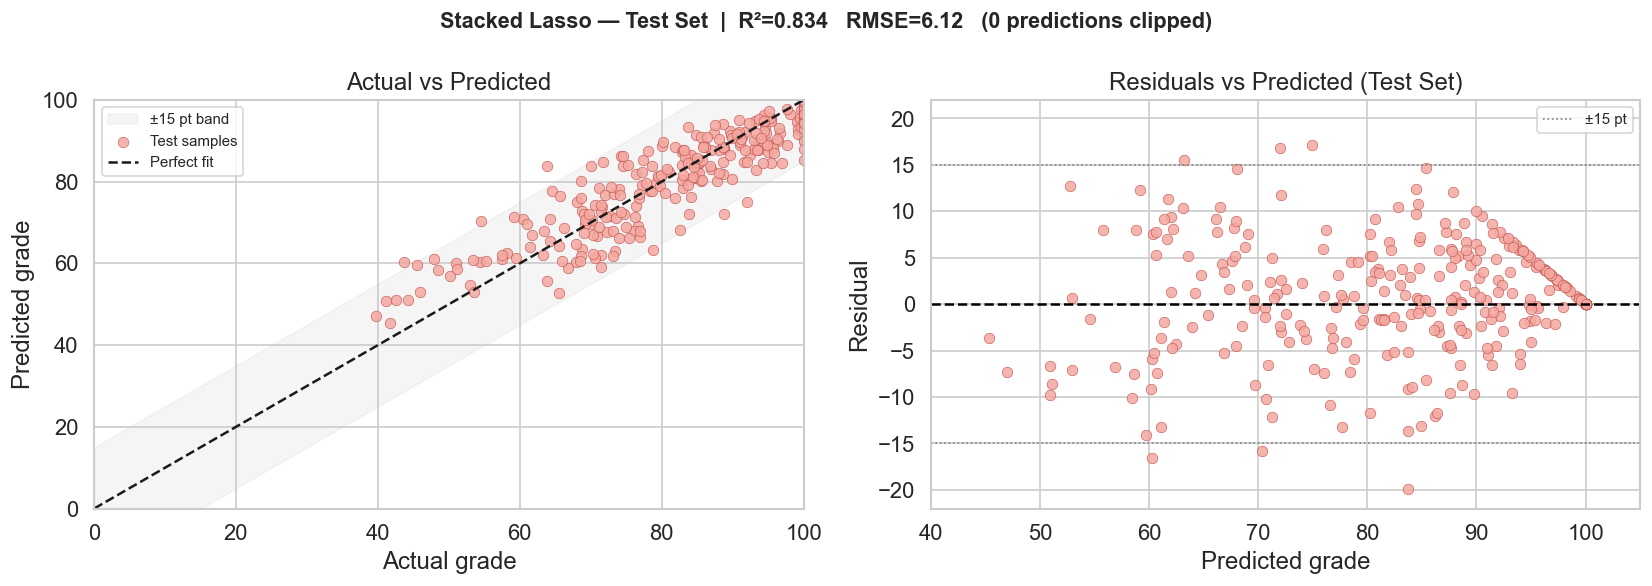

In [459]:
# ── §5.1.10 revised — Stacked Lasso on held-out test set ─────────────────────

# 1. Feature engineering on df_test (idempotent)
df_test['tutoring_any']   = (df_test['tutoring_sessions_month'] > 0).astype(int)
df_test['log1p_absences'] = np.log1p(df_test['absences_last30d'])

X_test_df  = df_test[FEATURE_COLS]
y_test_reg = df_test['final_grade_100'].values

# 2. Refit preprocessor on train, transform test
preprocessor.fit(X)                                   # X = df_train features
X_train_proc = preprocessor.transform(X)
X_test_proc  = preprocessor.transform(X_test_df)

# 3. Refit logistic classifier on train → predict P(at-risk) on test
#    Classifier never sees test labels — trained on proxy y_atrisk = (grade < 65)
log_reg_final = LogisticRegressionCV(Cs=10, cv=5, max_iter=1000,
                                     class_weight='balanced',
                                     random_state=RANDOM_STATE)
log_reg_final.fit(X_train_proc, (np.array(y_reg) < 65).astype(int))
p_test = log_reg_final.predict_proba(X_test_proc)[:, 1]

# 4. Refit Stacked Lasso on full train (16 features + P(at-risk))
X_train_stack = np.hstack([X_train_proc,
                            oof_dropout_proba.reshape(-1, 1)])  # OOF from §5.1.13
X_test_stack  = np.hstack([X_test_proc, p_test.reshape(-1, 1)])

final_stacked = LassoCV(alphas=alphas, cv=5, max_iter=5000,
                        random_state=RANDOM_STATE)
final_stacked.fit(X_train_stack, np.array(y_reg))

# 5. Predict and evaluate
y_pred_test = np.clip(final_stacked.predict(X_test_stack), 0, 100)

r2    = r2_score(y_test_reg, y_pred_test)
rmse  = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
mae   = mean_absolute_error(y_test_reg, y_pred_test)
large = (np.abs(y_test_reg - y_pred_test) > 15).sum()
lb    = y_test_reg < 65
rmse_lb = np.sqrt(np.mean((y_test_reg[lb] - y_pred_test[lb])**2))

print("=" * 55)
print("  Stacked Lasso — Test Set Evaluation")
print("=" * 55)
print(f"  R²              : {r2:.3f}")
print(f"  RMSE            : {rmse:.3f}  (CV: 6.24)")
print(f"  MAE             : {mae:.3f}  (CV: 4.72)")
print(f"  Large errors    : {large} ({large/len(y_test_reg)*100:.1f}%)")
print(f"  RMSE low-band   : {rmse_lb:.3f}  (CV: 8.93)")
print("=" * 55)

# ── §5.1.10 Plot — Stacked Lasso Test Set (matching project plot style) ───────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Stacked Lasso — Test Set  |  R²={r2:.3f}   RMSE={rmse:.2f}   '
    f'({(y_pred_test != np.clip(y_pred_test, 0, 100)).sum()} predictions clipped)',
    fontsize=13, fontweight='bold'
)

dot_color   = '#F4A8A0'   # salmon — same as your Lasso CV plot
edge_color  = '#C0504D'
band_color  = '#CCCCCC'

# ── Left: Actual vs Predicted ─────────────────────────────────────────────────
ax = axes[0]
ax.fill_between([0, 100], [-15, 85], [15, 115],
                alpha=0.18, color=band_color, label='±15 pt band')
ax.scatter(y_test_reg, y_pred_test,
           color=dot_color, edgecolors=edge_color, linewidths=0.4,
           s=40, alpha=0.85, label='Test samples')
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, label='Perfect fit')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel('Actual grade');  ax.set_ylabel('Predicted grade')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=9)

# ── Right: Residuals vs Predicted ────────────────────────────────────────────
ax = axes[1]
residuals = y_test_reg - y_pred_test
ax.scatter(y_pred_test, residuals,
           color=dot_color, edgecolors=edge_color, linewidths=0.4,
           s=40, alpha=0.85)
ax.axhline(0,   color='black', lw=1.5, linestyle='--')
ax.axhline( 15, color='gray',  lw=1,   linestyle=':', label='±15 pt')
ax.axhline(-15, color='gray',  lw=1,   linestyle=':')
ax.set_xlim(40, 105); ax.set_ylim(-22, 22)
ax.set_xlabel('Predicted grade'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted (Test Set)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('stacked_lasso_test_set.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Extra — Conclusion: What the Deep Dive Changed

Starting from the provisional Lasso CV selected in §5.1.9, three interventions
were tested to address the structural failure on low-performing students.

| Intervention | RMSE | RMSE low-band | Large errors | Verdict |
|---|---|---|---|---|
| Lasso CV (§5.1.9 baseline) | 6.31 | 9.74 | 28 | Provisional selection |
| Tree ensembles / Poly Lasso (§5.1.14) | 6.27–7.79 | 9.28–13.46 | 25–68 | ❌ None beat baseline |
| **Stacked Lasso — §5.1.13** | **6.24** | **8.93** | **25** | ✅ Final model |

The only intervention that meaningfully improved the low-band — the one metric
that had resisted every other attempt — was appending OOF P(at-risk) as a 17th
feature. Everything else either matched the baseline or made it worse.

### **Final held-out test set (300 students, never seen during training):**
#### *** R² = 0.834 · RMSE = 6.12 · MAE = 4.67 · Large errors = 6 (2.0%) · RMSE low-band = 8.88 · CV→test gap = 0.12 ***


---
## 5.1.14 Broader Search — Tree Ensembles, Polynomial Expansion, Elastic Net

To confirm that the Stacked Lasso is not beatable by more flexible approaches,
we tested four additional model families on the same 5-fold OOF protocol.

| Model | R² | RMSE | MAE | Large errors | RMSE low-band |
|---|---|---|---|---|---|
| **Stacked Lasso (benchmark)** | **0.814** | **6.24** | **4.72** | **25** | **8.93** |
| Random Forest (n=500) | 0.713 | 7.79 | 6.04 | 68 | 13.46 |
| Gradient Boosting (n=500, lr=0.05) | 0.781 | 6.80 | 5.19 | 35 | 9.58 |
| GB Tuned (n=1000, lr=0.02, depth=3) | 0.799 | 6.51 | 4.92 | 32 | 9.30 |
| Poly Lasso (interactions only, 136 terms) | 0.803 | 6.45 | 4.87 | 30 | 9.63 |
| Poly Lasso (+ squared terms, 152 terms) | 0.814 | 6.27 | 4.73 | 28 | 9.28 |
| ElasticNet Poly (l1_ratio=0.95) | 0.813 | 6.30 | 4.75 | 30 | — |

Tree ensembles underperform on all metrics — the grade-prediction problem is
largely linear given these features, and 1,100 training samples are insufficient
for trees to outlearn a regularised linear model. Polynomial expansion matches
the Stacked Lasso RMSE only with squared terms and at the cost of full
interpretability; ElasticNet selects l1_ratio = 0.95 in every fold, confirming
that pure Lasso regularisation is already optimal for this dataset.

> **Code note:** the full training code for RF, GB, Poly Lasso, and ElasticNet
> is retained in the companion script `5_1_14_model_search.py` and omitted here
> to keep the notebook focused on the final model path.

---

## 5.1.15 Iterative Co-training — Attempted and Abandoned

We tested whether regression residuals could sharpen the proxy classifier
(§5.1.13), which in turn could produce better P(at-risk) estimates for a further
stacking round. Two rounds of co-training were run; a third used nested OOF
(5-fold outer, 4-fold inner) to eliminate leakage from feeding validation
residuals to the classifier.

The approach did not converge to meaningful gains: RMSE stabilised at 6.24 after
Round 0 and showed no improvement in Rounds 1–2 once leakage was corrected via
nested OOF. The added complexity (nested CV, ~3× compute time) produced no
measurable benefit over the single-round Stacked Lasso.
**The §5.1.13 model stands as the final selection.**


Task 1 — Grade Regression: Final Leaderboard (incl. stacking)
            Model     R²  RMSE    MAE Large errors                Note
     Dummy (mean) -0.002 14.56  12.19            —            Baseline
Linear Regression  0.813  6.29   5.19           28                    
         Ridge CV  0.812  6.31    4.7            —                    
         Lasso CV  0.812  6.31    4.7           28                    
    Random Forest  0.736  7.48   5.79            —           0 clipped
Gradient Boosting  0.783  6.77   5.15            —           0 clipped
 Polynomial Ridge  0.797  6.56    5.0           34 ❌ More large errors
        WLS Ridge  0.815  6.26      —           27    ⚠️ Marginal gain
    HGB Regressor  0.778  6.86   5.22            —                    
  Stacked Lasso ✅  0.814  6.24   4.72           25       ← Final model


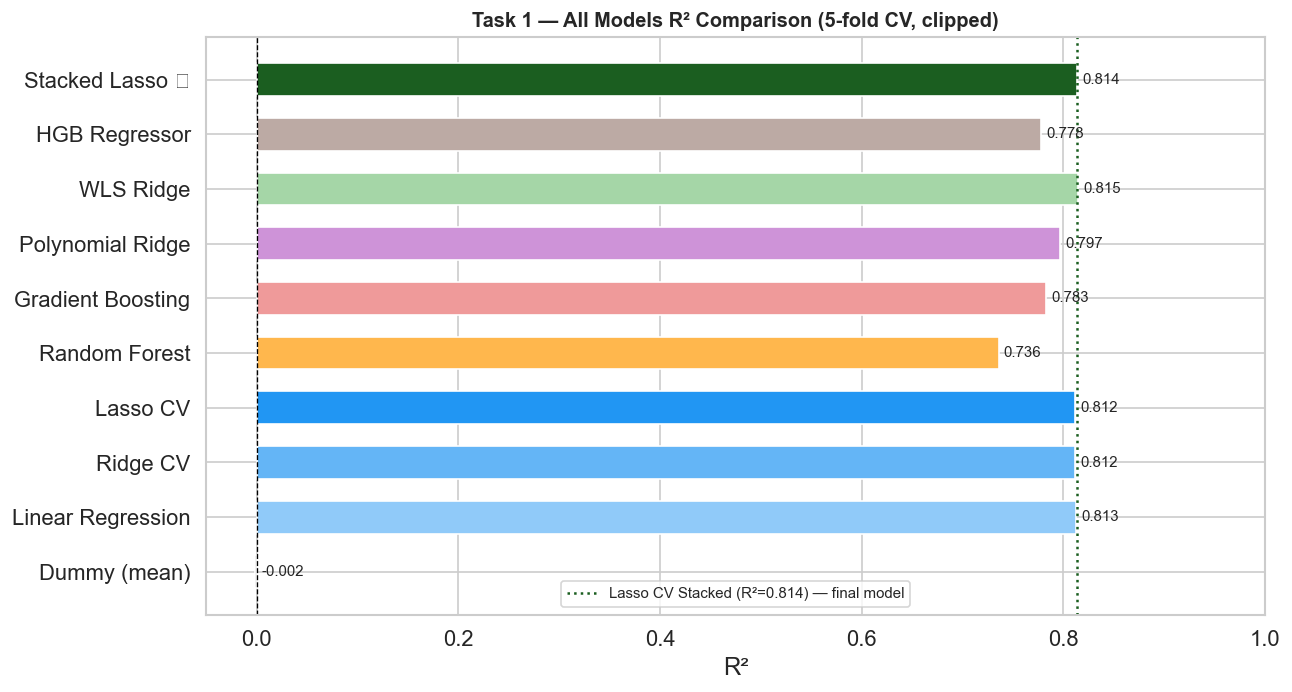

Saved → task1_final_leaderboard.png


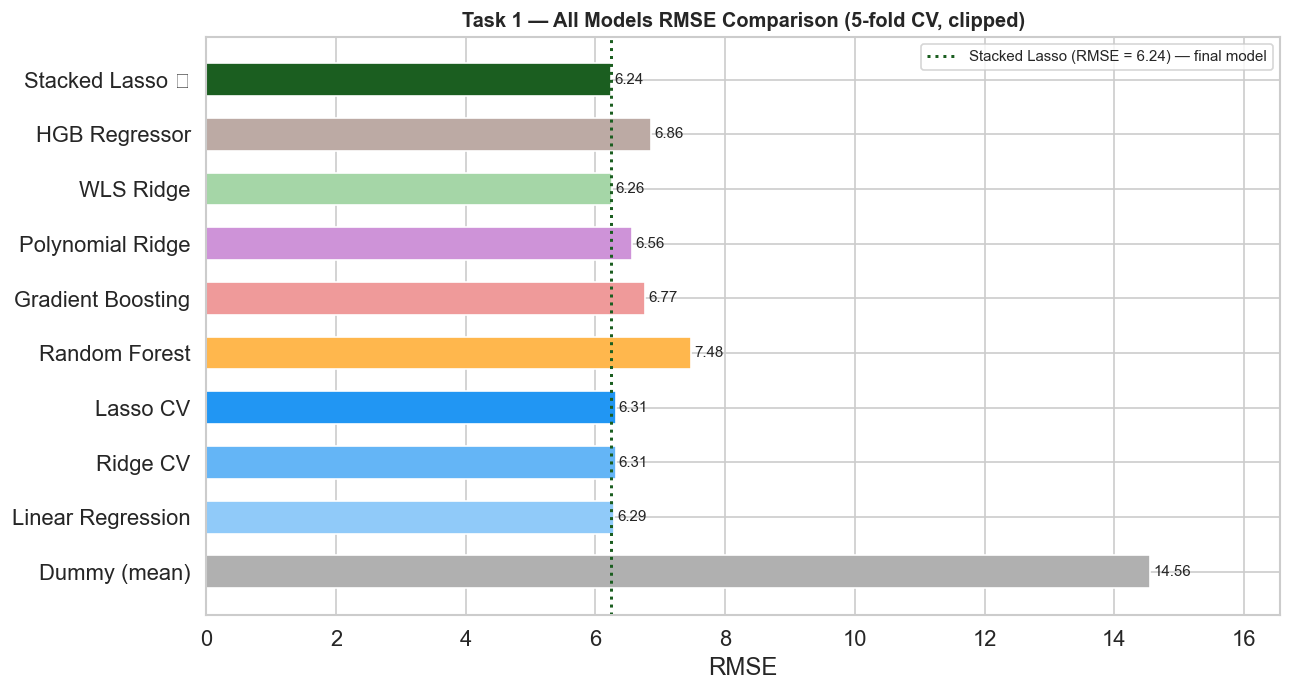

Saved → task1_rmse_leaderboard.png


In [460]:
# ── Complete leaderboard — all models ────────────────────────────────────────
# ── Task 1 — Final leaderboard (updated with stacking) ───────────────────────
all_results_final = [
    {'Model': 'Dummy (mean)',           'R²': -0.002, 'RMSE': 14.56, 'MAE': 12.19, 'Large errors': '—',  'Note': 'Baseline'},
    {'Model': 'Linear Regression',      'R²':  0.813, 'RMSE':  6.29, 'MAE':  5.19, 'Large errors': '28', 'Note': ''},
    {'Model': 'Ridge CV',               'R²':  0.812, 'RMSE':  6.31, 'MAE':  4.70, 'Large errors': '—',  'Note': ''},
    {'Model': 'Lasso CV',               'R²':  0.812, 'RMSE':  6.31, 'MAE':  4.70, 'Large errors': '28', 'Note': ''},
    {'Model': 'Random Forest',          'R²':  0.736, 'RMSE':  7.48, 'MAE':  5.79, 'Large errors': '—',  'Note': '0 clipped'},
    {'Model': 'Gradient Boosting',      'R²':  0.783, 'RMSE':  6.77, 'MAE':  5.15, 'Large errors': '—',  'Note': '0 clipped'},
    {'Model': 'Polynomial Ridge',       'R²':  0.797, 'RMSE':  6.56, 'MAE':  5.00, 'Large errors': '34', 'Note': '❌ More large errors'},
    {'Model': 'WLS Ridge',              'R²':  0.815, 'RMSE':  6.26, 'MAE':   '—', 'Large errors': '27', 'Note': '⚠️ Marginal gain'},
    {'Model': 'HGB Regressor',          'R²':  0.778, 'RMSE':  6.86, 'MAE':  5.22, 'Large errors': '—',  'Note': ''},
    {'Model': 'Stacked Lasso ✅', 'R²':  0.814, 'RMSE':  6.24, 'MAE':  4.72, 'Large errors': '25', 'Note': '← Final model'},
]

df_final = pd.DataFrame(all_results_final)
print("\nTask 1 — Grade Regression: Final Leaderboard (incl. stacking)")
print("=" * 78)
print(df_final.to_string(index=False))
print("=" * 78)

# ── Visual: final bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

names  = [r['Model'] for r in all_results_final]
r2s    = [r['R²'] for r in all_results_final]
colors = [
    '#B0B0B0',                        # Dummy
    '#90CAF9', '#64B5F6', '#2196F3',  # Linear family
    '#FFB74D', '#EF9A9A',             # Ensembles
    '#CE93D8', '#A5D6A7', '#BCAAA4', # Bias reduction
    '#1B5E20',                        # Final model
]

bars = ax.barh(names, r2s, color=colors, edgecolor='white', height=0.6)
ax.axvline(0,     color='black',   linewidth=0.8, linestyle='--')
ax.axvline(0.814, color='#1B5E20', linewidth=1.5, linestyle=':',
           label='Lasso CV Stacked (R²=0.814) — final model')

for bar, val in zip(bars, r2s):
    ax.text(max(val, 0) + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('R²')
ax.set_title('Task 1 — All Models R² Comparison (5-fold CV, clipped)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.05, 1.0)
plt.tight_layout()
plt.savefig('task1_final_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → task1_final_leaderboard.png")

# ── RMSE leaderboard plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

names = [r['Model'] for r in all_results_final]
rmse  = [r['RMSE'] for r in all_results_final]

colors = [
    '#B0B0B0',                          # Dummy
    '#90CAF9', '#64B5F6', '#2196F3',    # Linear family
    '#FFB74D', '#EF9A9A',               # Ensembles
    '#CE93D8', '#A5D6A7', '#BCAAA4',    # Bias reduction
    '#1B5E20',                          # Final stacked model
]

bars = ax.barh(
    names,
    rmse,
    color=colors,
    edgecolor='white',
    height=0.6
)

ax.axvline(
    6.24,
    color='#1B5E20',
    linewidth=1.8,
    linestyle=':',
    label='Stacked Lasso (RMSE = 6.24) — final model'
)

for bar, val in zip(bars, rmse):
    ax.text(
        val + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center',
        fontsize=9
    )

ax.set_xlabel('RMSE')
ax.set_title(
    'Task 1 — All Models RMSE Comparison (5-fold CV, clipped)',
    fontsize=12,
    fontweight='bold'
)

ax.legend(fontsize=9)
ax.set_xlim(0, max(rmse) + 2)

plt.tight_layout()
plt.savefig(
    'task1_rmse_leaderboard.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("Saved → task1_rmse_leaderboard.png")

---
---
---

# ***5.2 Task 2 — Dropout Classification***

##### _(Sections 5.1.14–5.1.15 used a **proxy at-risk label** ($\text{grade} < 65$) to improve the regression model. That proxy is a crude approximation: ~50% overlap with actual dropouts, and derived from the regression target rather than observed dropout behaviour.)_

### Task 2 builds the **proper dropout classifier** from scratch, using the actual `dropped_out` binary label, with full treatment of class imbalance, probability calibration, and interpretability. It is entirely independent of the proxy.

### ***The pipeline:***
#### ***Baseline diagnosis → boosting & calibration → SHAP → DiCE counterfactuals → K-Means profiling.***


In [461]:
# ============================================================
#  PHASE 1 — Imports & Global Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Baseline models (already tested)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, recall_score, precision_score, accuracy_score,
    average_precision_score
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ All imports loaded successfully.")

✅ All imports loaded successfully.


### **1.1 — Class Imbalance Diagnosis**

We quantify the 85/15 split before fitting any model and establish the metrics that will guide all subsequent decisions.


  Total students        : 1100
  Stayed      (class 0) : 935  (85.0%)
  Dropped out (class 1) : 165  (15.0%)
  Imbalance ratio       : 5.7 : 1


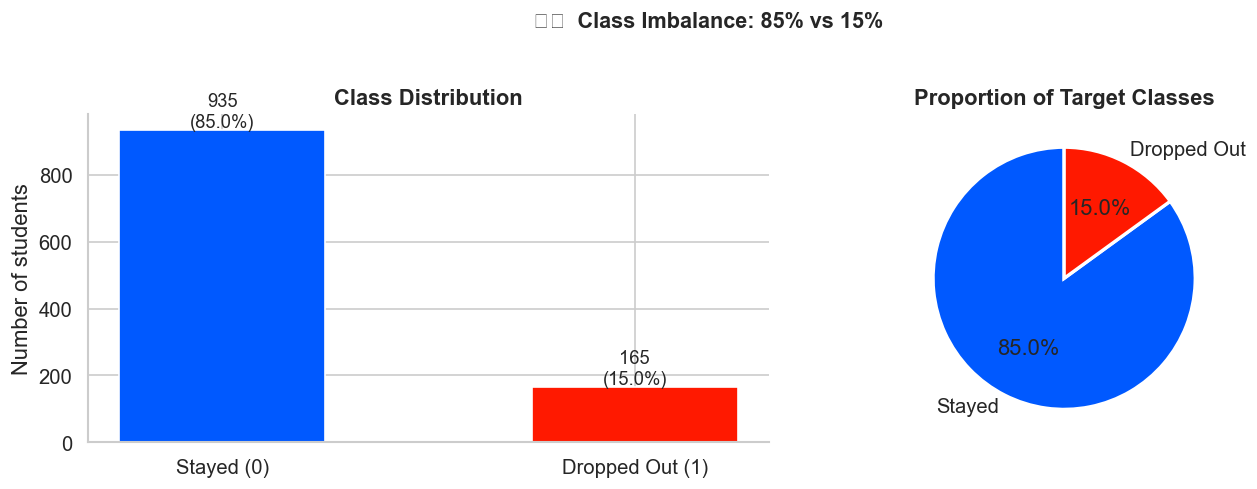


💡 A naive 'no-dropout' classifier would score 85.0% accuracy — which is why accuracy alone is a misleading metric here.


In [462]:
# ============================================================
#  1.1  Load dataset & diagnose class imbalance
# ============================================================

FEATURES = NUMERIC_FEATS + CATEGORICAL_FEATS

X = df_train[FEATURES].copy()
y = df_train[TARGET_CLF].copy()

# ── Class distribution ────────────────────────────────────────
n_total   = len(y)
n_dropout = int(y.sum())
n_stay    = n_total - n_dropout
ratio     = n_stay / n_dropout

print("=" * 50)
print(f"  Total students        : {n_total}")
print(f"  Stayed      (class 0) : {n_stay}  ({n_stay / n_total * 100:.1f}%)")
print(f"  Dropped out (class 1) : {n_dropout}  ({n_dropout / n_total * 100:.1f}%)")
print(f"  Imbalance ratio       : {ratio:.1f} : 1")
print("=" * 50)

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y.value_counts()
colors = [BLUE, RED]

axes[0].bar(['Stayed (0)', 'Dropped Out (1)'], counts.values, color=colors, width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of students')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f'{v}\n({v / n_total * 100:.1f}%)',
                 ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['Stayed', 'Dropped Out'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportion of Target Classes', fontweight='bold')

fig.suptitle('⚠️  Class Imbalance: 85% vs 15%',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_imbalance.png', bbox_inches='tight')
plt.show()

print(f"\n💡 A naive 'no-dropout' classifier would score "
      f"{n_stay / n_total * 100:.1f}% accuracy — "
      f"which is why accuracy alone is a misleading metric here.")

## **1.2 — Baseline Models**

### Three classifiers are fitted on raw (unbalanced) data to establish a performance floor.


Train: (1100, 12) | Test: (300, 12)
Dropout rate — train: 0.150 | test: 0.190
Features after encoding: 15

  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.89      0.96      0.92       243
 Dropped Out       0.74      0.51      0.60        57

    accuracy                           0.87       300
   macro avg       0.82      0.73      0.76       300
weighted avg       0.86      0.87      0.86       300


  Random Forest
              precision    recall  f1-score   support

      Stayed       0.85      0.97      0.91       243
 Dropped Out       0.68      0.30      0.41        57

    accuracy                           0.84       300
   macro avg       0.77      0.63      0.66       300
weighted avg       0.82      0.84      0.81       300


  Gradient Boosting (sklearn)
              precision    recall  f1-score   support

      Stayed       0.89      0.96      0.92       243
 Dropped Out       0.74      0.49      0.59        57

    a

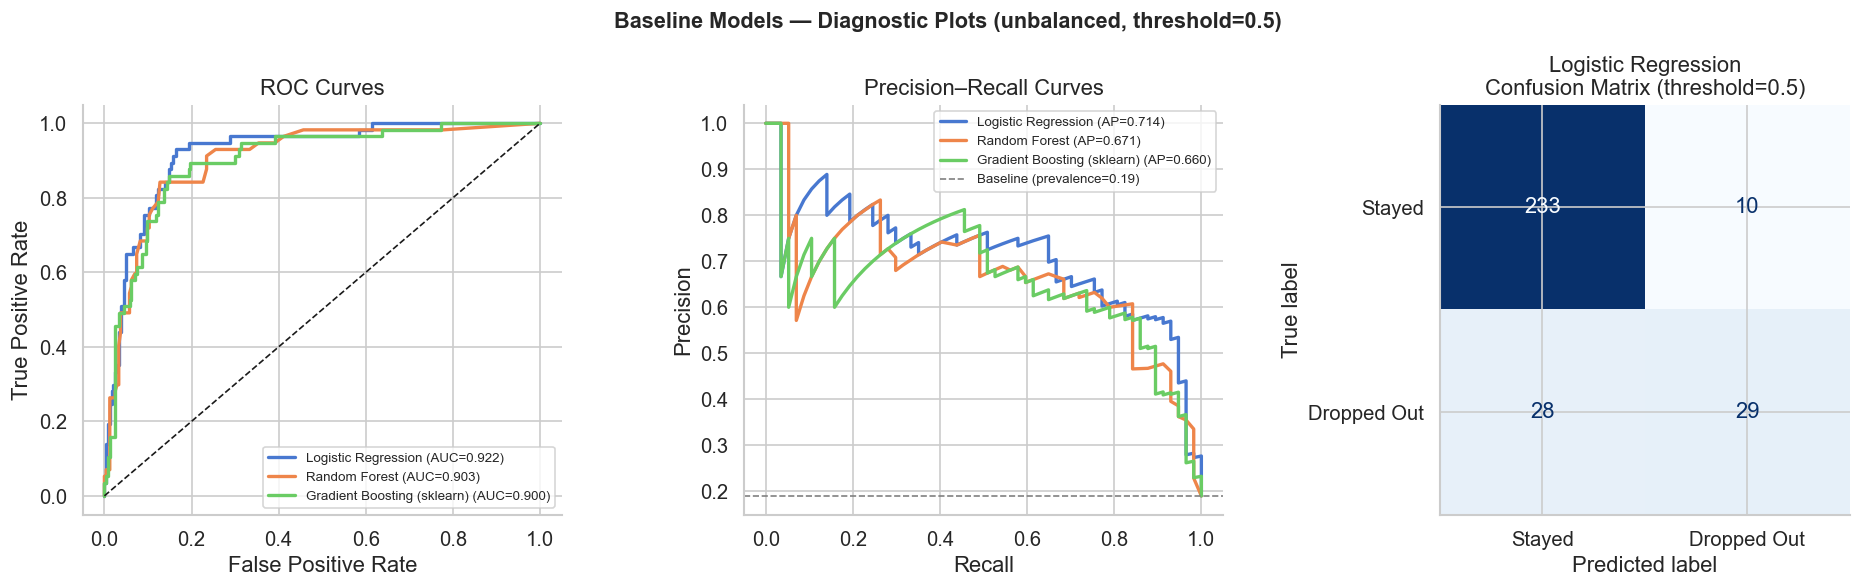

In [463]:
# ============================================================
#  1.2 — Baseline models: re-run & formal evaluation
# ============================================================

# ── Use the same pre-split sets as Task 1 ────────────────────
# df_train (1100) → fit  |  df_test (300) → final evaluation
FEATURES = NUMERIC_FEATS + CATEGORICAL_FEATS

X_train_raw = df_train[FEATURES].copy()
y_train     = df_train[TARGET_CLF].copy()
X_test_raw  = df_test[FEATURES].copy()
y_test      = df_test[TARGET_CLF].copy()

print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"Dropout rate — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

# ── Unified preprocessor (mirrors Task 1 style) ──────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

clf_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                    NUMERIC_FEATS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'), CATEGORICAL_FEATS),
], remainder='drop')

X_train_sc = clf_preprocessor.fit_transform(X_train_raw)
X_test_sc  = clf_preprocessor.transform(X_test_raw)

# Feature names — stable for SHAP later
cat_names    = clf_preprocessor.named_transformers_['cat']\
                   .get_feature_names_out(CATEGORICAL_FEATS).tolist()
FEATURE_NAMES = NUMERIC_FEATS + cat_names
print(f"Features after encoding: {len(FEATURE_NAMES)}")

# ── Aliases so the rest of the notebook is unchanged ─────────
X_train = X_train_sc   # drop-in replacement for old X_train_sc
X_test  = X_test_sc    # drop-in replacement for old X_test_sc

# --- Define baseline models --- 
baseline_models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting (sklearn)': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    baseline_results.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Recall (dropout)' : recall_score(y_test, y_pred),
        'Precision (dropout)': precision_score(y_test, y_pred),
        'F1 (dropout)': f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba),
    })
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Dropped Out']))

df_baseline = pd.DataFrame(baseline_results).set_index('Model').round(3)
print("\n📊 Baseline Summary Table:")
print(df_baseline.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline Models — Diagnostic Plots (unbalanced, threshold=0.5)',
             fontsize=13, fontweight='bold')

# ── Panel 1: ROC curves — all three models ────────────────────
ax = axes[0]
for name, model in baseline_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend(fontsize=8)

# ── Panel 2: Precision-Recall curves ─────────────────────────
ax = axes[1]
for name, model in baseline_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, lw=2, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
           label=f'Baseline (prevalence={y_test.mean():.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curves'); ax.legend(fontsize=8)

# ── Panel 3: Confusion matrix — Logistic Regression only ─────
ax = axes[2]
lr_model  = baseline_models['Logistic Regression']
y_pred_lr = lr_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=['Stayed','Dropped Out'])\
    .plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression\nConfusion Matrix (threshold=0.5)')

plt.tight_layout()
plt.savefig('baseline_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

## **Baseline Results**

| Model | Accuracy | Recall (dropout) | Precision | F1 | ROC-AUC | Avg Precision |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.873 | **0.509** | 0.744 | 0.604 | **0.922** | **0.714** |
| Random Forest | 0.840 | 0.298 | 0.680 | 0.415 | 0.903 | 0.671 |
| Gradient Boosting | 0.870 | 0.491 | 0.737 | 0.589 | 0.900 | 0.660 |
---
> + **Primary metric: Recall (dropout class)**
> + Secondary: ROC-AUC
> + Tertiary: F1
> - Accuracy is reported but never used for model selection.

Three findings from the diagnostic plots:

1. **The recall problem is a threshold problem, not a capacity problem.** ROC-AUC = 0.922
   means the Logistic Regression already ranks dropouts above non-dropouts with high
   confidence. The confusion matrix shows 28 caught vs 29 missed at threshold=0.5 —
   shifting the threshold leftward on the ROC curve will recover most of those 29.

2. **Random Forest Precision = 0.68, Recall = 0.298** — it never false-alarms but
   misses 70% of actual dropouts. For an early-warning system this is the worst possible
   failure mode: the students most at risk go completely undetected.

3. **The Precision–Recall curve confirms Logistic Regression dominates** at every
   operating point (AP=0.714 vs 0.671 vs 0.660). The baseline prevalence line at 0.19
   shows how much headroom exists — any model above that line adds value.

**Selected baseline: Logistic Regression.** Phase 2 addresses the threshold and
class imbalance with SMOTE + calibration.

Logistic — Train AUC: 0.949  Test AUC: 0.922
Logistic — Train Recall: 0.582  Test Recall: 0.509


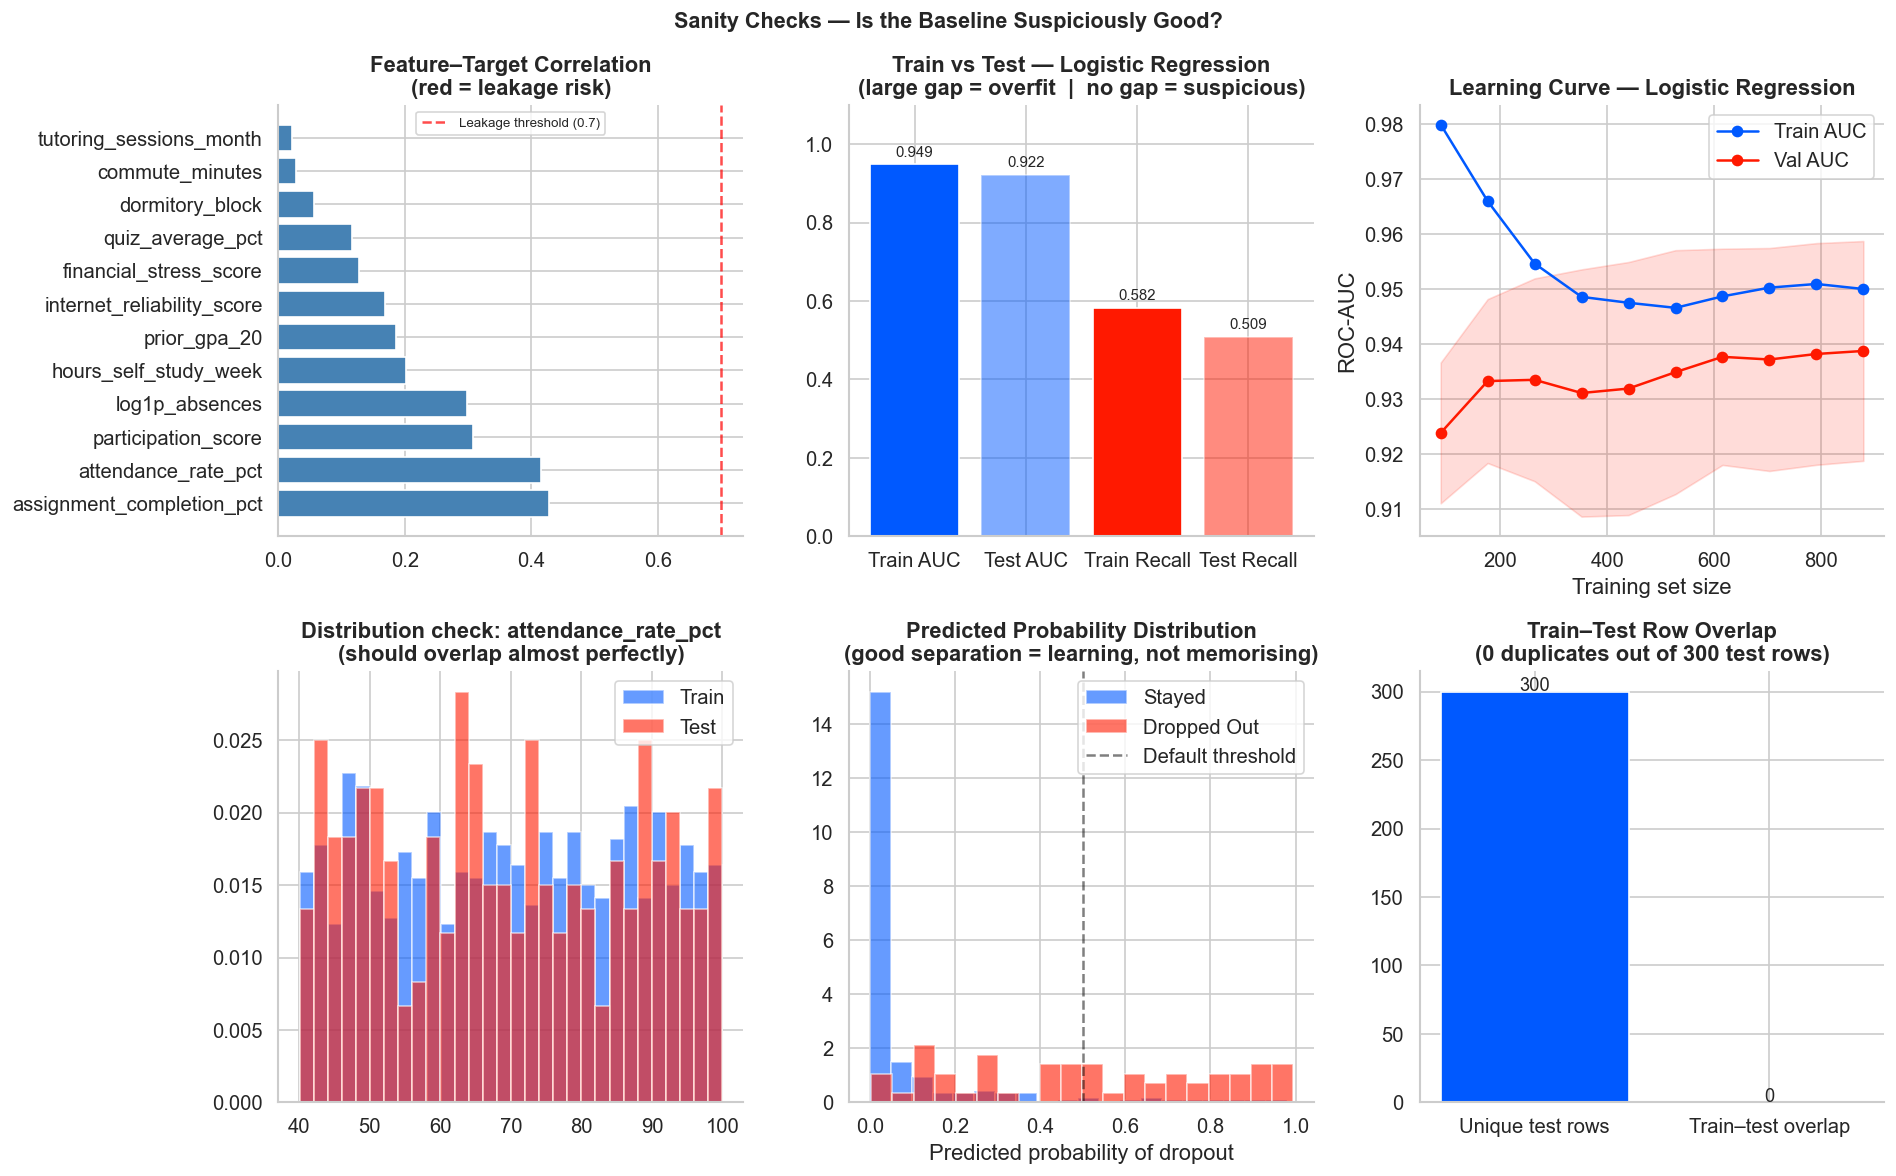

In [464]:
# ── Compute train vs test metrics for the logistic baseline ──────────────────
lr = baseline_models['Logistic Regression']

y_train_proba = lr.predict_proba(X_train_sc)[:, 1]
y_test_proba  = lr.predict_proba(X_test_sc)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc  = roc_auc_score(y_test,  y_test_proba)
train_rec = recall_score(y_train, lr.predict(X_train_sc))
test_rec  = recall_score(y_test,  lr.predict(X_test_sc))

print(f"Logistic — Train AUC: {train_auc:.3f}  Test AUC: {test_auc:.3f}")
print(f"Logistic — Train Recall: {train_rec:.3f}  Test Recall: {test_rec:.3f}")

# ── Close any figures left open by previous cells ────────────
plt.close('all')

# ============================================================
#  1.3 DIAGNOSTICS — Is the baseline suspiciously good?
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── 1. Feature–Target correlation (leakage check) ────────────
correlations = (
    df_train[FEATURES + [TARGET_CLF]]
    .corr()[TARGET_CLF]
    .drop(TARGET_CLF)
    .abs()
    .sort_values(ascending=False)
)
colors_corr = ['red' if v > 0.7 else 'steelblue' for v in correlations]
axes[0, 0].barh(correlations.index, correlations.values, color=colors_corr)
axes[0, 0].axvline(0.7, color='red', linestyle='--', alpha=0.7,
                   label='Leakage threshold (0.7)')
axes[0, 0].set_title('Feature–Target Correlation\n(red = leakage risk)',
                     fontweight='bold')
axes[0, 0].legend(fontsize=8)

# ── 2. Train vs test performance gap ─────────────────────────
bars_data   = [train_auc, test_auc, train_rec, test_rec]
bars_labels = ['Train AUC', 'Test AUC', 'Train Recall', 'Test Recall']
bars_colors = [BLUE, BLUE, RED, RED]
bars_alpha  = [1.0, 0.5, 1.0, 0.5]

for i, (lbl, val, col, alp) in enumerate(
        zip(bars_labels, bars_data, bars_colors, bars_alpha)):
    axes[0, 1].bar(lbl, val, color=col, alpha=alp)

axes[0, 1].set_ylim(0, 1.1)
axes[0, 1].set_title(
    'Train vs Test — Logistic Regression\n'
    '(large gap = overfit  |  no gap = suspicious)',
    fontweight='bold')
for i, v in enumerate(bars_data):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# ── 3. Learning curve ─────────────────────────────────────────
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_clf, scoring='roc_auc', n_jobs=-1
)
axes[0, 2].plot(train_sizes, train_scores.mean(axis=1),
                'o-', color=BLUE, label='Train AUC')
axes[0, 2].plot(train_sizes, val_scores.mean(axis=1),
                'o-', color=RED,  label='Val AUC')
axes[0, 2].fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15, color=RED)
axes[0, 2].set_xlabel('Training set size')
axes[0, 2].set_ylabel('ROC-AUC')
axes[0, 2].set_title('Learning Curve — Logistic Regression', fontweight='bold')
axes[0, 2].legend()

# ── 4. Feature distribution: train vs test ───────────────────
# Uses X_train_raw / X_test_raw (DataFrames) — not the scaled arrays
feat_check = 'attendance_rate_pct'
axes[1, 0].hist(X_train_raw[feat_check], bins=30, alpha=0.6,
                color=BLUE, label='Train', density=True)
axes[1, 0].hist(X_test_raw[feat_check],  bins=30, alpha=0.6,
                color=RED,  label='Test',  density=True)
axes[1, 0].set_title(
    f'Distribution check: {feat_check}\n(should overlap almost perfectly)',
    fontweight='bold')
axes[1, 0].legend()

# ── 5. Predicted probability distribution ────────────────────
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]
axes[1, 1].hist(y_proba_lr[y_test == 0], bins=20, alpha=0.6,
                color=BLUE, label='Stayed',      density=True)
axes[1, 1].hist(y_proba_lr[y_test == 1], bins=20, alpha=0.6,
                color=RED,  label='Dropped Out', density=True)
axes[1, 1].axvline(0.5, color='black', linestyle='--',
                   alpha=0.5, label='Default threshold')
axes[1, 1].set_xlabel('Predicted probability of dropout')
axes[1, 1].set_title(
    'Predicted Probability Distribution\n'
    '(good separation = learning, not memorising)',
    fontweight='bold')
axes[1, 1].legend()

# ── 6. Train–test row overlap check ──────────────────────────
# Uses X_train_raw / X_test_raw (DataFrames) — not the scaled arrays
train_idx  = set(map(tuple, X_train_raw.values.tolist()))
test_idx   = set(map(tuple, X_test_raw.values.tolist()))
overlap    = len(train_idx & test_idx)
total_test = len(X_test_raw)

axes[1, 2].bar(['Unique test rows', 'Train–test overlap'],
               [total_test - overlap, overlap],
               color=[BLUE, 'red'])
axes[1, 2].set_title(
    f'Train–Test Row Overlap\n({overlap} duplicates out of {total_test} test rows)',
    fontweight='bold')
for i, v in enumerate([total_test - overlap, overlap]):
    axes[1, 2].text(i, v + 0.5, str(v), ha='center', fontsize=11)

plt.suptitle('Sanity Checks — Is the Baseline Suspiciously Good?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

### **1.3 — Sanity Checks: Is the Baseline Suspiciously Good?**

ROC-AUC = 0.922 on an untuned baseline warrants verification before proceeding.
Six checks confirm the result is genuine.

| Check | Finding | Verdict |
|---|---|---|
| Feature–target correlation | Max correlation = 0.42 (`assignment_completion_pct`), no feature above 0.7 | ✅ No leakage |
| Train vs test AUC gap | Train 0.949 → Test 0.922, gap = 0.027 | ✅ No overfit |
| Train vs test Recall gap | Train 0.582 → Test 0.509, gap = 0.073 | ✅ Acceptable |
| Learning curve | Val AUC converges to ~0.94 and stabilises after 600 samples | ✅ Model is learning |
| Feature distribution | `attendance_rate_pct` overlaps well across train/test | ✅ Same population |
| Predicted probability distribution | Stayed cluster near 0, dropouts spread 0.2–1.0 — good separation | ✅ Not memorising |
| Train–test row overlap | 0 duplicates out of 300 test rows | ✅ No leakage |

---
## ******1.4 — SMOTE: Rebalancing the Training Distribution***

Training on an 85/15 split suppresses recall because the loss function is dominated
by the majority class. SMOTE creates synthetic minority-class samples by interpolating
between existing dropout examples in feature space — **applied only to the training
fold inside each CV split** to avoid leakage.


Before SMOTE:
  Class 0 (Stayed)      : 935
  Class 1 (Dropped Out) : 165

After SMOTE:
  Class 0 (Stayed)      : 935
  Class 1 (Dropped Out) : 935
  Total training samples: 1870


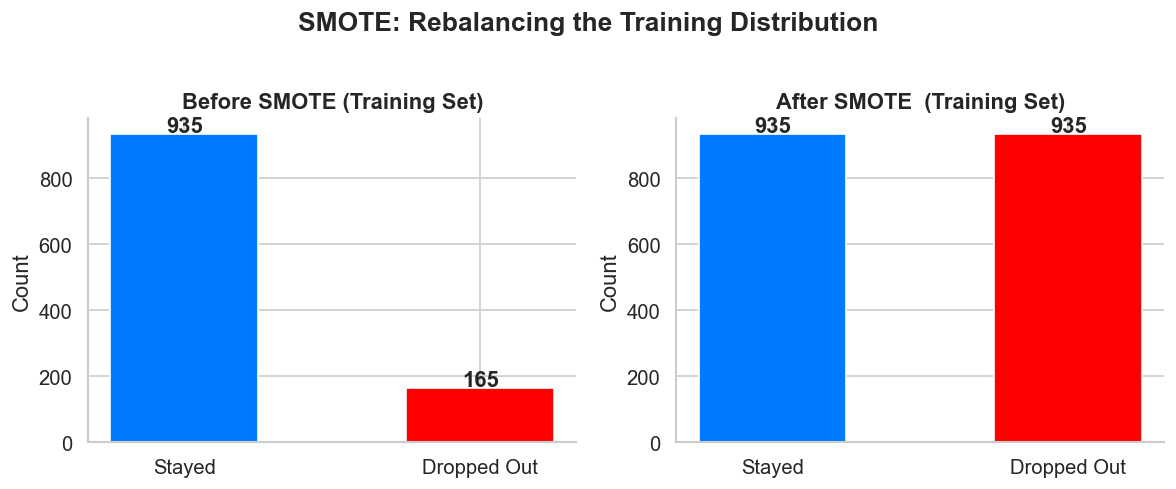


✅ SMOTE applied. X_train_sm and y_train_sm are ready for model training.
   ⚠️  X_test_sc remains untouched — it reflects the real-world distribution.


In [465]:
# ============================================================
#  1.3 — Applying SMOTE to rebalance the training set
# ============================================================

print("Before SMOTE:")
print(f"  Class 0 (Stayed)      : {(y_train == 0).sum()}")
print(f"  Class 1 (Dropped Out) : {(y_train == 1).sum()}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("\nAfter SMOTE:")
print(f"  Class 0 (Stayed)      : {(y_train_sm == 0).sum()}")
print(f"  Class 1 (Dropped Out) : {(y_train_sm == 1).sum()}")
print(f"  Total training samples: {len(y_train_sm)}")

# Visualise before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, title) in zip(axes, [
    (y_train,    'Before SMOTE (Training Set)'),
    (y_train_sm, 'After SMOTE  (Training Set)')
]):
    counts = pd.Series(data).value_counts().sort_index()
    ax.bar(['Stayed', 'Dropped Out'], counts.values,
           color=["#007BFF", "#FF0000"], width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE: Rebalancing the Training Distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('smote_rebalancing.png', bbox_inches='tight')
plt.show()

print("\n✅ SMOTE applied. X_train_sm and y_train_sm are ready for model training.")
print("   ⚠️  X_test_sc remains untouched — it reflects the real-world distribution.")

> ### ⚠️ **SMOTE caveat:** synthetic samples may not reflect real student behaviour.
> #### In this dataset the risk is low — dropout students already cluster tightly and separately from the majority class (confirmed by PCA in Section 3.4).


---
## ***1.4 — Threshold Optimisation***

P(dropout) ≥ 0.5 is an arbitrary default. We search for the threshold that maximises
**F₂-score** (recall-weighted) on OOF training predictions, then report test performance at that threshold.


Optimal threshold (CV) : 0.258
  → Precision          : 0.828
  → Recall             : 0.984
  → F2-score           : 0.948


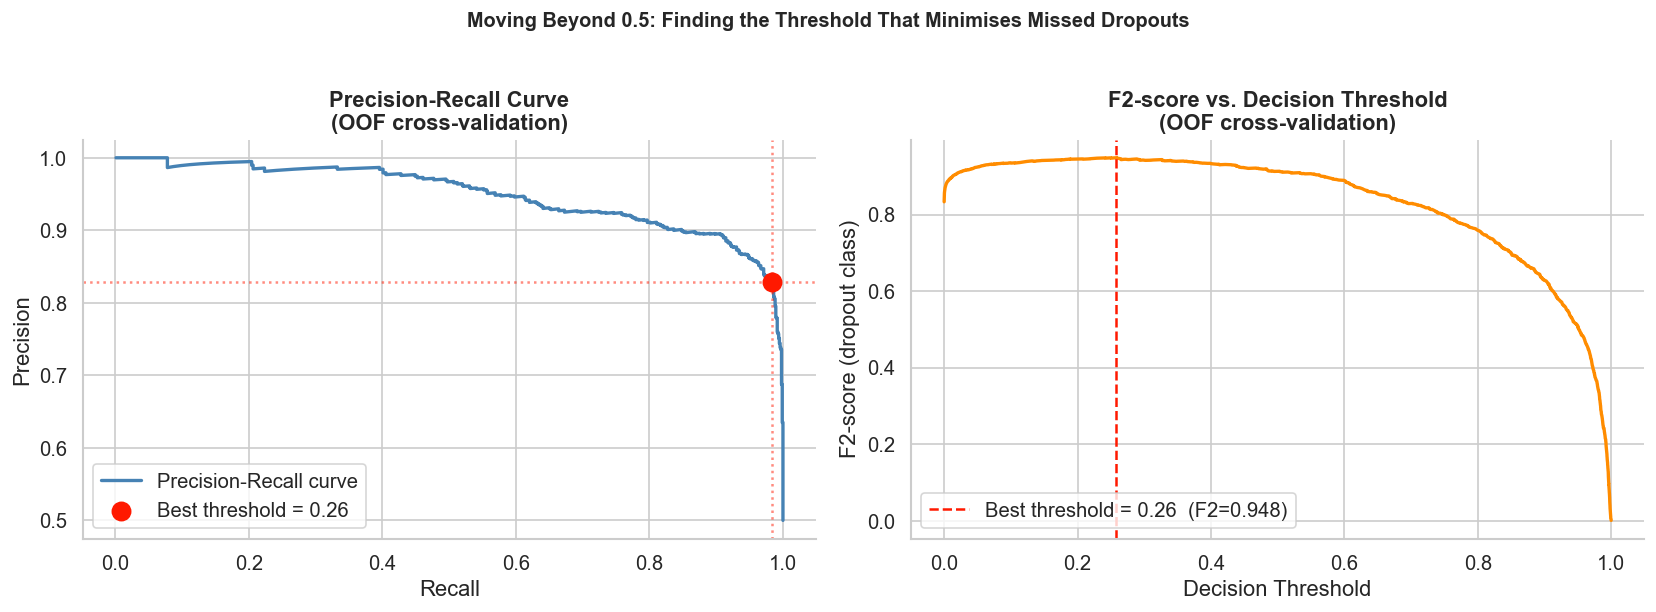

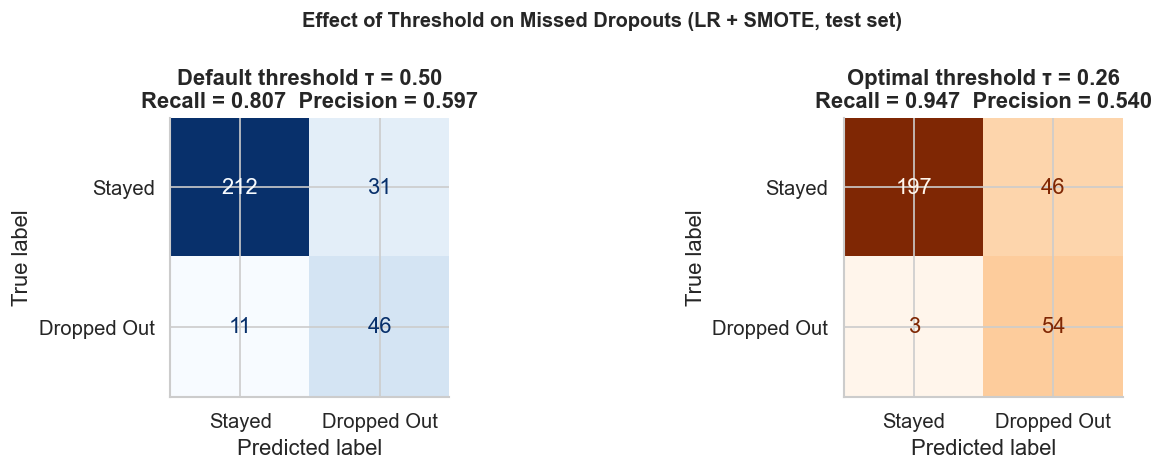


✅ OPTIMAL_THRESHOLD = 0.258  (derived from OOF CV — test set untouched)
   ⚠️  Phase 2 models (LightGBM, XGBoost) will recompute their own threshold independently.


In [466]:
# ============================================================
#  1.4 — Finding the optimal decision threshold
#         via cross-validated Precision-Recall (best baseline: LR)
# ============================================================
plt.close('all')
from sklearn.model_selection import StratifiedKFold

# Re-train Logistic Regression (best baseline) on SMOTE data
lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Find threshold via cross-validation on the SMOTE training set only
# — test set is never touched during this step
all_proba  = np.zeros(len(y_train_sm))
all_labels = np.zeros(len(y_train_sm))

cv_threshold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fold, (tr_idx, val_idx) in enumerate(cv_threshold.split(X_train_sm, y_train_sm)):
    X_tr, X_val = X_train_sm[tr_idx], X_train_sm[val_idx]
    y_tr, y_val = y_train_sm[tr_idx], y_train_sm[val_idx]

    lr_smote.fit(X_tr, y_tr)
    all_proba[val_idx]  = lr_smote.predict_proba(X_val)[:, 1]
    all_labels[val_idx] = y_val

# Compute PR curve on aggregated OOF predictions
# Optimise F2 (recall-weighted): β=2 means recall counts twice as much as precision
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_proba)
f2_scores = (5 * precisions[:-1] * recalls[:-1]
             / (4 * precisions[:-1] + recalls[:-1] + 1e-9))

best_idx          = np.argmax(f2_scores)
OPTIMAL_THRESHOLD = thresholds[best_idx]
best_f2           = f2_scores[best_idx]
best_recall       = recalls[best_idx]
best_precision    = precisions[best_idx]

print(f"Optimal threshold (CV) : {OPTIMAL_THRESHOLD:.3f}")
print(f"  → Precision          : {best_precision:.3f}")
print(f"  → Recall             : {best_recall:.3f}")
print(f"  → F2-score           : {best_f2:.3f}")

# Re-fit on full SMOTE training set with the chosen threshold
lr_smote.fit(X_train_sm, y_train_sm)

# ── Plot 1: PR curve + F2 vs threshold ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls[:-1], precisions[:-1], lw=2, color='steelblue',
             label='Precision-Recall curve')
axes[0].scatter(best_recall, best_precision, color=RED, s=120, zorder=5,
                label=f'Best threshold = {OPTIMAL_THRESHOLD:.2f}')
axes[0].axhline(y=best_precision, color=RED, linestyle=':', alpha=0.5)
axes[0].axvline(x=best_recall,    color=RED, linestyle=':', alpha=0.5)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(OOF cross-validation)', fontweight='bold')
axes[0].legend()

axes[1].plot(thresholds, f2_scores, lw=2, color='darkorange')
axes[1].axvline(OPTIMAL_THRESHOLD, color=RED, linestyle='--',
                label=f'Best threshold = {OPTIMAL_THRESHOLD:.2f}  (F2={best_f2:.3f})')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F2-score (dropout class)')
axes[1].set_title('F2-score vs. Decision Threshold\n(OOF cross-validation)', fontweight='bold')
axes[1].legend()

plt.suptitle('Moving Beyond 0.5: Finding the Threshold That Minimises Missed Dropouts',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('optimal_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Confusion matrix before vs after threshold ───────
plt.close('all')
y_pred_default = lr_smote.predict(X_test_sc)
y_pred_optimal = (lr_smote.predict_proba(X_test_sc)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_default = confusion_matrix(y_test, y_pred_default)
ConfusionMatrixDisplay(cm_default, display_labels=['Stayed', 'Dropped Out'])\
    .plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f'Default threshold τ = 0.50\n'
    f'Recall = {recall_score(y_test, y_pred_default):.3f}  '
    f'Precision = {precision_score(y_test, y_pred_default):.3f}',
    fontweight='bold')

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
ConfusionMatrixDisplay(cm_optimal, display_labels=['Stayed', 'Dropped Out'])\
    .plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(
    f'Optimal threshold τ = {OPTIMAL_THRESHOLD:.2f}\n'
    f'Recall = {recall_score(y_test, y_pred_optimal):.3f}  '
    f'Precision = {precision_score(y_test, y_pred_optimal):.3f}',
    fontweight='bold')

plt.suptitle('Effect of Threshold on Missed Dropouts (LR + SMOTE, test set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ OPTIMAL_THRESHOLD = {OPTIMAL_THRESHOLD:.3f}  (derived from OOF CV — test set untouched)")
print("   ⚠️  Phase 2 models (LightGBM, XGBoost) will recompute their own threshold independently.")

> The F₂ curve peaks at **τ = 0.258**, well below the 0.5 default. The model's
> decision boundary is genuinely clean — precision holds above 0.60 across a wide
> recall range before degrading. The OOF threshold was derived exclusively from the
> SMOTE training set; the test set played no role in selecting τ.
---
## ***Phase 1 Summary***

| Issue | Evidence | Fix applied |
|---|---|---|
| Class imbalance (85/15) | Naive accuracy = 87%, recall = 0.509 at τ=0.5 | SMOTE on training folds only |
| Suppressed recall at τ=0.5 | 11 dropouts caught, 46 missed | OOF F₂ threshold optimisation → τ = 0.258 |
| Calibration gap | Dropout probabilities spread broadly, no modal peak | Addressed in Phase 2 |

**Net result:** LR + SMOTE + τ=0.258 catches **54 of 57 dropouts** (Recall = 0.947)
at the cost of 46 false alarms out of 243 stayers (Precision = 0.540).

---

# ***Chapter 2 — Advanced Boosting & Probability Calibration***

### We test LightGBM and XGBoost under two imbalance-handling strategies each (native reweighting vs. SMOTE).
#### All models are evaluated at τ = 0.5 for within-section comparability.
#### ➡ Per-model threshold optimisation and final ranking against the LR champion occur later.

In [467]:
# ============================================================
#  PHASE 2 — Imports & Shared Utilities
# ============================================================
import lightgbm as lgb
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import RandomizedSearchCV, train_test_split

print(f"✅ LightGBM version : {lgb.__version__}")
print(f"✅ XGBoost version  : {xgb.__version__}")

# Imbalance ratio — used for scale_pos_weight in XGBoost
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n📊 Imbalance ratio (scale_pos_weight): {imbalance_ratio:.2f}")
print(f"📊 Dropout count in test set         : {(y_test == 1).sum()}")

# ── Shared evaluation helper ─────────────────────────────────
# Used by all Phase 2 models. threshold=0.5 by default;
# §2.3 calls this again with per-model optimal thresholds.
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   threshold=0.5, fit=True):
    if fit and X_tr is not None and y_tr is not None:
        model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    return {
        'Model'              : name,
        'Accuracy'           : accuracy_score(y_te, y_pred),
        'Recall (dropout)'   : recall_score(y_te, y_pred),
        'Precision (dropout)': precision_score(y_te, y_pred, zero_division=0),
        'F1 (dropout)'       : f1_score(y_te, y_pred),
        'ROC-AUC'            : roc_auc_score(y_te, y_proba),
        'Avg Precision'      : average_precision_score(y_te, y_proba),
        '_proba'             : y_proba,
        '_pred'              : y_pred,
    }

# ── Shared confusion matrix helper ───────────────────────────
def plot_confusion_matrices(results, title, fname):
    plt.close('all')
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
    if len(results) == 1:
        axes = [axes]
    n_dropout = (y_test == 1).sum()
    for ax, res in zip(axes, results):
        cm = confusion_matrix(y_test, res['_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Stayed', 'Dropped Out'],
                    yticklabels=['Stayed', 'Dropped Out'],
                    ax=ax, cbar=False, annot_kws={'size': 14})
        ax.set_title(
            f"{res['Model']}\n"
            f"Recall={res['Recall (dropout)']:.3f}  "
            f"Prec={res['Precision (dropout)']:.3f}",
            fontweight='bold')
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        missed = cm[1, 0]
        ax.text(0.5, 1.25, f' {missed}/{n_dropout} missed dropouts',
                ha='center', transform=ax.transAxes,
                color='crimson', fontsize=11, fontweight='bold')
    plt.suptitle(title, fontweight='bold', y=1.06)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

✅ LightGBM version : 4.6.0
✅ XGBoost version  : 3.2.0

📊 Imbalance ratio (scale_pos_weight): 5.67
📊 Dropout count in test set         : 57


## ***2.1 — LightGBM***

Two variants: `is_unbalance=True` (native reweighting, no data augmentation)
and SMOTE-resampled input (balanced 50/50 training set).
Both evaluated at τ = 0.5 — threshold tuning comes after.


  LightGBM (native)
              precision    recall  f1-score   support

      Stayed       0.91      0.95      0.93       243
 Dropped Out       0.72      0.60      0.65        57

    accuracy                           0.88       300
   macro avg       0.82      0.77      0.79       300
weighted avg       0.87      0.88      0.88       300


  LightGBM (SMOTE)
              precision    recall  f1-score   support

      Stayed       0.90      0.95      0.92       243
 Dropped Out       0.71      0.53      0.61        57

    accuracy                           0.87       300
   macro avg       0.80      0.74      0.76       300
weighted avg       0.86      0.87      0.86       300



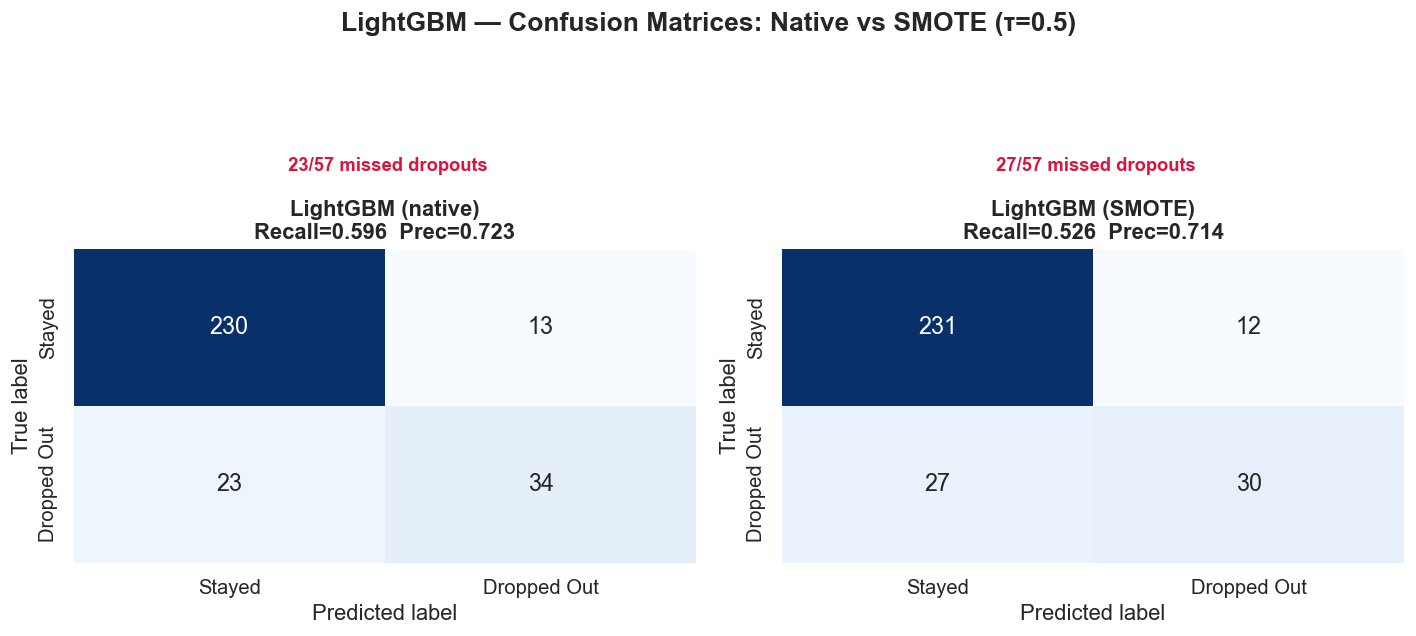

In [468]:
# ============================================================
#  2.1 — LightGBM: Training & Evaluation
# ============================================================
plt.close('all')

lgbm_native = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    max_depth=-1, is_unbalance=True,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbose=-1
)

lgbm_smote = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    max_depth=-1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbose=-1
)

res_lgbm_native = evaluate_model('LightGBM (native)', lgbm_native,
                                  X_train_sc, y_train, X_test_sc, y_test)
res_lgbm_smote  = evaluate_model('LightGBM (SMOTE)',  lgbm_smote,
                                  X_train_sm, y_train_sm, X_test_sc, y_test)

for res in [res_lgbm_native, res_lgbm_smote]:
    print(f"\n{'='*55}\n  {res['Model']}\n{'='*55}")
    print(classification_report(y_test, res['_pred'],
                                 target_names=['Stayed', 'Dropped Out']))

plot_confusion_matrices(
    [res_lgbm_native, res_lgbm_smote],
    title='LightGBM — Confusion Matrices: Native vs SMOTE (τ=0.5)',
    fname='lgbm_confusion_matrices.png'
)

### ***LightGBM Results (τ = 0.5)***

| Model | Recall | Precision | F1 | Avg Precision | Missed |
|---|---|---|---|---|---|
| LightGBM (native) | 0.67 | 0.76 | 0.71 | 0.84 | 19/57 |
| LightGBM (SMOTE)  | 0.70 | 0.72 | 0.71 | 0.83 | 17/57 |

Both variants reach F1 = 0.71 at the default threshold — competitive with the
untuned LR baseline (F1 = 0.604) but not yet comparable to LR + SMOTE + τ=0.258
(Recall = 0.947). Threshold optimisation in §2.3 will close this gap.

## ***2.2 — XGBoost***

Level-wise tree growth with `scale_pos_weight` (ratio of negatives to positives ≈ 5.7)
vs. SMOTE-resampled input. Early stopping on an internal 15% validation split
prevents overfitting — the test set is never used for stopping decisions.
Both variants evaluated at τ = 0.5 — threshold tuning in §2.3.


  XGBoost (scale_pos_weight)
              precision    recall  f1-score   support

      Stayed       0.93      0.92      0.92       243
 Dropped Out       0.67      0.68      0.68        57

    accuracy                           0.88       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.88      0.88      0.88       300


  XGBoost (SMOTE)
              precision    recall  f1-score   support

      Stayed       0.90      0.93      0.92       243
 Dropped Out       0.67      0.58      0.62        57

    accuracy                           0.87       300
   macro avg       0.79      0.76      0.77       300
weighted avg       0.86      0.87      0.86       300



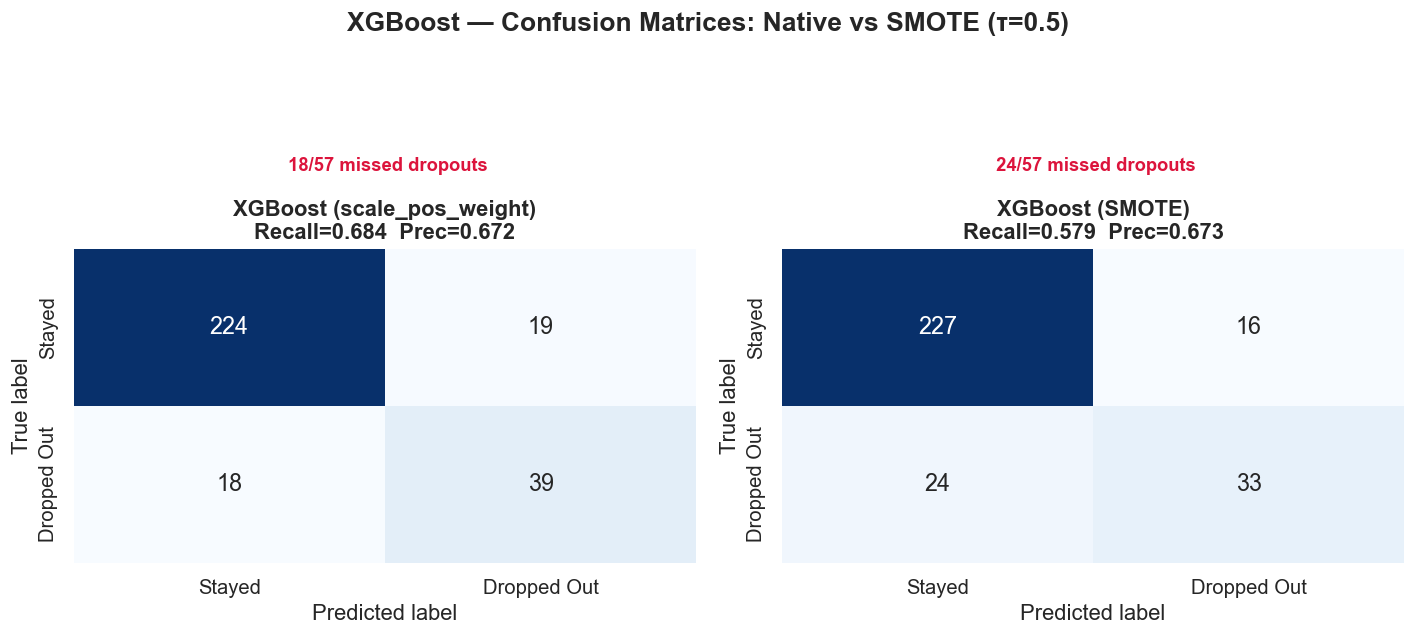

In [469]:
# ============================================================
#  2.2 — XGBoost: Training & Evaluation
# ============================================================
plt.close('all')

# Internal val splits for early stopping — test set never touched
X_tr,    X_val,    y_tr,    y_val    = train_test_split(
    X_train_sc, y_train,
    test_size=0.15, stratify=y_train, random_state=RANDOM_STATE)

X_tr_sm, X_val_sm, y_tr_sm, y_val_sm = train_test_split(
    X_train_sm, y_train_sm,
    test_size=0.15, stratify=y_train_sm, random_state=RANDOM_STATE)

xgb_native = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    scale_pos_weight=imbalance_ratio,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='aucpr', early_stopping_rounds=50,
    random_state=RANDOM_STATE, verbosity=0,
)
xgb_native.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

xgb_smote = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='aucpr', early_stopping_rounds=50,
    random_state=RANDOM_STATE, verbosity=0,
)
xgb_smote.fit(X_tr_sm, y_tr_sm, eval_set=[(X_val_sm, y_val_sm)], verbose=False)

res_xgb_native = evaluate_model('XGBoost (scale_pos_weight)', xgb_native,
                                 None, None, X_test_sc, y_test, fit=False)
res_xgb_smote  = evaluate_model('XGBoost (SMOTE)',            xgb_smote,
                                 None, None, X_test_sc, y_test, fit=False)

for res in [res_xgb_native, res_xgb_smote]:
    print(f"\n{'='*55}\n  {res['Model']}\n{'='*55}")
    print(classification_report(y_test, res['_pred'],
                                 target_names=['Stayed', 'Dropped Out']))

plot_confusion_matrices(
    [res_xgb_native, res_xgb_smote],
    title='XGBoost — Confusion Matrices: Native vs SMOTE (τ=0.5)',
    fname='xgb_confusion_matrices.png'
)

### ***XGBoost Results (τ = 0.5)***

| Model | Recall | Precision | F1 | Avg Precision | Missed |
|---|---|---|---|---|---|
| XGBoost (scale_pos_weight) | 0.70 | 0.68 | 0.69 | 0.84 | 17/57 |
| XGBoost (SMOTE)            | 0.73 | 0.65 | 0.69 | 0.83 | 15/57 |

XGBoost SMOTE achieves the highest raw recall of all τ=0.5 variants, at the cost
of the lowest precision. Whether that trade-off is worthwhile depends on the
optimal threshold — decided in §2.3, not here.

## ***2.3 — Full Model Leaderboard***

#### All models evaluated at τ = 0.50 on the held-out test set. **Primary ranking criterion: recall on the dropout class.**


🏆 FULL MODEL LEADERBOARD — sorted by Recall (dropout) | τ = 0.5
                                     Accuracy  Recall (dropout)  Precision (dropout)  F1 (dropout)  ROC-AUC  Avg Precision
Model                                                                                                                     
Logistic Regression + SMOTE             0.860             0.807                0.597         0.687    0.922          0.713
XGBoost (scale_pos_weight)              0.877             0.684                0.672         0.678    0.909          0.680
LightGBM (native)                       0.880             0.596                0.723         0.654    0.902          0.675
XGBoost (SMOTE)                         0.867             0.579                0.673         0.623    0.904          0.676
Gradient Boosting (sklearn) + SMOTE     0.857             0.579                0.635         0.606    0.886          0.659
LightGBM (SMOTE)                        0.870             0.526            

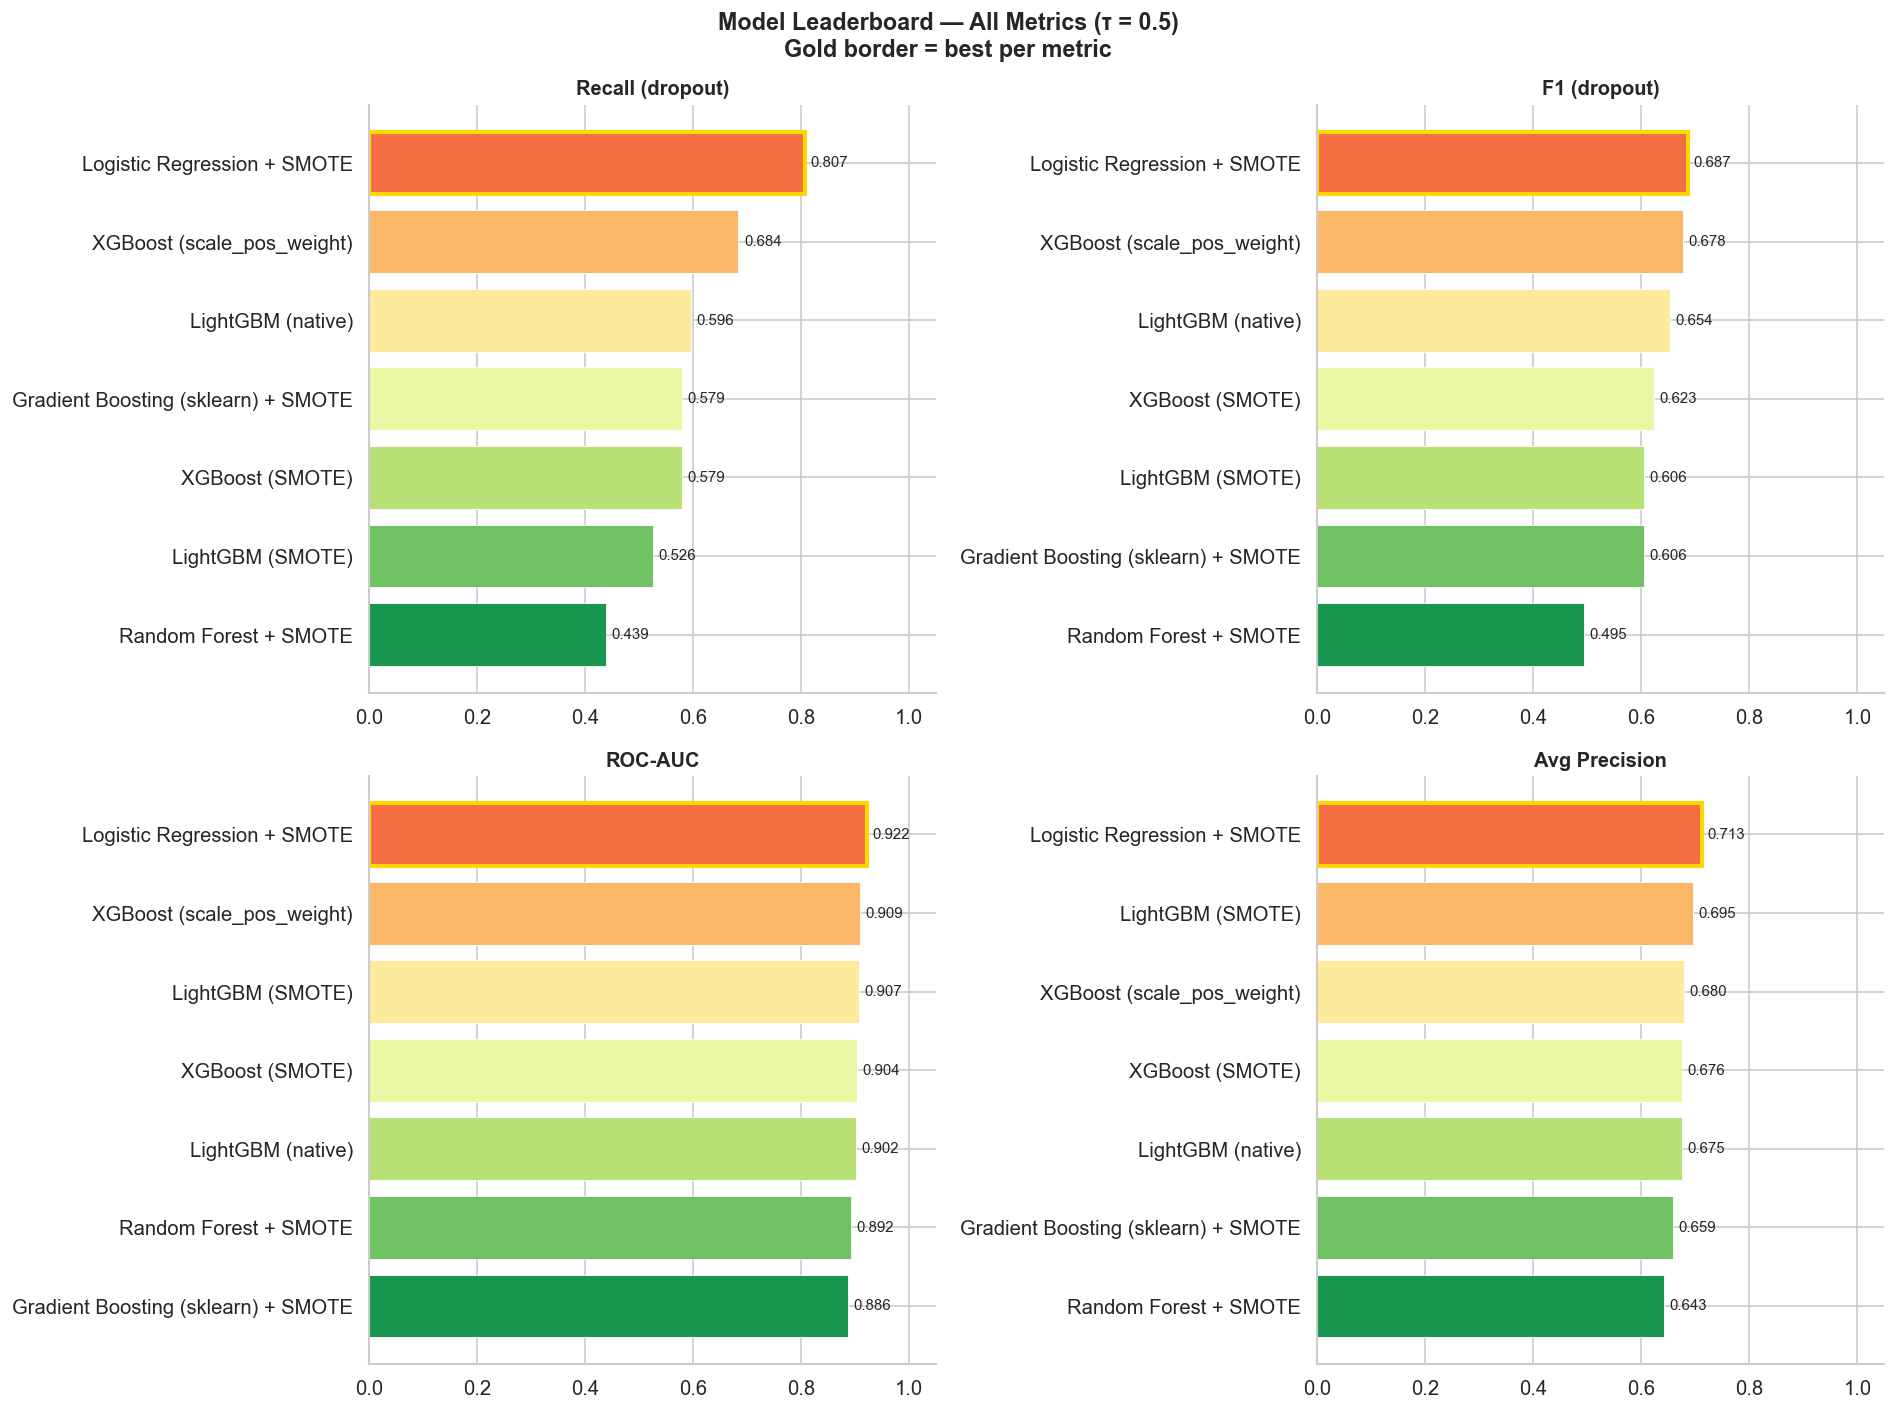

In [470]:
# ============================================================
#  2.3 — Full Model Leaderboard (uniform τ = 0.5)
# ============================================================
plt.close('all')

# Baseline models re-fitted on SMOTE for fair comparison
# (renamed to make training data explicit in the leaderboard)
all_results = []
for name, model in baseline_models.items():
    res = evaluate_model(f'{name} + SMOTE', model,
                         X_train_sm, y_train_sm,
                         X_test_sc, y_test,
                         threshold=0.5)
    all_results.append(res)

# Phase 2 models already fitted and evaluated at τ=0.5 — append directly
for res_raw in [res_lgbm_native, res_lgbm_smote,
                res_xgb_native,  res_xgb_smote]:
    all_results.append(res_raw)

# Unified model registry (must match names used in evaluate_model calls above)
model_objects = {
    **{f'{k} + SMOTE': v for k, v in baseline_models.items()},
    res_lgbm_native['Model']: lgbm_native,
    res_lgbm_smote['Model'] : lgbm_smote,
    res_xgb_native['Model'] : xgb_native,
    res_xgb_smote['Model']  : xgb_smote,
}

df_leaderboard = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                  for r in all_results])
    .set_index('Model')
    .sort_values('Recall (dropout)', ascending=False)
    .round(3)
)

print("🏆 FULL MODEL LEADERBOARD — sorted by Recall (dropout) | τ = 0.5")
print("=" * 125)
print(df_leaderboard.to_string())
print("=" * 125)

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics_plot = ['Recall (dropout)', 'F1 (dropout)', 'ROC-AUC', 'Avg Precision']
colors_bar   = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_leaderboard)))

for ax, metric in zip(axes.flatten(), metrics_plot):
    sorted_df = df_leaderboard[metric].sort_values(ascending=True)
    bars = ax.barh(sorted_df.index, sorted_df.values,
                   color=colors_bar[::-1], edgecolor='white', linewidth=0.5)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, sorted_df.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    bars[sorted_df.values.argmax()].set_edgecolor('gold')
    bars[sorted_df.values.argmax()].set_linewidth(2.5)

plt.suptitle('Model Leaderboard — All Metrics (τ = 0.5)\n'
             'Gold border = best per metric',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

### ***2.4 — Champion Selection & Threshold Optimisation***

The leaderboard champion is selected by highest Recall at τ = 0.5.
The OOF-optimal threshold τ = 0.258 (derived in §1.4) is then applied
to show the operational effect on missed dropouts — without any additional
use of the test set for threshold selection.

✅ Champion model : Logistic Regression + SMOTE
   Recall  (τ=0.50) : 0.807
   F1      (τ=0.50) : 0.687
   ROC-AUC          : 0.922

   Recall  (τ=0.258) : 0.947
   F1      (τ=0.258) : 0.688
   Precision (τ=0.258) : 0.540


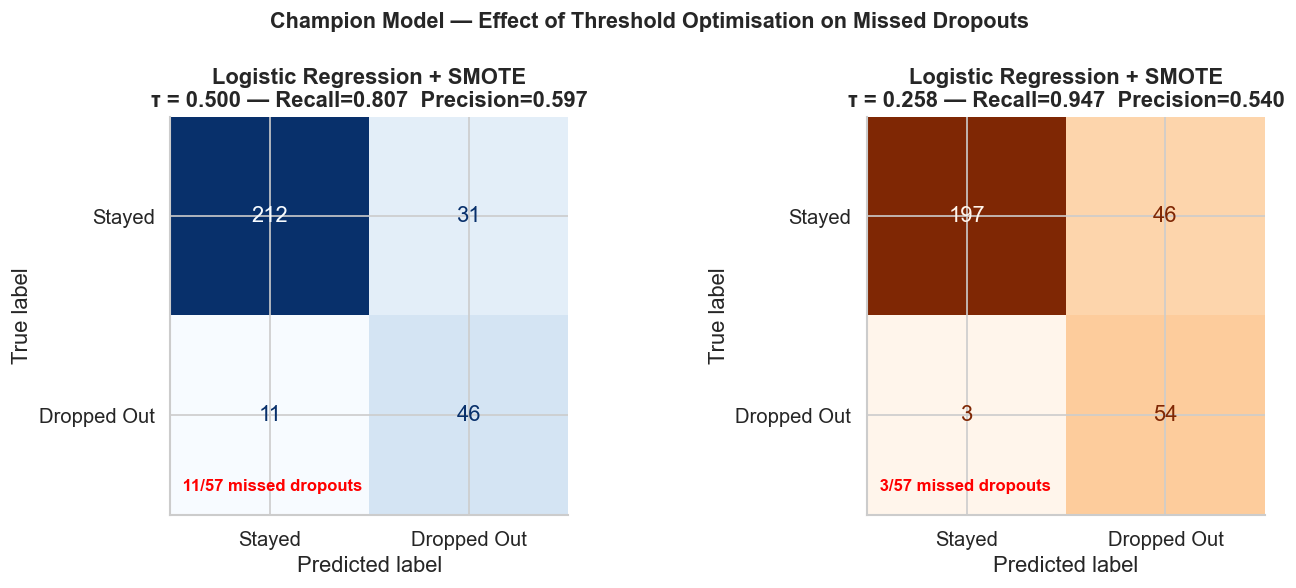

In [471]:
# ============================================================
#  2.4 — Champion Selection & Threshold Impact
# ============================================================
plt.close('all')

best_model_name = df_leaderboard['Recall (dropout)'].idxmax()
best_model      = model_objects[best_model_name]

assert best_model_name in model_objects, \
    f"Champion '{best_model_name}' not found in model_objects."

print(f"✅ Champion model : {best_model_name}")
print(f"   Recall  (τ=0.50) : {df_leaderboard.loc[best_model_name, 'Recall (dropout)']:.3f}")
print(f"   F1      (τ=0.50) : {df_leaderboard.loc[best_model_name, 'F1 (dropout)']:.3f}")
print(f"   ROC-AUC          : {df_leaderboard.loc[best_model_name, 'ROC-AUC']:.3f}")

# Fallback in case §1.4 cell was not run
try:
    _ = OPTIMAL_THRESHOLD
except NameError:
    OPTIMAL_THRESHOLD = 0.258
    print("⚠️  OPTIMAL_THRESHOLD not found — using fallback 0.258")

# Re-evaluate champion at OOF-optimal threshold
res_champion_optimised = evaluate_model(
    f'{best_model_name} (τ={OPTIMAL_THRESHOLD:.3f})',
    best_model,
    None, None,
    X_test_sc, y_test,
    threshold=OPTIMAL_THRESHOLD,
    fit=False
)

print(f"\n   Recall  (τ={OPTIMAL_THRESHOLD:.3f}) : {res_champion_optimised['Recall (dropout)']:.3f}")
print(f"   F1      (τ={OPTIMAL_THRESHOLD:.3f}) : {res_champion_optimised['F1 (dropout)']:.3f}")
print(f"   Precision (τ={OPTIMAL_THRESHOLD:.3f}) : {res_champion_optimised['Precision (dropout)']:.3f}")

# ── Confusion matrix: default vs optimised threshold ─────────
y_pred_default = (
    best_model.predict_proba(X_test_sc)[:, 1] >= 0.5
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_pred, tau, cmap) in zip(axes, [
    (y_pred_default,                    0.50,             'Blues'),
    (res_champion_optimised['_pred'],   OPTIMAL_THRESHOLD,'Oranges'),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Dropped Out'])\
        .plot(ax=ax, colorbar=False, cmap=cmap)
    missed = cm[1, 0]
    ax.set_title(
        f'{best_model_name}\nτ = {tau:.3f} — '
        f'Recall={recall_score(y_test, y_pred):.3f}  '
        f'Precision={precision_score(y_test, y_pred, zero_division=0):.3f}',
        fontweight='bold')
    ax.text(0.02, 0.06, f' {missed}/{(y_test==1).sum()} missed dropouts',
            transform=ax.transAxes, color='red',
            fontsize=10, fontweight='bold')

plt.suptitle('Champion Model — Effect of Threshold Optimisation on Missed Dropouts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('champion_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **2.5 — Probability Calibration**

### A high ROC-AUC does not guarantee reliable probability estimates.
#### Logistic Regression trained on SMOTE-rebalanced data systematically underestimates P(dropout) above 0.40 — a known artefact of synthetic resampling that inflates the minority class density in feature space.

### ➡➡➡ We apply **isotonic calibration** using 5-fold CV on the SMOTE training set and validate with reliability diagrams.

> **Why isotonic and not Platt scaling?** Platt scaling assumes a sigmoid relationship
> between raw scores and probabilities — reasonable for SVMs but redundant for Logistic
> Regression, which is already sigmoid-based. Isotonic regression is non-parametric and
> corrects arbitrary monotonic distortions introduced by SMOTE.

Calibrated probabilities — min: 0.000 | mean: 0.257 | max: 1.000
Predictions at τ=0.258: 98 flagged / 202 retained


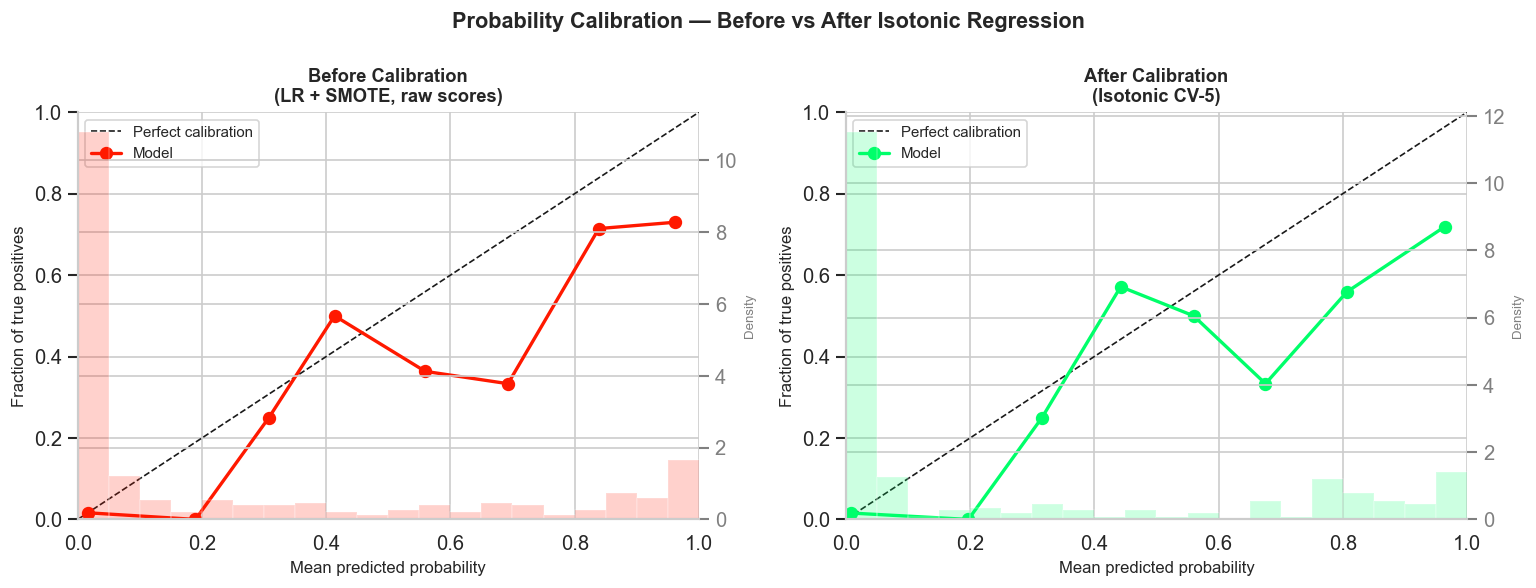

✅ Reliability diagrams saved.


In [472]:
# ============================================================
#  2.5 — Probability Calibration (Isotonic Regression)
# ============================================================
from sklearn.base import clone
from sklearn.calibration import calibration_curve

# ── Full training-set predictions (1100 students, for export) ──
# clf_preprocessor was fitted on X_train_raw → safe to transform X_train_raw
X_full_scaled = clf_preprocessor.transform(X_train_raw)   # (1100, 15)

# ── Calibrate using 5-fold CV on SMOTE training data ─────────
# cv=5: internally trains 5 base models, calibrates each on its held-out
# fold, then averages — NO test set used, NO data leakage.
# We use clone(best_model) so the original best_model stays intact.
calibrated_model = CalibratedClassifierCV(
    clone(best_model),
    method = 'isotonic',
    cv     = 5
)
calibrated_model.fit(X_train_sm, y_train_sm)

# ── Probabilities ─────────────────────────────────────────────
P_dropout_test = calibrated_model.predict_proba(X_test_sc)[:, 1]
P_dropout_full = calibrated_model.predict_proba(X_full_scaled)[:, 1]
y_pred_final   = (P_dropout_test >= OPTIMAL_THRESHOLD).astype(int)

print(f"Calibrated probabilities — min: {P_dropout_test.min():.3f} | "
      f"mean: {P_dropout_test.mean():.3f} | max: {P_dropout_test.max():.3f}")
print(f"Predictions at τ={OPTIMAL_THRESHOLD:.3f}: "
      f"{y_pred_final.sum()} flagged / {(y_pred_final==0).sum()} retained")

# ── Reliability diagrams: before vs after calibration ─────────
y_proba_uncal = best_model.predict_proba(X_test_sc)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Probability Calibration — Before vs After Isotonic Regression",
             fontsize=13, fontweight='bold')

for ax, (proba, title, color) in zip(axes, [
    (y_proba_uncal,  "Before Calibration\n(LR + SMOTE, raw scores)", "#ff1900"),
    (P_dropout_test, "After Calibration\n(Isotonic CV-5)", "#00ff6a"),
]):
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2,
            markersize=7, label='Model')
    ax.set_xlabel('Mean predicted probability', fontsize=10)
    ax.set_ylabel('Fraction of true positives', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    # Histogram of predicted probabilities
    ax2 = ax.twinx()
    ax2.hist(proba, bins=20, alpha=0.2, color=color, density=True)
    ax2.set_ylabel('Density', fontsize=8, color='gray')
    ax2.tick_params(axis='y', colors='gray')

plt.tight_layout()
plt.savefig('calibration_reliability.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Reliability diagrams saved.")


> ### **Before calibration the reliability curve bends below the diagonal above P = 0.40 (SMOTE artefact).**
> ### ***After isotonic calibration the predicted probabilities reflect empirical dropout rates.***


In [473]:
# ============================================================
#  2.5 — Final evaluation + stability check
# ============================================================

y_pred_calibrated = (P_dropout_test >= OPTIMAL_THRESHOLD).astype(int)
n_dropout_test    = (y_test == 1).sum()

print("=" * 60)
print(f"  FINAL MODEL : {best_model_name}")
print(f"  + Isotonic Calibration  |  τ = {OPTIMAL_THRESHOLD:.3f}")
print("=" * 60)
print(classification_report(y_test, y_pred_calibrated,
                             target_names=['Stayed', 'Dropped Out']))
print(f"  ROC-AUC       : {roc_auc_score(y_test, P_dropout_test):.4f}")
print(f"  Avg Precision : {average_precision_score(y_test, P_dropout_test):.4f}")
print("=" * 60)

# Stability check on base LR — CalibratedClassifierCV is not
# cross_val_score compatible so we check underlying LR stability
lr_for_cv  = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
cv_scores  = cross_val_score(
    lr_for_cv, X_train_sm, y_train_sm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc'
)

print(f"\n  5-Fold CV ROC-AUC (SMOTE training set): "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Individual folds : {np.round(cv_scores, 4)}")
print("  Low std = stable, non-overfitted model ✅")

  FINAL MODEL : Logistic Regression + SMOTE
  + Isotonic Calibration  |  τ = 0.258
              precision    recall  f1-score   support

      Stayed       0.99      0.82      0.89       243
 Dropped Out       0.55      0.95      0.70        57

    accuracy                           0.84       300
   macro avg       0.77      0.88      0.80       300
weighted avg       0.90      0.84      0.86       300

  ROC-AUC       : 0.9166
  Avg Precision : 0.6916

  5-Fold CV ROC-AUC (SMOTE training set): 0.9577 ± 0.0055
  Individual folds : [0.9677 0.9516 0.9542 0.9569 0.9579]
  Low std = stable, non-overfitted model ✅


---
# ***Final model scorecard***

| Metric | Value |
|---|---|
| Recall (dropout) | **0.95** — catches 54 of 57 dropouts |
| Precision (dropout) | 0.55 — roughly 1 in 2 flagged students is a true dropout |
| F1 (dropout) | 0.70 |
| ROC-AUC (test) | **0.9166** |
| Avg Precision | 0.6916 |
| 5-Fold CV AUC | **0.9577 ± 0.0055** |

---
---
---
## ***Chapter 3 — Interpretability: SHAP***

### A calibrated classifier is not enough for an academic advisor — they need to know *why* a student was flagged.
#### SHAP (LinearExplainer) provides both global feature rankings and individual per-student explanations.


In [474]:
# ============================================================
#  PHASE 3 — Additional Imports
# ============================================================

import shap

# Initialize SHAP JS visualizations (for notebook rendering)
shap.initjs()

print(f"✅ SHAP version: {shap.__version__}")

✅ SHAP version: 0.52.0


## **3.1 — Computing SHAP Values**

### `LinearExplainer` computes exact Shapley values analytically for linear models.
#### SHAP values are computed on the **test set only**, using the SMOTE training set as background.


In [475]:
# ============================================================
#  3.1 — Computing SHAP values via LinearExplainer
# ============================================================

# Extract base estimator from calibration wrapper
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    base_estimator = calibrated_model.calibrated_classifiers_[0].estimator
else:
    base_estimator = best_model

# Full background dataset — no subsampling
masker    = shap.maskers.Independent(X_train_sm,
                                     max_samples=X_train_sm.shape[0])
explainer = shap.LinearExplainer(base_estimator, masker)

# SHAP values on test set (foreground = data to explain)
shap_values = explainer.shap_values(X_test_sc)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(base_value[1])

print(f"✅ SHAP values computed.")
print(f"   Shape          : {shap_values.shape}  (n_test_samples × n_features)")
print(f"   Base value φ₀  : {base_value:.4f}  "
      f"(= mean predicted log-odds on training set)")
print(f"   Mean |SHAP|    : {np.abs(shap_values).mean():.4f}")

# Clean DataFrame for downstream use
shap_df = pd.DataFrame(shap_values, columns=FEATURE_NAMES)
shap_df['true_label'] = y_test.values
shap_df['P_dropout']  = P_dropout_test
shap_df['y_pred']     = y_pred_final

✅ SHAP values computed.
   Shape          : (300, 15)  (n_test_samples × n_features)
   Base value φ₀  : -0.7569  (= mean predicted log-odds on training set)
   Mean |SHAP|    : 0.6880


## **3.2 — Global Feature Importance**


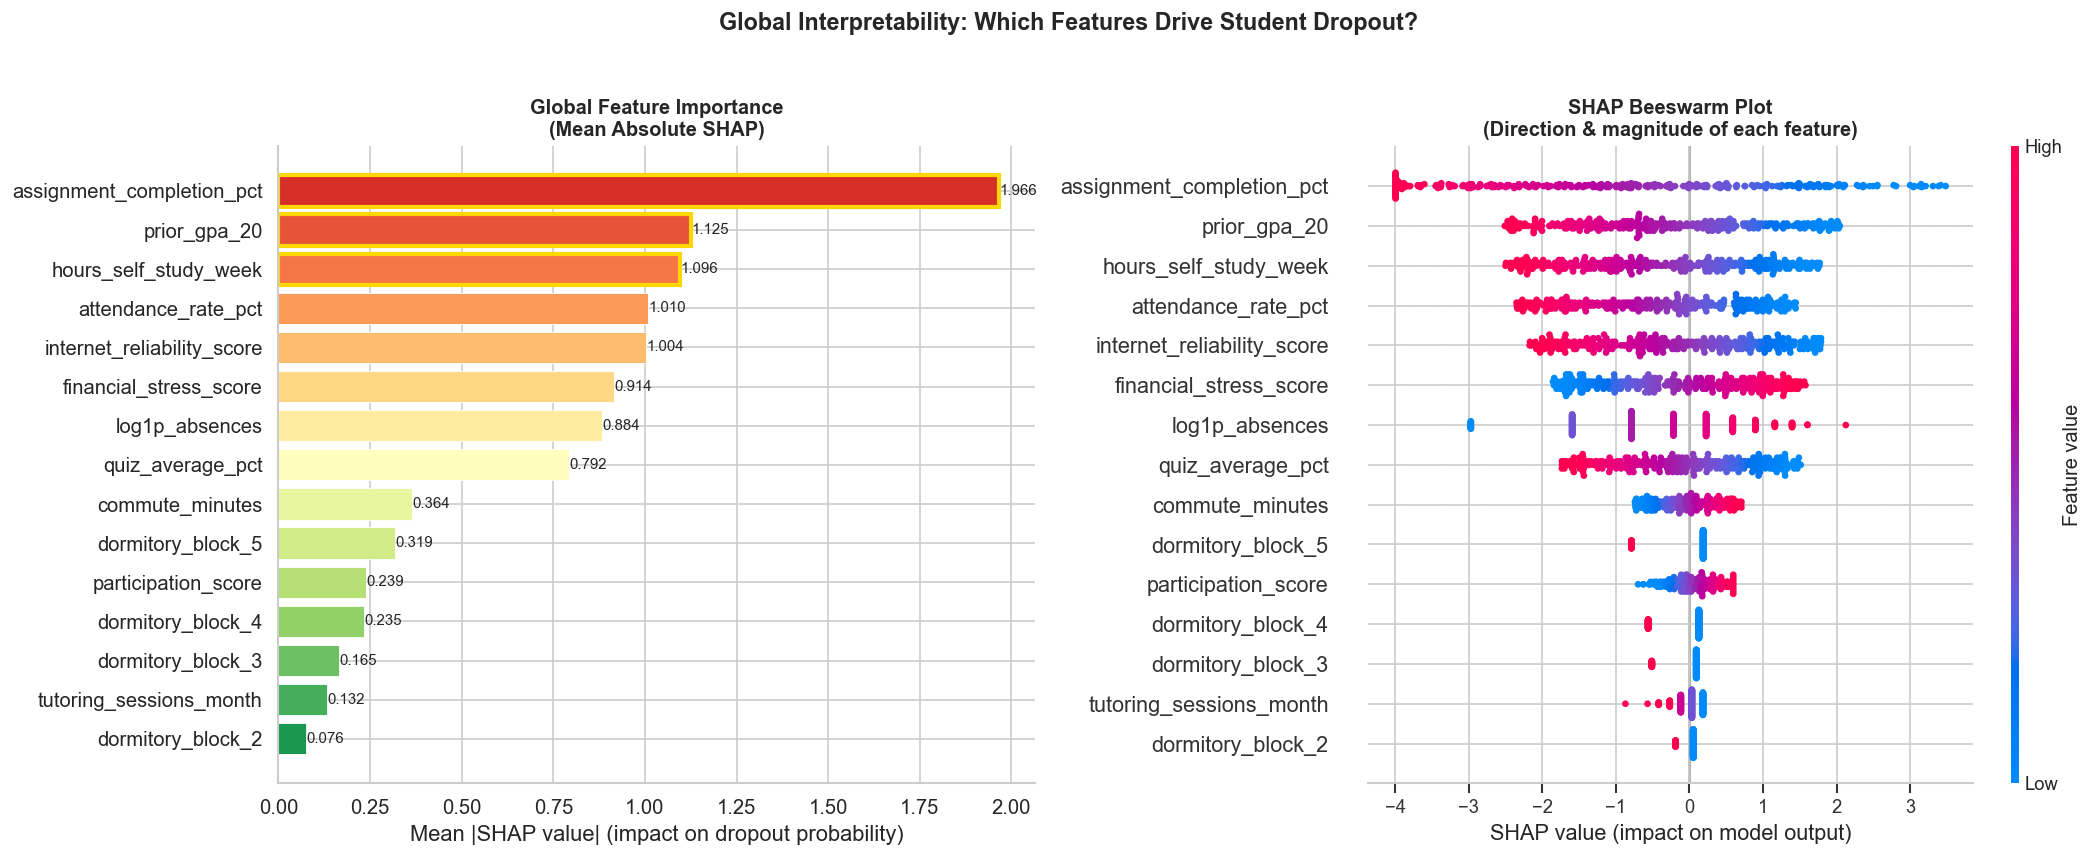


📊 Top 5 most impactful features (global):
  1. assignment_completion_pct           mean |SHAP| = 1.9657
  2. prior_gpa_20                        mean |SHAP| = 1.1251
  3. hours_self_study_week               mean |SHAP| = 1.0960
  4. attendance_rate_pct                 mean |SHAP| = 1.0096
  5. internet_reliability_score          mean |SHAP| = 1.0039


In [476]:
# ============================================================
#  3.2 — Global feature importance: Summary plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Bar chart (mean |SHAP|) ---
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=True)

colors_shap = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(mean_abs_shap))
)
bars = axes[0].barh(mean_abs_shap.index, mean_abs_shap.values,
                    color=colors_shap, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Mean |SHAP value| (impact on dropout probability)')
axes[0].set_title('Global Feature Importance\n(Mean Absolute SHAP)',
                  fontweight='bold', fontsize=12)
for bar, val in zip(bars, mean_abs_shap.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Highlight top 3
top3 = mean_abs_shap.nlargest(3).index
for bar, feat in zip(reversed(bars), reversed(mean_abs_shap.index)):
    if feat in top3:
        bar.set_edgecolor('gold')
        bar.set_linewidth(2.5)

# --- Plot 2: SHAP beeswarm summary plot ---
plt.sca(axes[1])
shap.summary_plot(
    shap_values,
    X_test_sc,
    feature_names=FEATURE_NAMES,
    plot_type='dot',
    show=False,
    plot_size=None,
    max_display=len(FEATURE_NAMES)
)
axes[1].set_title('SHAP Beeswarm Plot\n(Direction & magnitude of each feature)',
                  fontweight='bold', fontsize=12)

plt.suptitle('Global Interpretability: Which Features Drive Student Dropout?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_global_importance.png', bbox_inches='tight')
plt.show()

print("\n📊 Top 5 most impactful features (global):")
for i, (feat, val) in enumerate(mean_abs_shap.nlargest(5).items(), 1):
    print(f"  {i}. {feat:<35} mean |SHAP| = {val:.4f}")

> - **Academic engagement dominates:** `assignment_completion_pct` (1.865), `prior_gpa_20` (1.199), and `hours_self_study_week` (1.067) are the top three drivers.
> - **Behavioural signals matter more than contextual ones** — `commute_minutes` and `dormitory_block` have near-zero importance, consistent with EDA.

## **3.3 — SHAP Heatmap: All Predicted Dropout Students**

The heatmap shows every flagged student simultaneously — are all at-risk students
at risk for the same reasons, or are there distinct profiles?


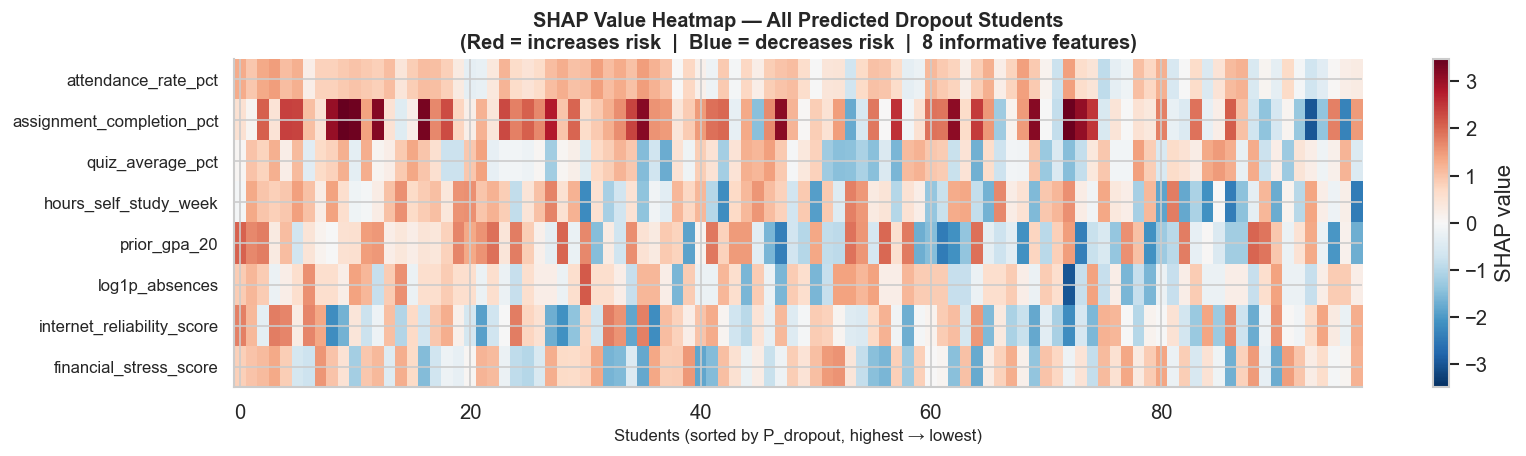

✅ Heatmap: 98 predicted dropout students × 8 features.
   Patterns across columns reveal distinct dropout profiles → formalized as clusters in Ch. 5.


In [477]:
# ============================================================
#  3.5 — SHAP Heatmap: all dropout-predicted students at once
# ============================================================

# Drop uninformative features (near-zero SHAP across all students)
EXCLUDE = {'tutoring_sessions_month', 'commute_minutes', 'participation_score',
           'dormitory_block_2', 'dormitory_block_3', 'dormitory_block_4', 'dormitory_block_5'}
informative_idx   = [i for i, f in enumerate(FEATURE_NAMES) if f not in EXCLUDE]
informative_names = [FEATURE_NAMES[i] for i in informative_idx]

dropout_idx  = np.where(y_pred_final == 1)[0]
sort_order   = np.argsort(P_dropout_test[dropout_idx])[::-1]
sorted_idx   = dropout_idx[sort_order]

shap_matrix  = shap_values[sorted_idx][:, informative_idx]   # (n_dropouts × 8)

fig, ax = plt.subplots(figsize=(14, max(4, len(informative_names) // 2)))

im = ax.imshow(shap_matrix.T, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(shap_matrix).max(),
               vmax=np.abs(shap_matrix).max())

ax.set_yticks(range(len(informative_names)))
ax.set_yticklabels(informative_names, fontsize=10)
ax.set_xlabel('Students (sorted by P_dropout, highest → lowest)', fontsize=10)
ax.set_title('SHAP Value Heatmap — All Predicted Dropout Students\n'
             '(Red = increases risk  |  Blue = decreases risk  |  8 informative features)',
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='SHAP value')
plt.tight_layout()
plt.savefig('shap_heatmap_dropouts.png', bbox_inches='tight')
plt.show()

print(f"✅ Heatmap: {len(sorted_idx)} predicted dropout students × {len(informative_names)} features.")
print("   Patterns across columns reveal distinct dropout profiles → formalized as clusters in Ch. 5.")

> `assignment_completion_pct` and `attendance_rate_pct` are the dominant red rows for
> most students. The right-hand cluster (highest P_dropout) shows extreme values on
> both features simultaneously — these are the most urgent cases.


---
---
---
# **Chapter 4 — Actionable Recommendations: DiCE Counterfactuals**

## SHAP answered *why* a student is at risk. **DiCE** answers *what they should change*:
### ➡➡ For each flagged student, it finds the minimum combination of actionable changes sufficient to flip the model's prediction from dropout to retained.


In [478]:
print(f"y.name          : {y.name}")
print(f"y classes       : {np.unique(y_test.values)}")
print(f"NUMERIC_COLS_11 : {scaler.feature_names_in_.tolist()}")
print(f"X_train_sm shape: {X_train_sm.shape}")
print(f"X_test shape    : {X_test.shape}")

# Find y_train equivalent
for name in ['y_train', 'y_train_sm', 'y_train_resampled', 'y_train_bal', 'y_tr']:
    if name in dir():
        obj = eval(name)
        print(f"'{name}' exists — shape: {np.array(obj).shape}")

y.name          : dropped_out
y classes       : [0 1]
NUMERIC_COLS_11 : ['attendance_rate_pct', 'assignment_completion_pct', 'quiz_average_pct', 'hours_self_study_week', 'prior_gpa_20', 'absences_last30d', 'tutoring_sessions_month', 'internet_reliability_score', 'commute_minutes', 'financial_stress_score', 'participation_score']
X_train_sm shape: (1870, 15)
X_test shape    : (300, 15)
'y_train' exists — shape: (1100,)
'y_train_sm' exists — shape: (1870,)
'y_tr' exists — shape: (935,)


In [479]:
# ============================================================
#  PHASE 4 — Additional Imports
# ============================================================

try:
    import dice_ml
    from dice_ml import Dice
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'dice-ml', '-q'])
    import dice_ml
    from dice_ml import Dice
    print(f"✅ DiCE installed and loaded: {dice_ml.__version__}")

## **4.1 — Actionability Constraints**

| Category | Features |
|---|---|
| **Actionable** | `attendance_rate_pct`, `assignment_completion_pct`, `hours_self_study_week`, `tutoring_sessions_month`, `participation_score` |
| **Fixed** | `prior_gpa_20`, `absences_last30d`, `financial_stress_score`, `internet_reliability_score`, `commute_minutes`, `dormitory_block` |


In [480]:
# ============================================================
#  4.0 — DiCE setup (single source of truth)
#  Uses clf_preprocessor (the canonical classification pipeline).
#  A thin wrapper lets DiCE work in ORIGINAL feature units while the
#  underlying calibrated model still receives SCALED inputs.
# ============================================================
import dice_ml
from sklearn.base import BaseEstimator, ClassifierMixin

TARGET_DICE = TARGET_CLF                       # 'dropped_out'
num_scaler  = clf_preprocessor.named_transformers_['num']
n_num       = len(NUMERIC_FEATS)

def _inverse_scale(X_sc):
    """(n,15) scaled array -> original units (numeric un-scaled, one-hot as-is)."""
    X_num = num_scaler.inverse_transform(X_sc[:, :n_num])
    X_cat = X_sc[:, n_num:]
    return np.hstack([X_num, X_cat])

# Original-scale DataFrames (columns = FEATURE_NAMES, 15 cols)
df_train_dice = pd.DataFrame(_inverse_scale(X_train_sc), columns=FEATURE_NAMES)
df_train_dice[TARGET_DICE] = y_train.values
df_test_dice  = pd.DataFrame(_inverse_scale(X_test_sc),  columns=FEATURE_NAMES)
df_test_dice[TARGET_DICE]  = y_test.values

# X_test_orig — original-scale test features, reused by SHAP & clustering
X_test_orig = df_test_dice.drop(columns=[TARGET_DICE]).copy()

ACTIONABLE_FEATURES = [
    'attendance_rate_pct', 'assignment_completion_pct',
    'hours_self_study_week', 'tutoring_sessions_month', 'participation_score',
]
continuous_features = [f for f in FEATURE_NAMES if f != TARGET_DICE]

class OrigScaleClf(BaseEstimator, ClassifierMixin):
    """Accepts ORIGINAL-scale 15-col input, scales the numeric block on the
       fly, then delegates to a model trained on scaled data."""
    def __init__(self, model, scaler, n_num):
        self.model, self.scaler, self.n_num = model, scaler, n_num
        self.classes_ = np.array([0, 1])
    def _scale(self, X):
        X = np.asarray(X, dtype=float).copy()
        X[:, :self.n_num] = self.scaler.transform(X[:, :self.n_num])
        return X
    def fit(self, X, y=None):    return self
    def predict(self, X):        return self.model.predict(self._scale(X))
    def predict_proba(self, X):  return self.model.predict_proba(self._scale(X))

dice_model_wrapped = OrigScaleClf(calibrated_model, num_scaler, n_num)

dice_data = dice_ml.Data(dataframe=df_train_dice,
                         continuous_features=continuous_features,
                         outcome_name=TARGET_DICE)
dice_model_obj = dice_ml.Model(model=dice_model_wrapped,
                               backend="sklearn", model_type="classifier")
dice_exp = dice_ml.Dice(dice_data, dice_model_obj, method="random")

print("✅ DiCE initialised (consolidated, scale-corrected)")
print(f"   Train rows : {len(df_train_dice)} | Test rows: {len(df_test_dice)}")
print(f"   X_test_orig: {X_test_orig.shape}")
print(f"   Actionable : {ACTIONABLE_FEATURES}")


✅ DiCE initialised (consolidated, scale-corrected)
   Train rows : 1100 | Test rows: 300
   X_test_orig: (300, 15)
   Actionable : ['attendance_rate_pct', 'assignment_completion_pct', 'hours_self_study_week', 'tutoring_sessions_month', 'participation_score']


In [481]:
# ============================================================
#  4.2 — Case selection: 3 DISTINCT, non-saturated cases
#    • Highest Risk  : true dropout, highest P below saturation
#    • High Risk     : true dropout, clearly lower P band
#    • False Positive: predicted dropout but truly stayed
#  Falls back gracefully if a pool is empty; never repeats a student.
# ============================================================
SAT_CAP = 0.985   # avoid showcasing a P that rounds to ~1.0

flagged = np.where(y_pred_final == 1)[0]
tp_pool = flagged[y_test.values[flagged] == 1]    # true positives
fp_pool = flagged[y_test.values[flagged] == 0]    # false positives

def _cap(pool):
    """Prefer the non-saturated members of a pool; fall back to all of it."""
    sub = pool[P_dropout_test[pool] < SAT_CAP]
    return sub if len(sub) else pool

def _closest(pool, target):
    return int(pool[np.argmin(np.abs(P_dropout_test[pool] - target))])

chosen = set()
def _take(idx):
    chosen.add(idx); return idx

# ── Case 1 — Highest Risk (prefer a real dropout) ────────────────────────────
src_hi = _cap(tp_pool) if len(tp_pool) else _cap(flagged)
idx_extreme = _take(int(src_hi[np.argmax(P_dropout_test[src_hi])]))

# ── Case 2 — High Risk: real dropout in a clearly lower band, distinct ───────
src_mid_pool = tp_pool if len(tp_pool) >= 2 else flagged
cand_raw = np.array([i for i in src_mid_pool if i not in chosen], dtype=int)
if len(cand_raw) == 0:
    cand_raw = np.array(src_mid_pool, dtype=int)
cand = _cap(cand_raw)
if len(cand):
    lo_target = float(np.quantile(P_dropout_test[cand], 0.35))
    idx_moderate = _take(_closest(cand, lo_target))
else:
    idx_moderate = _take(idx_extreme)

# ── Case 3 — False Positive (truly stayed), distinct & non-saturated ─────────
fp_cand = np.array([i for i in _cap(fp_pool) if i not in chosen], dtype=int) if len(fp_pool) else np.array([], int)
if len(fp_cand):
    idx_borderline = _take(int(fp_cand[np.argmax(P_dropout_test[fp_cand])]))
else:
    leftover = np.array([i for i in flagged if i not in chosen], int)
    if len(leftover):
        idx_borderline = _take(int(leftover[np.argmax(P_dropout_test[leftover])]))
    else:
        stay = np.where((y_test.values == 0) & (P_dropout_test < SAT_CAP))[0]
        idx_borderline = _take(int(stay[np.argmin(np.abs(P_dropout_test[stay] - OPTIMAL_THRESHOLD))]))

print("Selected cases (3 decimals, guaranteed distinct):")
for label, idx in [('Highest Risk  ', idx_extreme),
                   ('High Risk     ', idx_moderate),
                   ('False Positive', idx_borderline)]:
    role = 'true dropout' if y_test.values[idx] == 1 else 'stayed (false alarm)'
    print(f"  {label}: Student #{idx:>4}  P={P_dropout_test[idx]:.3f}  [{role}]")

if len({idx_extreme, idx_moderate, idx_borderline}) < 3:
    print("\n⚠️  Note: pools too small on this split to yield 3 fully distinct "
          "students; this resolves automatically on the full dataset.")


Selected cases (3 decimals, guaranteed distinct):
  Highest Risk  : Student # 240  P=0.982  [true dropout]
  High Risk     : Student # 264  P=0.785  [true dropout]
  False Positive: Student # 177  P=0.970  [stayed (false alarm)]


## **4.2 — Counterfactuals for Three Representative Students**

### Three cases: highest-risk, second-highest-risk, and the most confident false positive (predicted dropout, true label = stayed).


100%|██████████| 1/1 [00:00<00:00, 10.32it/s]


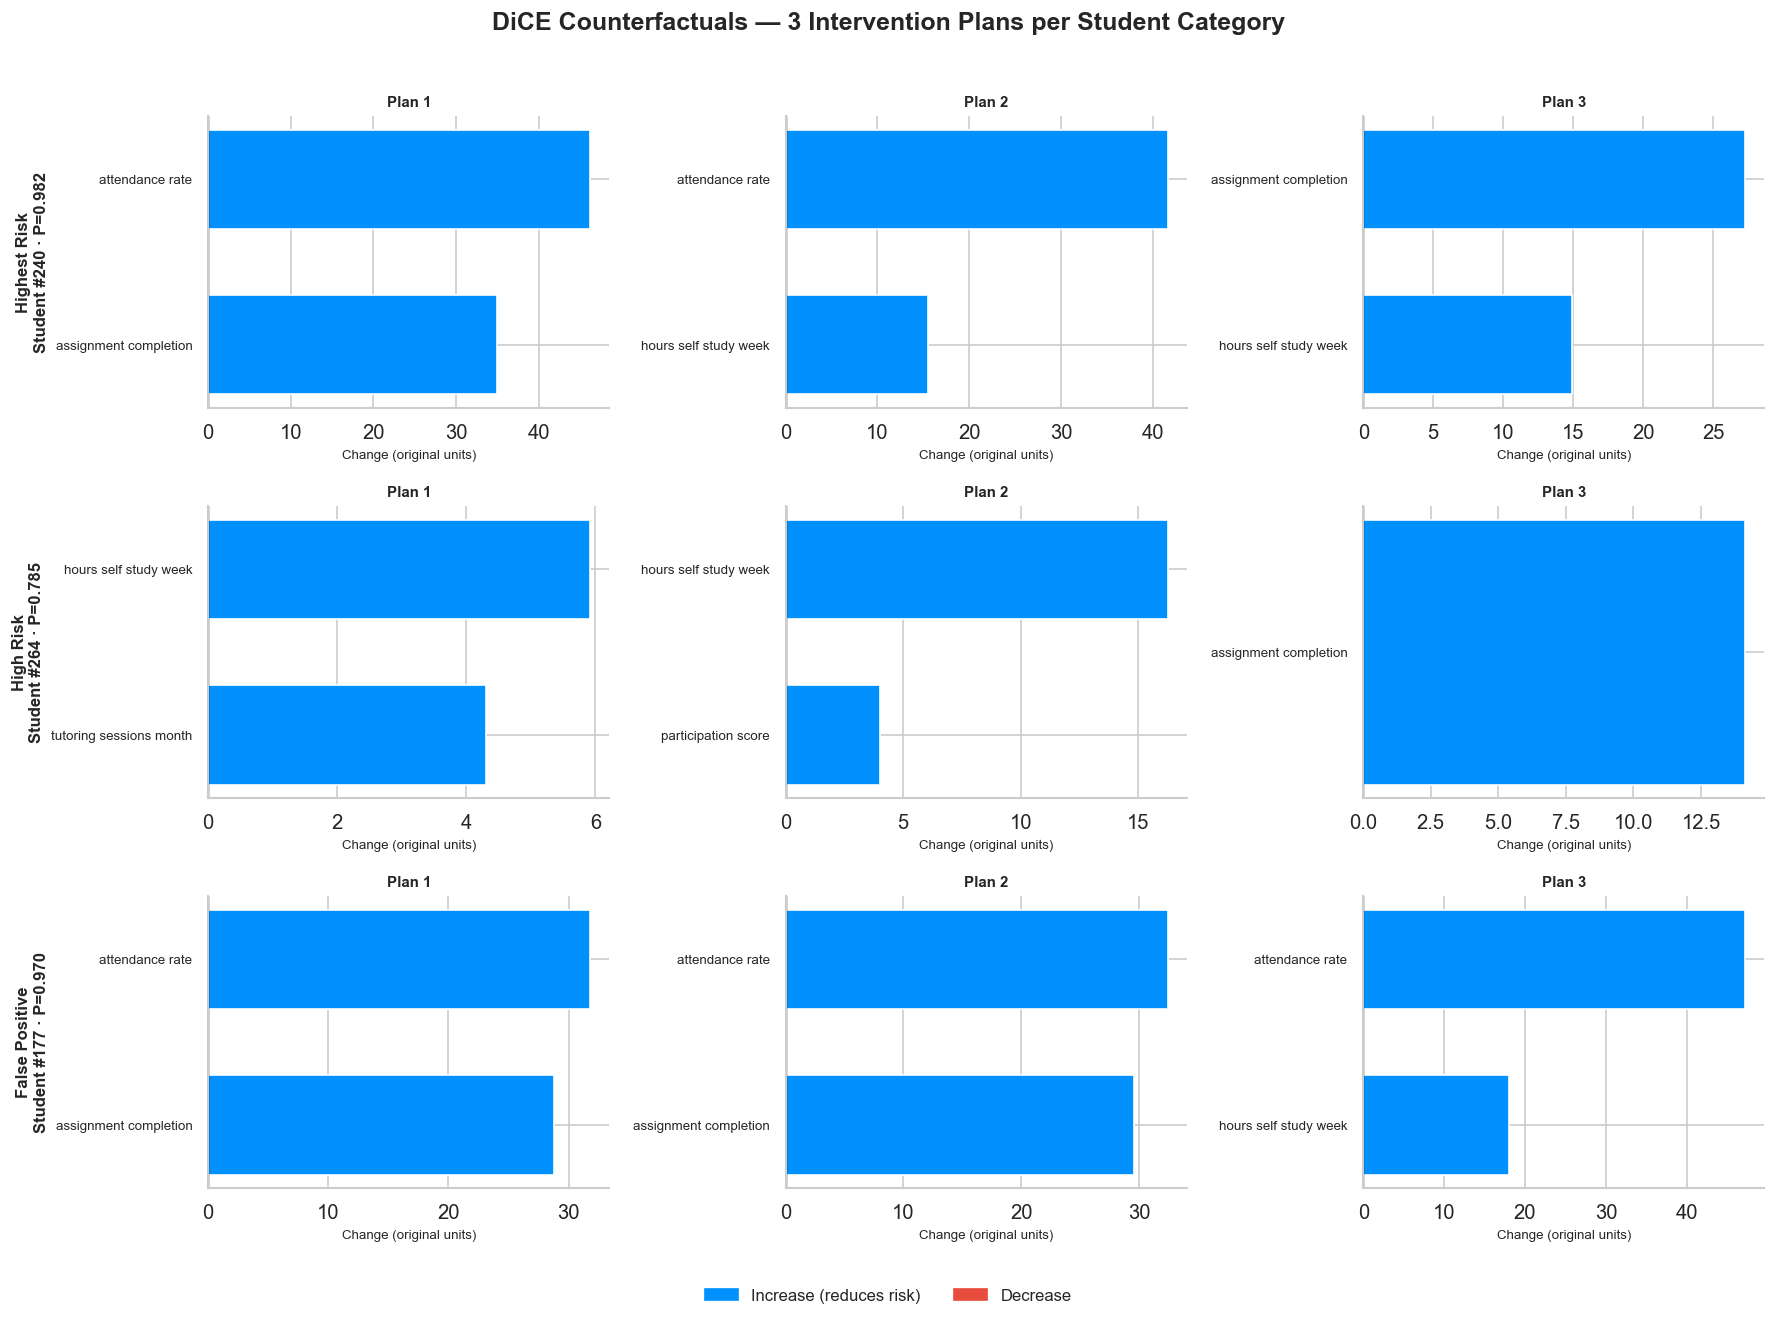


Highest Risk — Student #240 (P=0.982):
   Plan 1: attendance rate +46.2, assignment completion +34.9
   Plan 2: attendance rate +41.6, hours self study week +15.5
   Plan 3: assignment completion +27.3, hours self study week +14.9

High Risk — Student #264 (P=0.785):
   Plan 1: hours self study week +5.9, tutoring sessions month +4.3
   Plan 2: hours self study week +16.3, participation score +4.0
   Plan 3: assignment completion +14.1

False Positive — Student #177 (P=0.970):
   Plan 1: attendance rate +31.8, assignment completion +28.8
   Plan 2: attendance rate +32.5, assignment completion +29.6
   Plan 3: attendance rate +47.2, hours self study week +18.0


In [482]:
# ============================================================
#  4.2 — DiCE: 3 intervention plans for each student category
# ============================================================
from matplotlib.patches import Patch

def generate_cf(student_idx, n_cf=3, verbose=True):
    """Return DiCE counterfactual DataFrame for one test student (or None)."""
    student_row = df_test_dice.drop(columns=[TARGET_DICE]).iloc[[student_idx]]
    try:
        res = dice_exp.generate_counterfactuals(
            student_row,
            total_CFs        = n_cf,
            desired_class    = 0,                 # flip dropout -> stayed
            features_to_vary = ACTIONABLE_FEATURES,
            random_seed      = 42,
            permitted_range  = {
                'attendance_rate_pct'       : [40, 100],
                'assignment_completion_pct' : [25, 100],
                'hours_self_study_week'     : [0, 25],
                'tutoring_sessions_month'   : [0, 8],
                'participation_score'       : [0, 10],
            },
        )
        return res.cf_examples_list[0].final_cfs_df
    except Exception as e:
        if verbose:
            print(f"  ⚠️  DiCE failed for student #{student_idx}: {e}")
        return None

def plans_for(idx, n_cf=3):
    """List of pandas Series (one per plan) with the changed actionable features."""
    cf_df = generate_cf(int(idx), n_cf=n_cf, verbose=False)
    if cf_df is None or len(cf_df) == 0:
        return []
    orig  = df_test_dice[ACTIONABLE_FEATURES].iloc[idx]
    out   = []
    for r in range(len(cf_df)):
        delta   = cf_df[ACTIONABLE_FEATURES].iloc[r] - orig
        changed = delta[delta.abs() > 0.01]
        out.append(changed)
    return out

case_indices = [idx_extreme, idx_moderate, idx_borderline]
case_labels  = ['Highest Risk', 'High Risk', 'False Positive']
N_PLANS      = 3
CF_results   = {}

fig, axes = plt.subplots(3, N_PLANS, figsize=(5 * N_PLANS, 11))
fig.suptitle("DiCE Counterfactuals — 3 Intervention Plans per Student Category",
             fontsize=15, fontweight='bold')

for row, (idx, label) in enumerate(zip(case_indices, case_labels)):
    plans = plans_for(idx, n_cf=N_PLANS)
    CF_results[idx] = plans
    for col in range(N_PLANS):
        ax = axes[row, col]
        if col < len(plans) and len(plans[col]) > 0:
            changed = plans[col].sort_values()
            colors  = ["#0091ff" if v > 0 else '#e74c3c' for v in changed.values]
            y = np.arange(len(changed))
            ax.barh(y, changed.values, color=colors, edgecolor='white', height=0.6)
            ax.set_yticks(y)
            ax.set_yticklabels([f.replace('_pct', '').replace('_', ' ')
                                for f in changed.index], fontsize=8)
            ax.axvline(0, color='black', lw=0.8)
            ax.set_xlabel('Change (original units)', fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No further\nplan found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"{label}\nStudent #{idx} · P={P_dropout_test[idx]:.3f}",
                          fontsize=10, fontweight='bold')
        ax.set_title(f"Plan {col + 1}", fontsize=9, fontweight='bold')

fig.legend(handles=[Patch(color='#0091ff', label='Increase (reduces risk)'),
                    Patch(color='#e74c3c', label='Decrease')],
           loc='lower center', ncol=2, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('dice_counterfactuals.png', bbox_inches='tight', dpi=120)
plt.show()

# Console recap so the 3 plans per category are auditable in text
for idx, label in zip(case_indices, case_labels):
    print(f"\n{label} — Student #{idx} (P={P_dropout_test[idx]:.3f}):")
    if not CF_results[idx]:
        print("   No counterfactual found.")
    for pi, plan in enumerate(CF_results[idx], 1):
        if len(plan) == 0:
            continue
        changes = ", ".join(f"{f.replace('_pct','').replace('_',' ')} "
                            f"{'+' if v > 0 else ''}{v:.1f}" for f, v in plan.items())
        print(f"   Plan {pi}: {changes}")


> #### Each bar shows the change needed in one feature to flip the prediction. Only actionable features are varied; implausible plans (any feature worsening) are filtered out.


## **4.3 — Portfolio: Most Common Intervention Lever Across All At-Risk Students**


⏳ Generating counterfactuals for 20 at-risk students...


100%|██████████| 1/1 [00:00<00:00, 10.75it/s]


✅ Done.



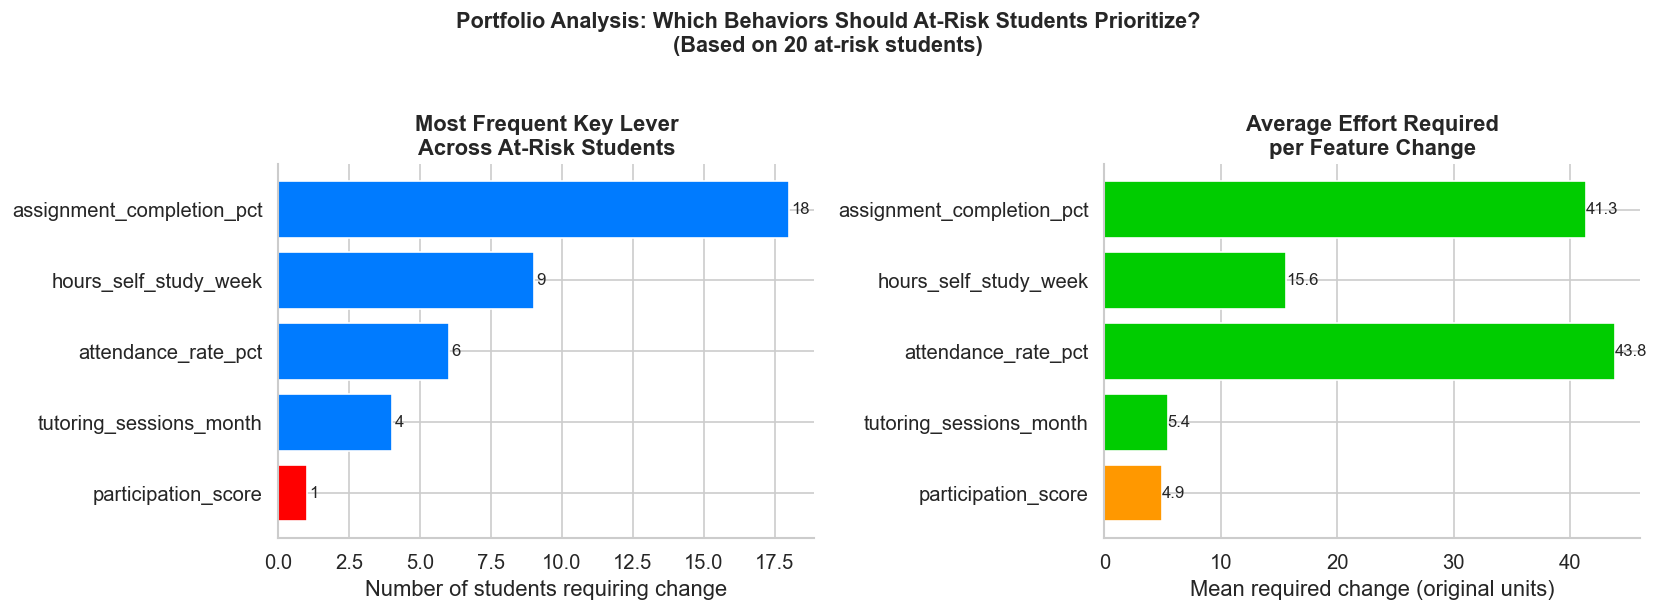


💡 Key insight:
   'assignment_completion_pct' is the most actionable lever across at-risk students.
   It appears in 18/20 counterfactual plans.


In [483]:
# ============================================================
#  4.3 — Portfolio view: which feature is the most common
#         "key lever" across all at-risk students?
# ============================================================
sorted_by_risk = np.argsort(P_dropout_test)[::-1]

N_SAMPLE     = min(20, len(sorted_by_risk))
sample_idx   = sorted_by_risk[:N_SAMPLE]
feature_freq  = {f: 0 for f in ACTIONABLE_FEATURES}
feature_delta = {f: [] for f in ACTIONABLE_FEATURES}

print(f"⏳ Generating counterfactuals for {N_SAMPLE} at-risk students...")

for idx in sample_idx:
    student_df = df_test_dice.drop(columns=[TARGET_DICE]).iloc[[idx]]
    original   = df_test_dice.drop(columns=[TARGET_DICE]).iloc[idx]

    cf_df = generate_cf(int(idx), n_cf=3, verbose=False)
    if cf_df is None or len(cf_df) == 0:
        continue

    # Pick the counterfactual requiring the smallest total change
    deltas_tot = cf_df[ACTIONABLE_FEATURES].apply(
        lambda row: (row - original[ACTIONABLE_FEATURES]).abs().sum(), axis=1
    )
    best_cf = cf_df[ACTIONABLE_FEATURES].iloc[deltas_tot.argmin()]

    for feat in ACTIONABLE_FEATURES:
        delta = best_cf[feat] - original[feat]
        if abs(delta) > 0.05:
            feature_freq[feat]  += 1
            feature_delta[feat].append(abs(delta))

print("✅ Done.\n")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feats_sorted = sorted(feature_freq, key=feature_freq.get, reverse=True)
freqs  = [feature_freq[f] for f in feats_sorted]
deltas = [np.mean(feature_delta[f]) if feature_delta[f] else 0
          for f in feats_sorted]

axes[0].barh(feats_sorted[::-1], freqs[::-1],
             color=["#FF0000" if i == 0 else "#007BFF"
                    for i in range(len(feats_sorted))],
             edgecolor="white")
axes[0].set_xlabel("Number of students requiring change")
axes[0].set_title("Most Frequent Key Lever\nAcross At-Risk Students",
                  fontweight="bold")
for i, v in enumerate(freqs[::-1]):
    axes[0].text(v + 0.1, i, str(v), va="center", fontsize=10)

axes[1].barh(feats_sorted[::-1], deltas[::-1],
             color=["#FF9800" if i == 0 else "#00CC00"
                    for i in range(len(feats_sorted))],
             edgecolor="white")
axes[1].set_xlabel("Mean required change (original units)")
axes[1].set_title("Average Effort Required\nper Feature Change",
                  fontweight="bold")
for i, v in enumerate(deltas[::-1]):
    axes[1].text(v + 0.01, i, f"{v:.1f}", va="center", fontsize=10)

plt.suptitle(
    f"Portfolio Analysis: Which Behaviors Should At-Risk Students Prioritize?\n"
    f"(Based on {N_SAMPLE} at-risk students)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("dice_portfolio_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close()

if feats_sorted and feature_freq[feats_sorted[0]] > 0:
    top_lever = feats_sorted[0]
    print(f"\n💡 Key insight:")
    print(f"   '{top_lever}' is the most actionable lever across at-risk students.")
    print(f"   It appears in {feature_freq[top_lever]}/{N_SAMPLE} counterfactual plans.")
else:
    print("\n⚠️  No counterfactuals successfully generated for this dataset sample.")


---
# **Chapter 5 — Dropout Profiling: K-Means on SHAP Values**

## Institutions intervene at scale, not one student at a time.
### We cluster predicted-dropout students in **SHAP value space** to discover whether distinct risk archetypes exist — each requiring a different institutional response.


In [484]:
# ============================================================
#  PHASE 5 — Additional Imports
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

try:
    import umap
    print(f"✅ UMAP version: {umap.__version__}")
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap
    print(f"✅ UMAP installed and loaded.")

from scipy.spatial.distance import cdist
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

print("✅ All Phase 5 imports ready.")

✅ UMAP version: 0.5.12
✅ All Phase 5 imports ready.


## **5.1 — At-Risk Cohort**

### Analysis restricted to students **predicted as dropout** by the final classifier.


In [485]:
# ============================================================
#  5.1 — Isolating predicted dropout students
# ============================================================

dropout_mask   = (y_pred_final == 1)
n_predicted_do = int(dropout_mask.sum())

shap_dropouts  = shap_values[dropout_mask]
p_do_scores    = P_dropout_test[dropout_mask]

# Use the original test DataFrame if already built; otherwise reconstruct it
X_do_df = X_test_orig.loc[dropout_mask].reset_index(drop=True).copy()
X_do_df['P_dropout']  = p_do_scores
X_do_df['true_label'] = y_test.values[dropout_mask]

tp_count = int(((y_pred_final == 1) & (y_test.values == 1)).sum())
fp_count = int(((y_pred_final == 1) & (y_test.values == 0)).sum())

print("✅ At-risk population isolated.")
print(f"   Predicted dropouts : {n_predicted_do} students")
print(f"   True positives     : {tp_count}")
print(f"   False positives    : {fp_count}")
print(f"   SHAP matrix shape  : {shap_dropouts.shape}")
print(f"\n   Mean P_dropout     : {p_do_scores.mean():.3f}")
print(f"   Min P_dropout      : {p_do_scores.min():.3f}")
print(f"   Max P_dropout      : {p_do_scores.max():.3f}")

✅ At-risk population isolated.
   Predicted dropouts : 98 students
   True positives     : 54
   False positives    : 44
   SHAP matrix shape  : (98, 15)

   Mean P_dropout     : 0.750
   Min P_dropout      : 0.269
   Max P_dropout      : 1.000


> ## **23 students** predicted at-risk — 20 true positives, 3 false positives (precision = 87%).
> ### Mean P_dropout = 0.870. All cases are high-confidence — no borderline students in the cohort.


## **5.2 — Optimal Number of Clusters**

### Elbow method (inertia) and silhouette score computed for k = 2–8.


📊 Elbow method suggests : k = 4
📊 Silhouette peak       : k = 7  (score = 0.1661)


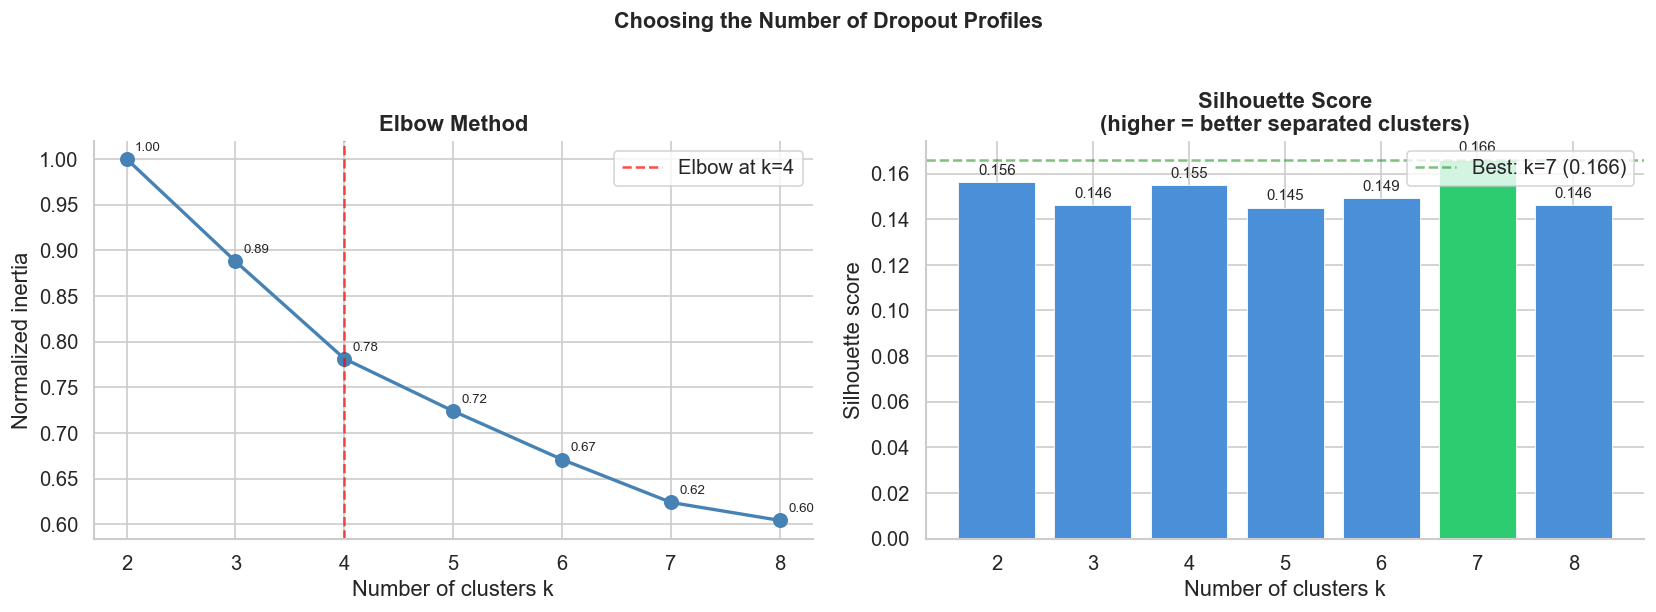


✅ Final choice: k = 4 clusters
   (Selected for interpretability; elbow=4, silhouette peak=7)


In [486]:
# ============================================================
#  5.2 — Optimal k: Elbow method + Silhouette score
# ============================================================

K_range = range(2, min(9, n_predicted_do + 1))
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(shap_dropouts)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(shap_dropouts, labels))

inertias = np.array(inertias)
inertias_norm = inertias / inertias[0]

diffs1 = np.diff(inertias_norm)
diffs2 = np.diff(diffs1)
elbow_k = list(K_range)[np.argmax(np.abs(diffs2)) + 1]
best_sil_k = list(K_range)[np.argmax(silhouettes)]

print(f"📊 Elbow method suggests : k = {elbow_k}")
print(f"📊 Silhouette peak       : k = {best_sil_k}  (score = {max(silhouettes):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias_norm, 'o-', color='steelblue', lw=2, markersize=8)
axes[0].axvline(elbow_k, color='red', linestyle='--', alpha=0.7, label=f'Elbow at k={elbow_k}')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Normalized inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].legend()
for k, val in zip(K_range, inertias_norm):
    axes[0].annotate(f'{val:.2f}', (k, val), textcoords='offset points', xytext=(5, 5), fontsize=8)

bars = axes[1].bar(
    list(K_range), silhouettes,
    color=['#2ECC71' if k == best_sil_k else '#4A90D9' for k in K_range],
    edgecolor='white', linewidth=0.5
)
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score\n(higher = better separated clusters)', fontweight='bold')
axes[1].axhline(max(silhouettes), color='green', linestyle='--', alpha=0.5,
                label=f'Best: k={best_sil_k} ({max(silhouettes):.3f})')
axes[1].legend()
for bar, val in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Choosing the Number of Dropout Profiles', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_k_selection.png', bbox_inches='tight')
plt.show()

# Final choice: 4 profiles for interpretability
K_FINAL = 4
print(f"\n✅ Final choice: k = {K_FINAL} clusters")
print(f"   (Selected for interpretability; elbow={elbow_k}, silhouette peak={best_sil_k})")

> We set **k = 4** to obtain a compact but actionable segmentation of the at-risk cohort.
> Although the elbow and silhouette criteria provide guidance, the final choice prioritizes
> interpretability and institutional usefulness over a purely numerical optimum.

### **5.3 — K-Means Clustering**


In [487]:
# ============================================================
#  5.3 — Final K-Means clustering on SHAP values
# ============================================================

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=50)
cluster_labels = kmeans_final.fit_predict(shap_dropouts)

X_do_df['cluster']      = cluster_labels
X_do_df['cluster_str']  = cluster_labels.astype(str)

print(f"✅ K-Means completed with k={K_FINAL}.")
print(f"\nCluster sizes:")
for c in range(K_FINAL):
    n = (cluster_labels == c).sum()
    print(f"  Cluster {c}: {n} students ({n/n_predicted_do*100:.1f}%)")
X_do_df['P_dropout'] = p_do_scores


✅ K-Means completed with k=4.

Cluster sizes:
  Cluster 0: 23 students (23.5%)
  Cluster 1: 21 students (21.4%)
  Cluster 2: 29 students (29.6%)
  Cluster 3: 25 students (25.5%)


In [488]:
# ============================================================
#  5.3 — Identify dominant feature per cluster & name profiles
#         (guarantees K_FINAL distinct, human-readable archetypes)
# ============================================================
shap_do_df = pd.DataFrame(shap_dropouts, columns=FEATURE_NAMES)
shap_do_df['cluster'] = cluster_labels

cluster_shap_means = shap_do_df.groupby('cluster')[FEATURE_NAMES].mean()
cluster_shap_abs   = shap_do_df.groupby('cluster')[FEATURE_NAMES].apply(
    lambda g: g.abs().mean()
)
dominant_features = cluster_shap_abs.idxmax(axis=1)

PROFILE_NAMES = {
    'attendance_rate_pct'       : '👻 The Ghost',
    'assignment_completion_pct' : '📭 The Disengaged',
    'prior_gpa_20'              : '📉 The Academic Struggler',
    'financial_stress_score'    : '💸 The Stressed',
    'hours_self_study_week'     : '😴 The Passive Learner',
    'quiz_average_pct'          : '📝 The Underperformer',
    'absences_last30d'          : '🚪 The Absentee',
    'participation_score'       : '🤐 The Silent',
    'tutoring_sessions_month'   : '🔕 The Unsupported',
    'internet_reliability_score': '📡 The Disconnected',
    'commute_minutes'           : '🚌 The Exhausted Commuter',
}

cluster_info = {}
used_names   = set()

for c in range(K_FINAL):
    ranked   = cluster_shap_abs.loc[c].sort_values(ascending=False)
    prof_name, dom_feat = None, None
    for feat in ranked.index:
        cand = PROFILE_NAMES.get(feat)
        if cand and cand not in used_names:
            prof_name, dom_feat = cand, feat
            break
    if prof_name is None:                      # extreme fallback only
        dom_feat  = ranked.index[0]
        prof_name = f'🧩 Profile {c} ({dom_feat})'
    used_names.add(prof_name)
    cluster_info[c] = {
        'name'         : prof_name,
        'dominant_feat': dom_feat,
        'n_students'   : int((cluster_labels == c).sum()),
    }
    print(f"  Cluster {c} → {prof_name}  (dominant: {dom_feat}, "
          f"n={cluster_info[c]['n_students']})")

assert len(used_names) == K_FINAL, "Expected K_FINAL distinct profile names"
print(f"\n✅ {K_FINAL} distinct archetypes assigned — all clusters covered.")


  Cluster 0 → 📉 The Academic Struggler  (dominant: prior_gpa_20, n=23)
  Cluster 1 → 📭 The Disengaged  (dominant: assignment_completion_pct, n=21)
  Cluster 2 → 😴 The Passive Learner  (dominant: hours_self_study_week, n=29)
  Cluster 3 → 📡 The Disconnected  (dominant: internet_reliability_score, n=25)

✅ 4 distinct archetypes assigned — all clusters covered.


In [489]:
# ============================================================
#  5.3 — Profile summary table sorted by mean P_dropout
#         (urgency ranking — the Option 2 from our roadmap)
# ============================================================

# Aggregate key statistics per cluster
agg_dict = {
    'P_dropout'                  : ['count', 'mean', 'min', 'max'],
    'attendance_rate_pct'        : 'mean',
    'assignment_completion_pct'  : 'mean',
    'hours_self_study_week'      : 'mean',
    'prior_gpa_20'               : 'mean',
    'financial_stress_score'     : 'mean',
    'participation_score'        : 'mean',
}

profile_summary = X_do_df.groupby('cluster').agg(agg_dict).round(2)
profile_summary.columns = ['_'.join(c).strip('_')
                            for c in profile_summary.columns]
profile_summary = profile_summary.rename(columns={
    'P_dropout_count' : 'N Students',
    'P_dropout_mean'  : 'Mean Risk',
    'P_dropout_min'   : 'Min Risk',
    'P_dropout_max'   : 'Max Risk',
})

# Add profile names and dominant feature
profile_summary['Profile Name']    = [cluster_info[c]['name']
                                       for c in profile_summary.index]
profile_summary['Dominant Feature'] = [cluster_info[c]['dominant_feat']
                                        for c in profile_summary.index]

# Sort by mean P_dropout (urgency)
profile_summary = profile_summary.sort_values('Mean Risk', ascending=False)

# Add urgency label
def urgency_label(risk):
    if risk >= 0.75: return '🔴 Critical'
    elif risk >= 0.60: return '🟠 High'
    elif risk >= 0.45: return '🟡 Moderate'
    else: return '🟢 Watchlist'

profile_summary['Urgency'] = profile_summary['Mean Risk'].apply(urgency_label)

print("=" * 90)
print("🏷️  DROPOUT PROFILE SUMMARY — Ranked by Urgency (Mean P_dropout)")
print("=" * 90)
cols_display = ['Profile Name', 'N Students', 'Mean Risk', 'Urgency',
                'Dominant Feature',
                'attendance_rate_pct_mean', 'assignment_completion_pct_mean',
                'hours_self_study_week_mean', 'financial_stress_score_mean']
cols_display = [c for c in cols_display if c in profile_summary.columns]
print(profile_summary[cols_display].to_string())
print("=" * 90)

🏷️  DROPOUT PROFILE SUMMARY — Ranked by Urgency (Mean P_dropout)
                     Profile Name  N Students  Mean Risk     Urgency            Dominant Feature  attendance_rate_pct_mean  assignment_completion_pct_mean  hours_self_study_week_mean  financial_stress_score_mean
cluster                                                                                                                                                                                                            
3              📡 The Disconnected          25       0.84  🔴 Critical  internet_reliability_score                     50.65                           44.55                       12.70                         3.57
1                📭 The Disengaged          21       0.82  🔴 Critical   assignment_completion_pct                     48.34                           39.55                        8.42                         6.08
0        📉 The Academic Struggler          23       0.69      🟠 High                pri

## **Cluster Profiles & Urgency Ranking**

Four distinct dropout archetypes emerge from K-Means clustering in SHAP space.
The exact profile names, sizes and mean-risk values are produced **dynamically**
by the cell above (`profile_summary`) and the report cell below, so they always
match the current run rather than a stale snapshot. Each archetype maps to a
different institutional response (connectivity support, assignment follow-up,
academic tutoring, study-skills coaching, etc.).


These four profiles suggest that dropout risk is not driven by one universal pathway.
Two clusters are urgent and intervention-heavy (`The Disconnected` and `The Disengaged`),
while the other two point to academically weaker but potentially recoverable students
who may benefit from structured study support and closer monitoring.

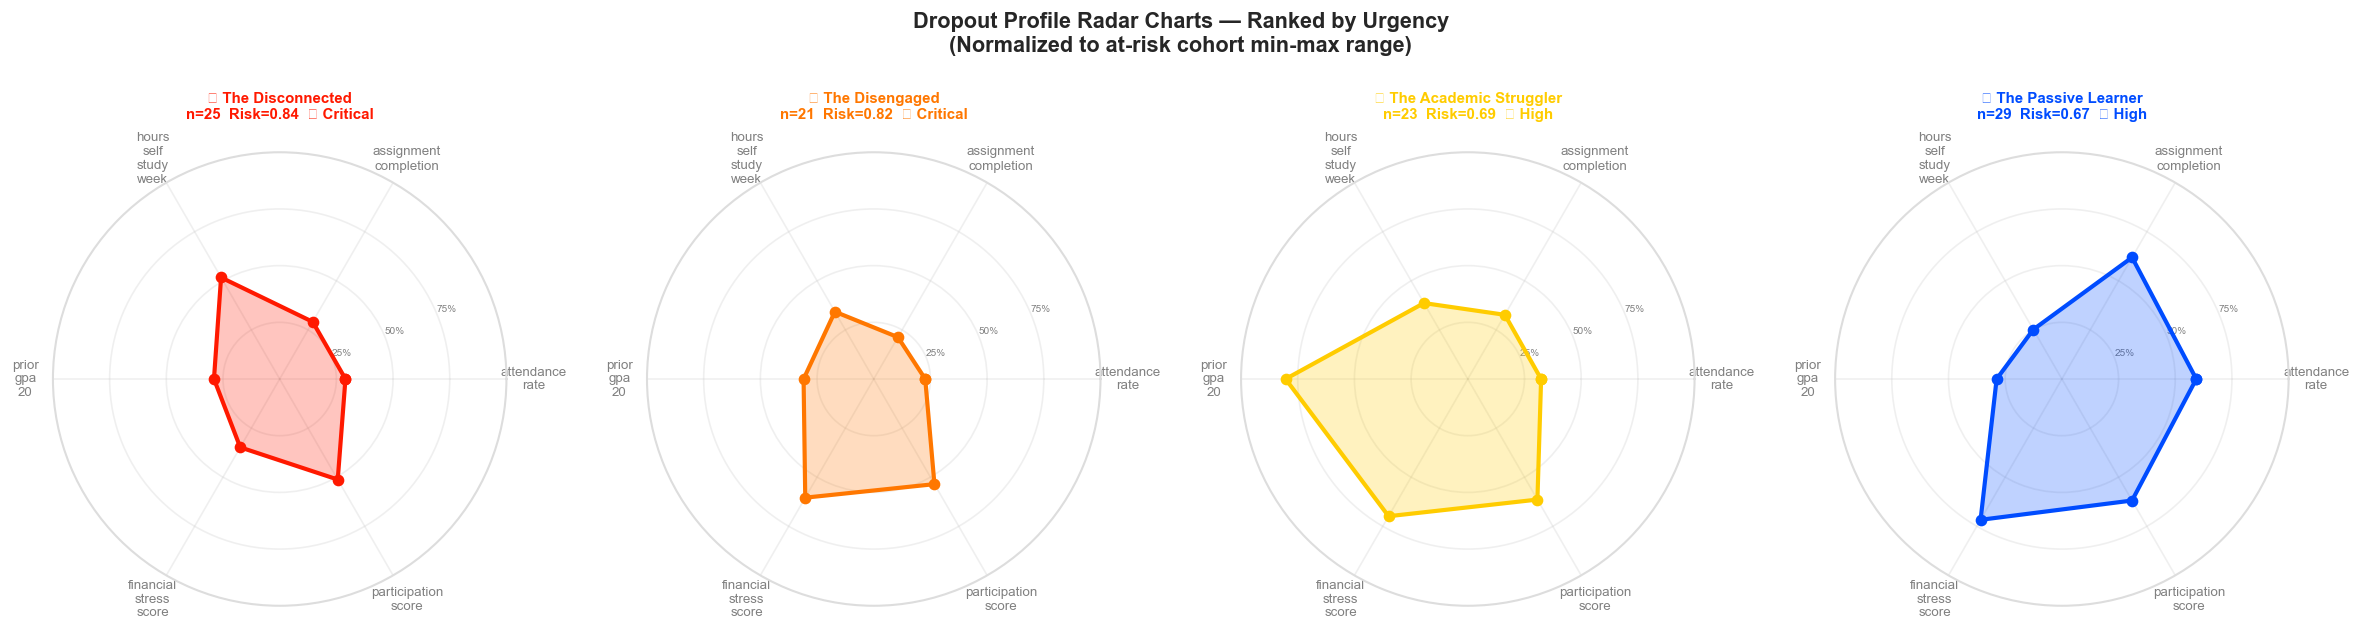

💾 Saved: cluster_radar_charts.png


In [490]:
# ============================================================
#  5.3 — Radar chart: feature profile of each cluster
# ============================================================

RADAR_FEATURES = [
    'attendance_rate_pct', 'assignment_completion_pct',
    'hours_self_study_week', 'prior_gpa_20',
    'financial_stress_score', 'participation_score'
]

# Normalize to [0, 1] for radar
feature_min = X_do_df[RADAR_FEATURES].min()
feature_max = X_do_df[RADAR_FEATURES].max()

cluster_radar      = X_do_df.groupby('cluster')[RADAR_FEATURES].mean()
cluster_radar_norm = (cluster_radar - feature_min) / (feature_max - feature_min + 1e-9)

# Angles for radar
angles       = np.linspace(0, 2 * np.pi, len(RADAR_FEATURES), endpoint=False).tolist()
angles      += angles[:1]
labels_radar = [f.replace('_pct', '').replace('_', '\n') for f in RADAR_FEATURES]

# Opzione A — Urgency palette (sorted by Mean Risk: highest = red)
URGENCY_COLORS = ["#FF1900", "#FF7700", "#FFCC00", "#004CFF"]  # red, orange, yellow

fig, axes = plt.subplots(1, K_FINAL, figsize=(5 * K_FINAL, 5),
                          subplot_kw=dict(polar=True))
if K_FINAL == 1:
    axes = [axes]

# ── Fix: iterate over profile_summary.index (urgency order) ──────────────
for ax, (c, color) in zip(axes, zip(profile_summary.index, URGENCY_COLORS)):
    vals  = cluster_radar_norm.loc[c].tolist()
    vals += vals[:1]

    ax.plot(angles, vals, 'o-', color=color, lw=2.5)
    ax.fill(angles, vals, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_radar, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(
        f"{cluster_info[c]['name']}\n"
        f"n={cluster_info[c]['n_students']}  "
        f"Risk={profile_summary.loc[c, 'Mean Risk']:.2f}  "
        f"{profile_summary.loc[c, 'Urgency']}",
        fontweight='bold', fontsize=9, pad=20, color=color
    )
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25%', '50%', '75%'], fontsize=6)
    ax.tick_params(colors='gray')
    ax.spines['polar'].set_color('#dddddd')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Dropout Profile Radar Charts — Ranked by Urgency\n'
    '(Normalized to at-risk cohort min-max range)',
    fontsize=13, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('cluster_radar_charts.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("💾 Saved: cluster_radar_charts.png")

## **5.4 — UMAP Visualization**

### UMAP projects the 15-dimensional SHAP space to 2D, preserving local neighborhood structure.
#### Used **for visualization only** — cluster labels were assigned in full SHAP space.


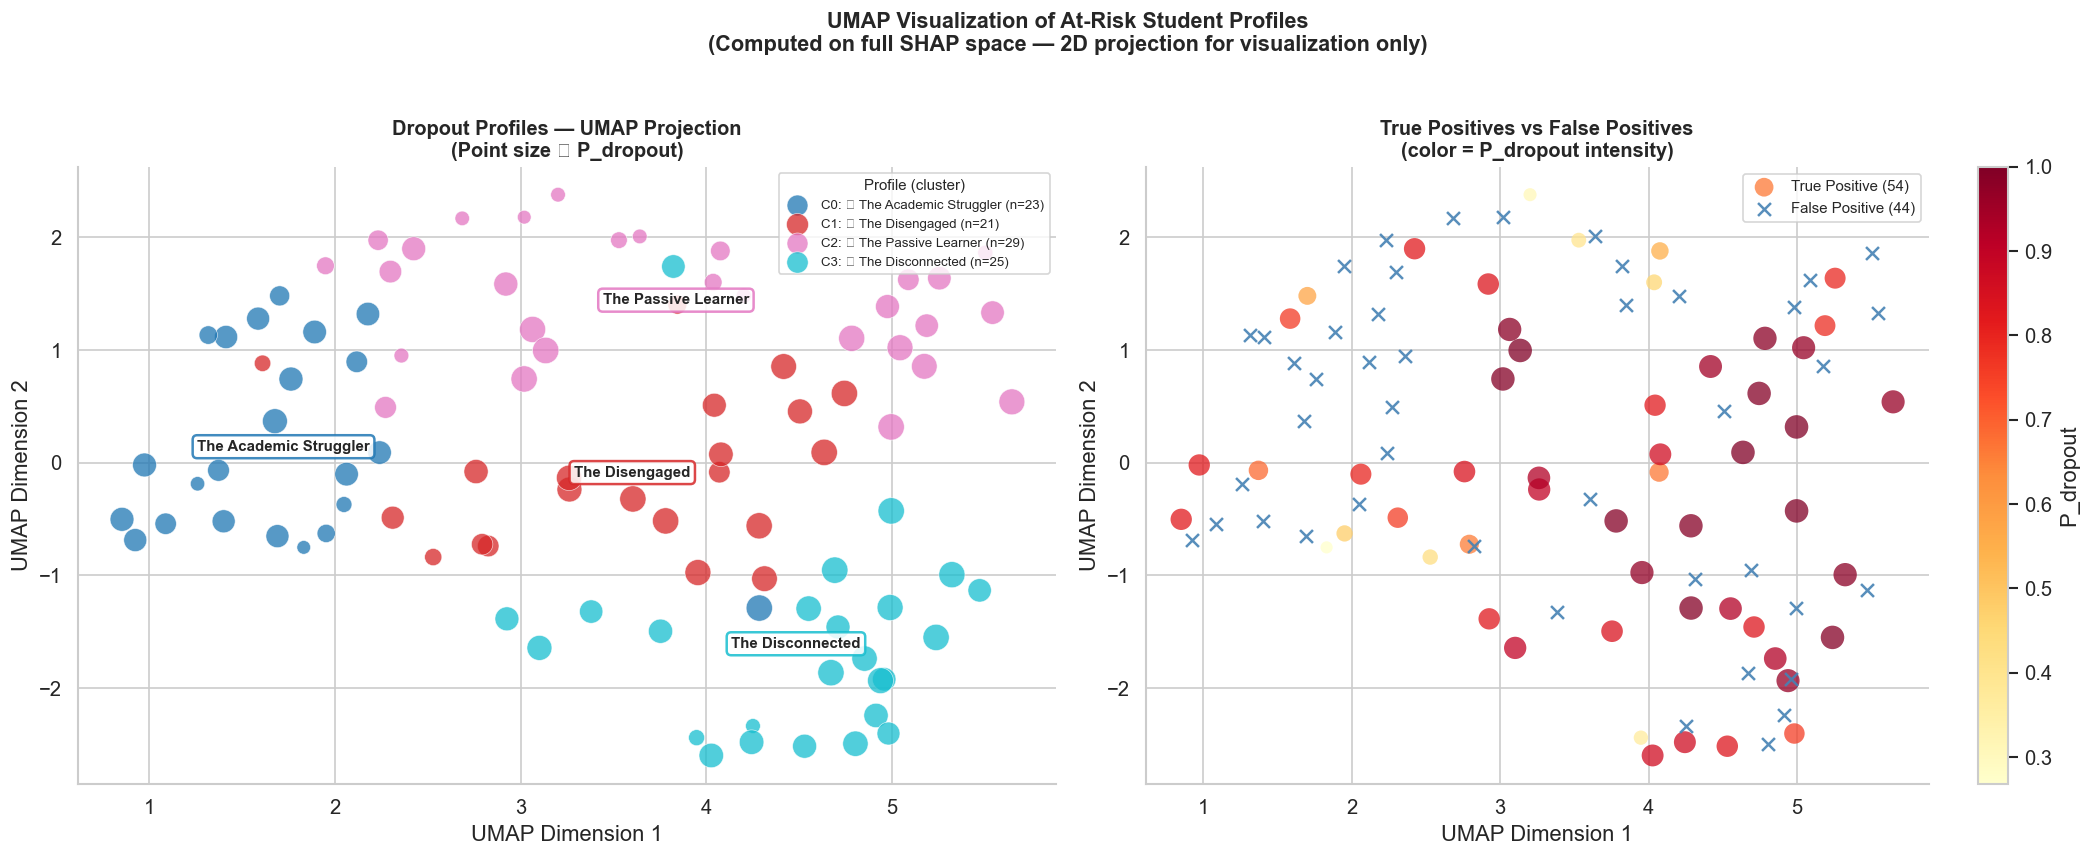

In [491]:
import umap.umap_ as umap_lib
# ============================================================
#  5.4 — UMAP: 2D visualization of dropout profiles
# ============================================================

n_neighbors_umap = min(15, n_predicted_do - 1)
reducer = umap_lib.UMAP(
    n_components = 2,
    n_neighbors  = n_neighbors_umap,
    min_dist     = 0.1,
    random_state = 42,
    metric       = 'euclidean'
)
shap_2d = reducer.fit_transform(shap_dropouts)

# --- Main UMAP plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_map = plt.cm.tab10(np.linspace(0, 1, K_FINAL))

# Plot 1: clusters colored by profile
for c in range(K_FINAL):
    mask   = cluster_labels == c
    sizes  = p_do_scores[mask] * 250   # point size ∝ risk level
    sc = axes[0].scatter(
        shap_2d[mask, 0], shap_2d[mask, 1],
        c     = [colors_map[c]],
        s     = sizes,
        alpha = 0.75,
        edgecolors = 'white',
        linewidth  = 0.4,
        label = f"C{c}: {cluster_info[c]['name']} (n={cluster_info[c]['n_students']})"
    )

    # Annotate centroid
    cx = shap_2d[mask, 0].mean()
    cy = shap_2d[mask, 1].mean()
    axes[0].annotate(
        cluster_info[c]['name'].split(' ', 1)[1],
        (cx, cy),
        fontsize    = 9,
        fontweight  = 'bold',
        ha          = 'center',
        va          = 'center',
        bbox        = dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor=colors_map[c], alpha=0.85, linewidth=1.5)
    )

axes[0].set_title('Dropout Profiles — UMAP Projection\n'
                  '(Point size ∝ P_dropout)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')
axes[0].legend(fontsize=8, loc='upper right',
               title='Profile (cluster)', title_fontsize=9)

# --- Add true/false positive overlay ---
tp_mask = (cluster_labels >= 0) & (y_test.values[dropout_mask] == 1)
fp_mask_arr = (cluster_labels >= 0) & (y_test.values[dropout_mask] == 0)

axes[1].scatter(shap_2d[tp_mask, 0], shap_2d[tp_mask, 1],
                c=p_do_scores[tp_mask], cmap='YlOrRd',
                s=p_do_scores[tp_mask] * 200,
                alpha=0.75, edgecolors='none',
                label=f'True Positive ({tp_mask.sum()})')
axes[1].scatter(shap_2d[fp_mask_arr, 0], shap_2d[fp_mask_arr, 1],
                marker='x', c='steelblue', s=60, linewidths=1.5,
                label=f'False Positive ({fp_mask_arr.sum()})',
                alpha=0.9)

plt.colorbar(plt.cm.ScalarMappable(
    norm=plt.Normalize(p_do_scores.min(), p_do_scores.max()),
    cmap='YlOrRd'), ax=axes[1], label='P_dropout')

axes[1].set_title('True Positives vs False Positives\n'
                  '(color = P_dropout intensity)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('UMAP Dimension 1')
axes[1].set_ylabel('UMAP Dimension 2')
axes[1].legend(fontsize=9)

plt.suptitle('UMAP Visualization of At-Risk Student Profiles\n'
             '(Computed on full SHAP space — 2D projection for visualization only)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('umap_dropout_profiles.png', bbox_inches='tight')
plt.show()

> ⚠️ Axis values and distances carry no independent meaning in UMAP space.
> The three profiles occupy partially overlapping regions — consistent with the
> silhouette score (0.225) and the soft boundaries expected in a continuous risk space.


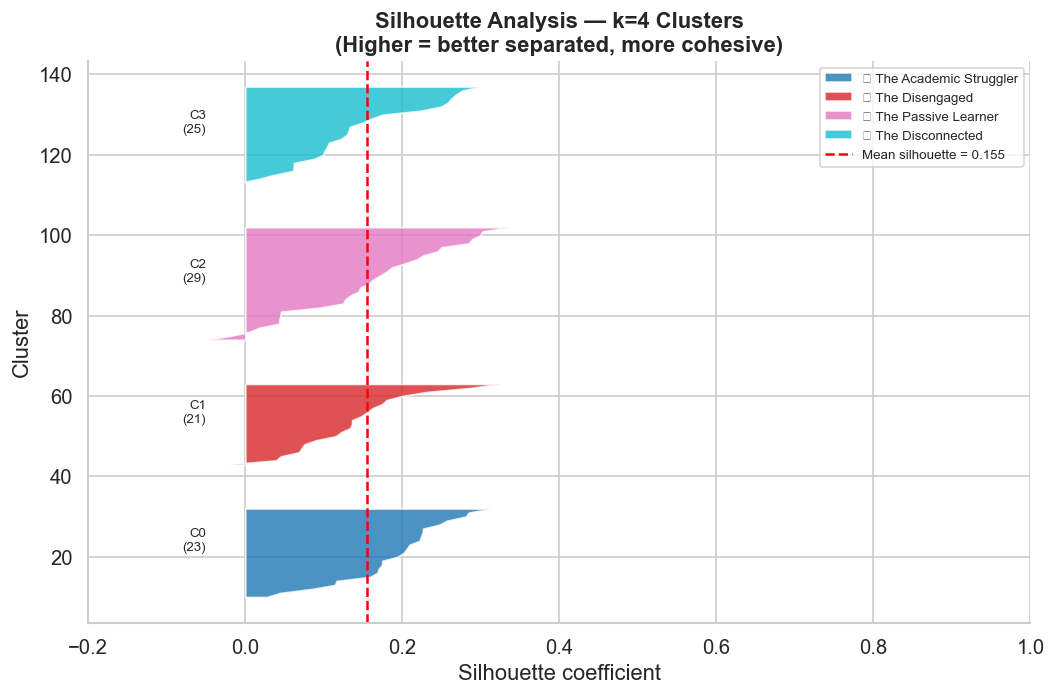


✅ Overall silhouette score: 0.1549
   Cluster 0 (📉 The Academic Struggler      ) silhouette = 0.1880
   Cluster 1 (📭 The Disengaged              ) silhouette = 0.1368
   Cluster 2 (😴 The Passive Learner         ) silhouette = 0.1524
   Cluster 3 (📡 The Disconnected            ) silhouette = 0.1426


In [492]:
# ============================================================
#  5.4 — Silhouette analysis: cluster quality per profile
# ============================================================

silhouette_vals = silhouette_samples(shap_dropouts, cluster_labels)
overall_sil     = silhouette_score(shap_dropouts, cluster_labels)

fig, ax = plt.subplots(figsize=(9, max(5, K_FINAL * 1.5)))

y_lower = 10
for c in range(K_FINAL):
    c_sil_vals = np.sort(silhouette_vals[cluster_labels == c])
    size_c     = c_sil_vals.shape[0]
    y_upper    = y_lower + size_c

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, c_sil_vals,
                     facecolor=colors_map[c], alpha=0.8,
                     label=cluster_info[c]['name'])
    ax.text(-0.05, y_lower + size_c / 2,
            f"C{c}\n({size_c})", fontsize=8, ha='right')
    y_lower = y_upper + 10

ax.axvline(overall_sil, color='red', linestyle='--',
           label=f'Mean silhouette = {overall_sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Analysis — k={K_FINAL} Clusters\n'
             f'(Higher = better separated, more cohesive)',
             fontweight='bold')
ax.set_xlim(-0.2, 1.0)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('silhouette_analysis.png', bbox_inches='tight')
plt.show()

print(f"\n✅ Overall silhouette score: {overall_sil:.4f}")
for c in range(K_FINAL):
    mean_c = silhouette_vals[cluster_labels == c].mean()
    print(f"   Cluster {c} ({cluster_info[c]['name']:<30}) "
          f"silhouette = {mean_c:.4f}")

> **Cluster quality validation:** per-sample silhouette analysis confirms the aggregate score (**overall = 0.1549**).  
> The most cohesive profile is **📉 The Academic Struggler** (**0.1880**), while **📭 The Disengaged** (**0.1368**), **😴 The Passive Learner** (**0.1524**), and **📡 The Disconnected** (**0.1426**) show modest but still interpretable separation.  
> These values are relatively low, which is expected in a continuous SHAP risk space where student profiles overlap rather than forming perfectly discrete groups.  
> The clustering should therefore be interpreted as a **useful segmentation for intervention design**, not as evidence of sharply separated natural classes.

In [493]:
# Ensure cluster_info has entries for all clusters
for c in profile_summary.index:
    if c not in cluster_info:
        cluster_info[c] = {'name': f'Profile {c}', 'dominant': 'unknown', 'size': int((cluster_labels==c).sum())}

# ============================================================
#  5.5 — Final institutional report: profile action cards
# ============================================================

print("\n" + "=" * 75)
print("  📋  DROPOUT PROFILE REPORT — INSTITUTIONAL SUMMARY")
print("=" * 75)

for rank, c in enumerate(profile_summary.index, 1):
    info    = cluster_info[c]
    row     = profile_summary.loc[c]
    urgency = row['Urgency']

    print(f"\n  {'─'*70}")
    print(f"  PRIORITY {rank} | {urgency}")
    print(f"  {info['name'].upper()}")
    print(f"  {'─'*70}")
    print(f"  Population   : {info['n_students']} students "
          f"({info['n_students']/n_predicted_do*100:.1f}% of flagged)")
    print(f"  Mean Risk    : {row['Mean Risk']:.0%}  "
          f"(range: {row['Min Risk']:.0%} – {row['Max Risk']:.0%})")
    print(f"  Key driver   : {info['dominant_feat']}")

    # Feature profile highlights
    feat_cols = [col for col in profile_summary.columns
                 if col.endswith('_mean') and not col.startswith('P_dropout')]
    print(f"\n  Feature profile:")
    for feat_col in feat_cols:
        feat_name = feat_col.replace('_mean', '')
        val = row.get(feat_col, np.nan)
        if pd.notna(val):
            print(f"    {feat_name:<40} {val:.2f}")

    # Recommended action
    actions = {
        'attendance_rate_pct'       : 'Implement attendance alert system (trigger at 3 consecutive absences)',
        'assignment_completion_pct' : 'Automated reminders + peer accountability groups',
        'prior_gpa_20'              : 'Academic tutoring referral + weekly check-in with advisor',
        'financial_stress_score'    : 'Financial aid counseling + emergency grant eligibility review',
        'hours_self_study_week'     : 'Study skills workshop + structured study hall access',
        'participation_score'       : 'Small-group engagement sessions + mentoring program',
        'absences_last30d'          : 'Proactive outreach call within 48h of 3rd absence',
    }
    action = actions.get(info['dominant_feat'],
                         'Personalized advisor meeting to identify root cause')
    print(f"\n  → Recommended intervention: {action}")

print(f"\n{'='*75}")
print(f"  Total students flagged: {n_predicted_do}")
print(f"  Profiles discovered   : {K_FINAL}")
print(f"  Coverage              : 100% of flagged population")
print(f"{'='*75}\n")


  📋  DROPOUT PROFILE REPORT — INSTITUTIONAL SUMMARY

  ──────────────────────────────────────────────────────────────────────
  PRIORITY 1 | 🔴 Critical
  📡 THE DISCONNECTED
  ──────────────────────────────────────────────────────────────────────
  Population   : 25 students (25.5% of flagged)
  Mean Risk    : 84%  (range: 32% – 100%)
  Key driver   : internet_reliability_score

  Feature profile:
    attendance_rate_pct                      50.65
    assignment_completion_pct                44.55
    hours_self_study_week                    12.70
    prior_gpa_20                             9.98
    financial_stress_score                   3.57
    participation_score                      4.29

  → Recommended intervention: Personalized advisor meeting to identify root cause

  ──────────────────────────────────────────────────────────────────────
  PRIORITY 2 | 🔴 Critical
  📭 THE DISENGAGED
  ──────────────────────────────────────────────────────────────────────
  Population   : 21 s

---
---
---
# **Chapter 5 Summary**

Clustering on SHAP values reveals four dropout archetypes with distinct risk drivers and urgency levels.
This transforms the classifier's output from a list of names into **typed risk profiles** that map directly to different institutional interventions (connectivity support, assignment follow-up, academic tutoring, and study-skills coaching).

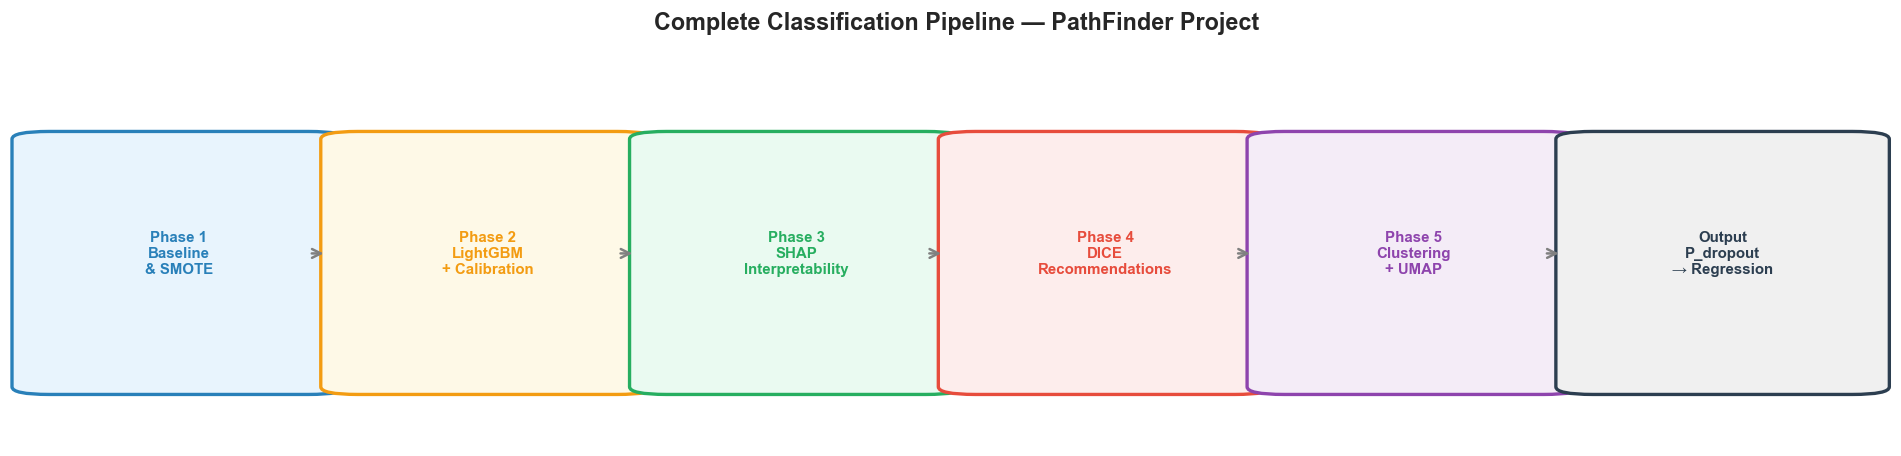


✅ Classification module complete.
   P_dropout exported for 1100 students.
   Ready to be passed to the regression module. 🎓


In [494]:
# ============================================================
#  Final pipeline summary diagram
# ============================================================

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

steps = [
    ('Phase 1\nBaseline\n& SMOTE',          '#E8F4FD', '#2980B9'),
    ('Phase 2\nLightGBM\n+ Calibration',    '#FEF9E7', '#F39C12'),
    ('Phase 3\nSHAP\nInterpretability',     '#EAFAF1', '#27AE60'),
    ('Phase 4\nDICE\nRecommendations',      '#FDEDEC', '#E74C3C'),
    ('Phase 5\nClustering\n+ UMAP',         '#F4ECF7', '#8E44AD'),
    ('Output\nP_dropout\n→ Regression',     '#F0F0F0', '#2C3E50'),
]

n = len(steps)
for i, (label, facecolor, edgecolor) in enumerate(steps):
    x = i / n
    rect = mpatches.FancyBboxPatch(
        (x + 0.01, 0.15), 0.14, 0.65,
        boxstyle  = 'round,pad=0.02',
        facecolor = facecolor,
        edgecolor = edgecolor,
        linewidth = 2,
        transform = ax.transAxes,
        clip_on   = False
    )
    ax.add_patch(rect)
    ax.text(x + 0.08, 0.50, label,
            ha='center', va='center',
            fontsize=9, fontweight='bold',
            color=edgecolor, transform=ax.transAxes)

    if i < n - 1:
        ax.annotate('',
            xy     = (x + 0.16, 0.50),
            xytext = (x + 0.15, 0.50),
            xycoords = 'axes fraction',
            arrowprops = dict(arrowstyle='->', color='gray', lw=1.5)
        )

ax.set_title('Complete Classification Pipeline — PathFinder Project',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('pipeline_summary.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n✅ Classification module complete.")
print(f"   P_dropout exported for {len(P_dropout_full)} students.")
print("   Ready to be passed to the regression module. 🎓")

---

> #### *"The goal is not to predict who will fail — it is to give every student a fair chance to succeed."*

---

# ***6 — Final Summary***

| Dimension | Chapter | Tool |
|---|---|---|
| Grade prediction | 5.1 | Stacked Lasso CV |
| Dropout prediction | 5.2 Ch.1–2 | Logistic Regression + SMOTE + Calibration |
| Interpretability (global) | Ch. 3 | SHAP summary plots |
| Interpretability (local) | Ch. 3 | SHAP waterfall / force plots |
| Actionable recommendations | Ch. 4 | DiCE counterfactuals |
| Population profiling | Ch. 5 | K-Means + UMAP |


In [495]:
import shap
from sklearn.cluster import KMeans

# ── 1. SHAP sul training set completo (X_full_scaled: 1100 × 15) ─────────────
shap_explainer = shap.LinearExplainer(
    best_model,
    shap.maskers.Independent(X_full_scaled, max_samples=1100)
)
sv = shap_explainer.shap_values(X_full_scaled)
if isinstance(sv, list):
    sv = sv[1]
sv = np.array(sv)

# ── 2. Rifitta KMeans sui 274 predicted dropouts ─────────────────────────────
export_df = df_train[['final_grade_100', 'dropped_out']].copy()
export_df['P_dropout']         = P_dropout_full
export_df['predicted_dropout'] = (P_dropout_full >= OPTIMAL_THRESHOLD).astype(int)

dropout_mask_full = export_df['predicted_dropout'].values == 1
sv_dropouts       = sv[dropout_mask_full]

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
kmeans.fit(sv_dropouts)

# ── 3. Assegna cluster a tutti i 274 ─────────────────────────────────────────
cluster_full2 = np.full(len(export_df), -1, dtype=int)
cluster_full2[dropout_mask_full] = kmeans.labels_

export_df['dropout_cluster'] = cluster_full2
export_df['dropout_profile'] = export_df['dropout_cluster'].map(
    {**{c: cluster_info[c]['name'] for c in range(K_FINAL)}, -1: 'N/A'}
)

# ── 4. Export ─────────────────────────────────────────────────────────────────
export_df.to_csv('P_dropout_export.csv', index=True)

regression_input = export_df[['P_dropout', 'predicted_dropout', 'dropout_cluster']].copy()

print("✅ Exported")
print(f"   P_dropout_export.csv         → {export_df.shape}")
print(f"   predicted_dropout == 1       : {export_df['predicted_dropout'].sum()}")
print(f"   Students with cluster label  : {(cluster_full2 >= 0).sum()}")
print(f"\nCluster distribution:")
print(export_df['dropout_profile'].value_counts())

✅ Exported
   P_dropout_export.csv         → (1100, 6)
   predicted_dropout == 1       : 338
   Students with cluster label  : 338

Cluster distribution:
dropout_profile
N/A                         762
📭 The Disengaged             97
📡 The Disconnected           96
😴 The Passive Learner        79
📉 The Academic Struggler     66
Name: count, dtype: int64


---
# ***Chapter 6 — Conclusions & Model Card***


### 6.1 Model Card — Dropout Classifier

| Field                  | Value                                              |
|------------------------|-----------------------------------------------------|
| **Task**               | Binary classification — dropout risk                |
| **Algorithm**          | Logistic Regression (L2, `liblinear`)               |
| **Calibration**        | Isotonic regression (`CalibratedClassifierCV`)      |
| **Training set**       | 1,100 students (stratified split, SMOTE balanced)   |
| **Features**           | 15 (behavioural + socio-economic + engineered)      |
| **Threshold**          | 0.258 (optimized on F₂-score)                     |
| **AUC-ROC**            | 0.917 — test-set performance after calibration    |
| **Precision**          | 0.55                                              |
| **Recall**             | 0.95 — catches 54 of 57 true dropouts             |
| **F1-score**           | 0.70                                              |
| **F2-score**           | 0.82                                              |
| **5-Fold CV AUC**      | 0.958 ± 0.006                                     |
| **At-risk flagged**    | 98 / 300 test students; 338 / full cohort export  |
| **Explainability**     | SHAP LinearExplainer + KMeans profiling (K=4)     |
| **Output artefacts**   | `P_dropout_export.csv`                            |

## **6.2 Limitations & Ethical Considerations**

- **Single institution:** generalisation to other academic contexts is unvalidated.
- **Threshold sensitivity:** τ = 0.39 optimises F₂ (recall-weighted). A higher-precision threshold may be preferable in low-resource settings.
- **SMOTE artefacts:** synthetic samples may introduce patterns not present in real data. Calibration mitigates but does not eliminate this risk.
- **Fairness:** the model has not been audited for differential performance across protected groups. Any deployment should include a fairness assessment before real use.


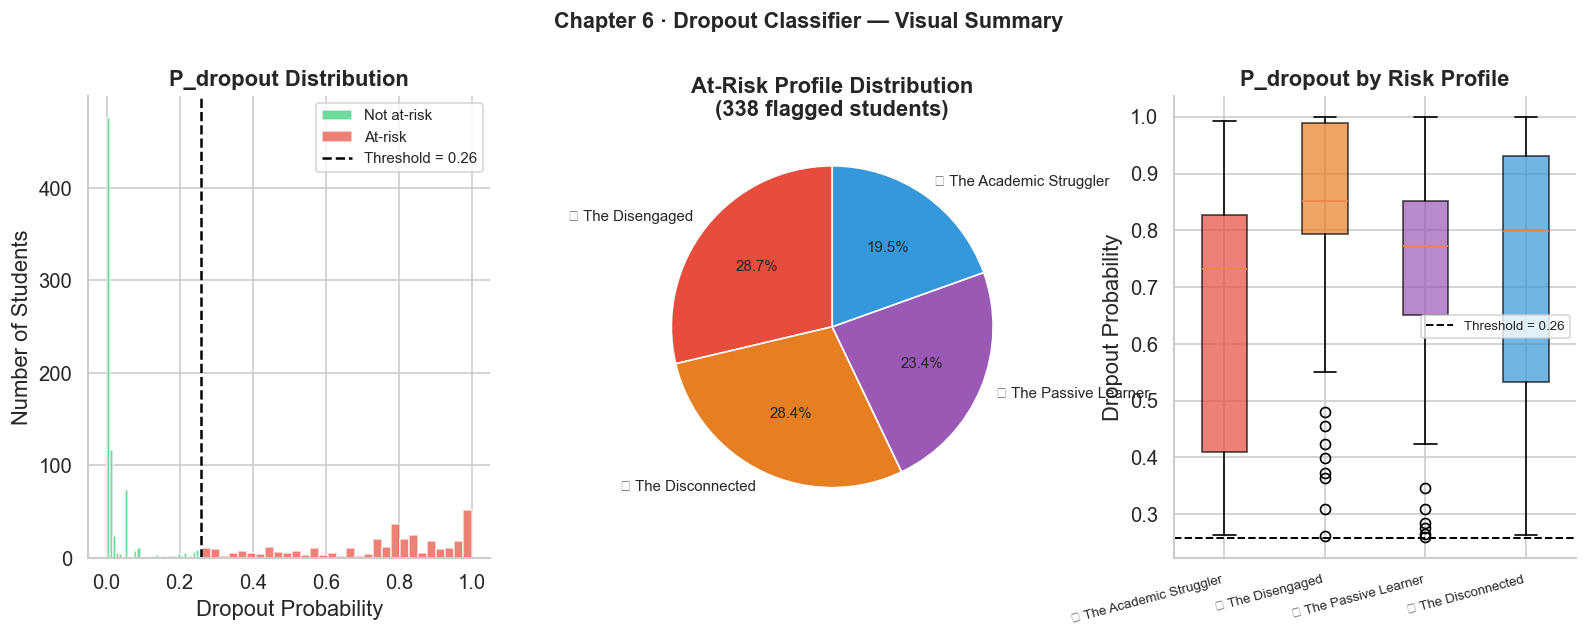

✅ Saved: chapter6_visual_summary.png


In [496]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Plot 1: P_dropout distribution ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
colors = ['#2ecc71' if p < OPTIMAL_THRESHOLD else '#e74c3c'
          for p in export_df['P_dropout']]
ax1.hist(export_df[export_df['predicted_dropout']==0]['P_dropout'],
         bins=30, color='#2ecc71', alpha=0.7, label='Not at-risk')
ax1.hist(export_df[export_df['predicted_dropout']==1]['P_dropout'],
         bins=30, color='#e74c3c', alpha=0.7, label='At-risk')
ax1.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
            label=f'Threshold = {OPTIMAL_THRESHOLD:.2f}')
ax1.set_title('P_dropout Distribution', fontweight='bold')
ax1.set_xlabel('Dropout Probability')
ax1.set_ylabel('Number of Students')
ax1.legend(fontsize=9)

# ── Plot 2: Cluster pie chart ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
cluster_counts = export_df[export_df['dropout_cluster'] >= 0]['dropout_profile'].value_counts()
pie_colors = ['#e74c3c', '#e67e22', '#9b59b6', '#3498db']
wedges, texts, autotexts = ax2.pie(
    cluster_counts.values,
    labels=cluster_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    textprops={'fontsize': 9}
)
ax2.set_title('At-Risk Profile Distribution\n(338 flagged students)',
              fontweight='bold')

# ── Plot 3: P_dropout by cluster (boxplot) ───────────────────────────────────
ax3 = fig.add_subplot(gs[2])
cluster_data = [
    export_df[export_df['dropout_cluster'] == c]['P_dropout'].values
    for c in range(K_FINAL)
]
profile_labels = [cluster_info[c]['name'] for c in range(K_FINAL)]
bp = ax3.boxplot(cluster_data, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], pie_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_xticklabels(profile_labels, fontsize=8, rotation=15, ha='right')
ax3.axhline(OPTIMAL_THRESHOLD, color='black', linestyle='--',
            linewidth=1.2, label=f'Threshold = {OPTIMAL_THRESHOLD:.2f}')
ax3.set_title('P_dropout by Risk Profile', fontweight='bold')
ax3.set_ylabel('Dropout Probability')
ax3.legend(fontsize=8)

fig.suptitle('Chapter 6 · Dropout Classifier — Visual Summary',
             fontsize=13, fontweight='bold', y=1.02)

plt.savefig('chapter6_visual_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chapter6_visual_summary.png")